# Importing packages and scripts

In [366]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns
from importlib import reload
from collections import defaultdict
import random as rd
import os
from PIL import Image
import statsmodels.api as sm
from pathlib import Path

%matplotlib inline

import Peanuts
import modeling
import from_antigravity_peanuts
import from_antigravity_fruits
import pooled_model_pipeline_tau_global
from DDM_code import *

# Importing data

In [317]:
main_folder = r"data_paper/"

path_to_fruit = main_folder + "PreliminaryFruitAnalysis - Fruits.csv"
fruit_data = pd.read_csv(path_to_fruit)

path_to_shmode = main_folder + "PreliminaryFruitAnalysis - sh_mode.csv"
SH_data = pd.read_csv(path_to_shmode)

path_to_emptyfull = main_folder + "PreliminaryFruitAnalysis - empty_full.csv"
fullvsempty_data = pd.read_csv(path_to_emptyfull)

path_to_weights = main_folder + "peanut_weight.csv"
weights_df = pd.read_csv(path_to_weights)

path_to_arena = main_folder + "PreliminaryFruitAnalysis - arena.csv"
arena_data = pd.read_csv(path_to_arena)

path_to_masses = main_folder + "PEANUTS_EXPERIMENT.xlsx"
masses_df = pd.read_excel(path_to_masses)

path_to_images_mold = main_folder + "manual_selection_mold"
peanut_correspondance = pd.read_excel(main_folder + "peanut_correspondance.xlsx")

path_to_putrefaction = main_folder + "putrefaction_data/peanut_resistance_area.csv"

path_to_survival = main_folder + "Soil Data.csv"
survival_df = pd.read_csv(path_to_survival)

ethogram_folder = main_folder + "right_ethograms"

sites_path = main_folder + "saved_sites"
sites_holes_path = main_folder + "saved_sites/hole"

ethogram_path = main_folder + "non_overlapping_ethograms_v4"
ethogram_hole_path = main_folder + "non_overlapping_hole_ethogram_v3"

eating_scoring_path = main_folder + "eating_scoring_hole_ethogram.pkl"

path_to_param = main_folder + "PreliminaryFruitAnalysis - Parametrics.csv"
param_data = pd.read_csv(path_to_param)

path_to_attalea = main_folder + "PreliminaryFruitAnalysis - Dumas_seeds.csv"
attalea_data = pd.read_csv(path_to_attalea)

ovoid_sweep_data_path = r"figures/mag_vs_p_sweep_data.csv"

# Figure 1

## Panel F

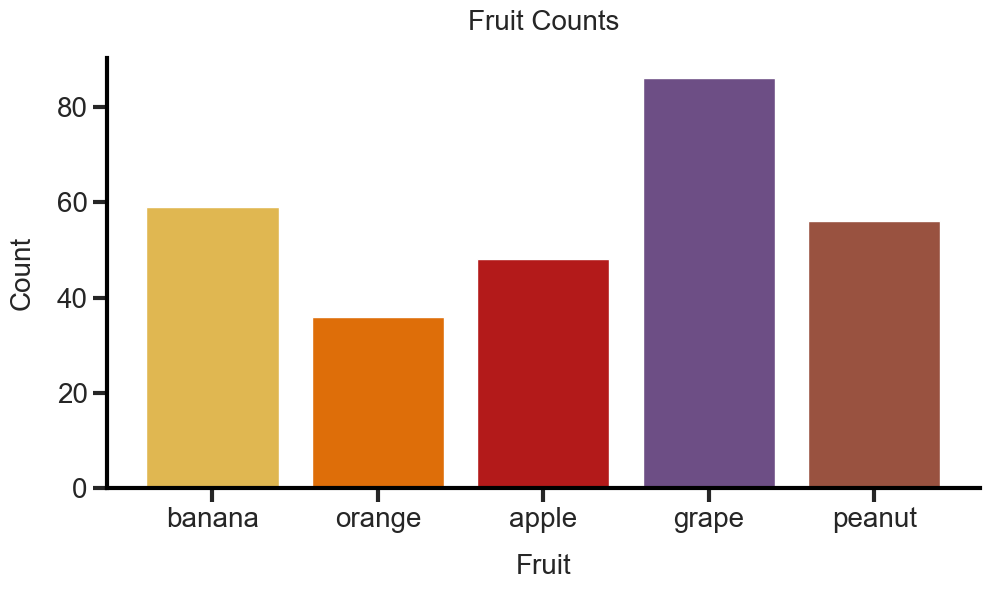

In [7]:
reload(Peanuts)

Peanuts.show_fruit_stats(fruit_data)

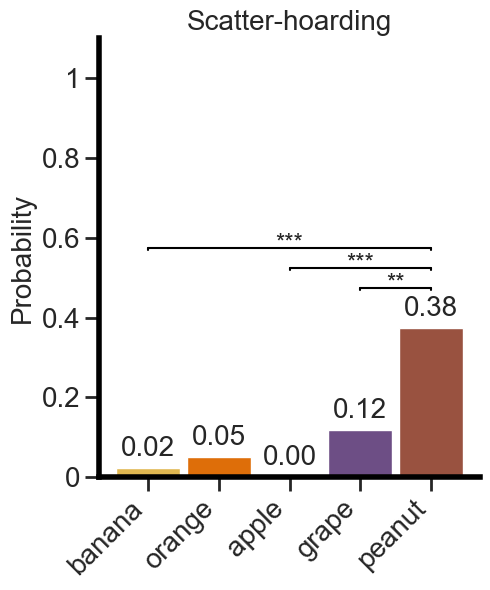

proportion z test: {('apple', 'peanut'): np.float64(0.00036169505109321016), ('banana', 'peanut'): np.float64(0.00015866207499022565), ('grape', 'peanut'): np.float64(0.0035258505628487508)} statistiques: [np.float64(-0.8777131848061808), np.float64(-2.1328219952936913), np.float64(-1.335068315633102), np.float64(-4.130677910464576), np.float64(-1.9062117355090422), np.float64(-0.615526021065475), np.float64(-4.316305890631708), np.float64(0.902364915136272), np.float64(-3.5732446516347056), np.float64(-2.7510022660865743)]


In [9]:
Peanuts.compute_fruit_behav_prob(fruit_data, 'scatter.hoarded', save_path = None)

## Panel H

--- Stat Test: Proportions Z-test (Eat vs Scatter-hoard) ---
Counts: [ 6. 16.], Totals: [35 21]
Z-stat: -4.380, p-val: 1.186e-05
Plot saved to: C:\Users\nacholab-adm\Desktop\figures/rotation_prob_peanut.svg


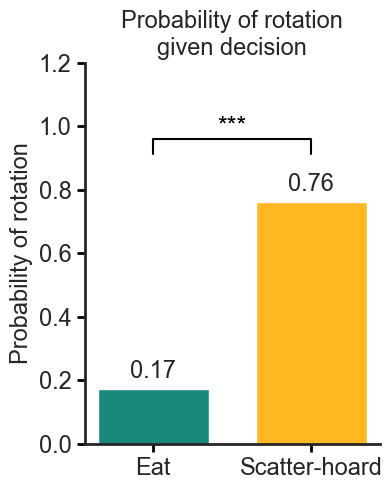

In [13]:
reload(Peanuts)

fruit = 'peanut'
a = fruit_data[['scatter.hoarded', 'rotate']][fruit_data['Fruit'] == fruit]
  
Peanuts.plot_mean_rotations_by_decision(a, rotation_col='rotate', decision_col='scatter.hoarded', fruit = fruit)

## Panel I

--- Stat Test: Proportions Z-test (Eat vs Scatter-hoard) ---
Counts: [54.  8.], Totals: [74 10]
Z-stat: -0.474, p-val: 0.6352
Plot saved to: C:\Users\nacholab-adm\Desktop\figures/rotation_prob_grape.svg


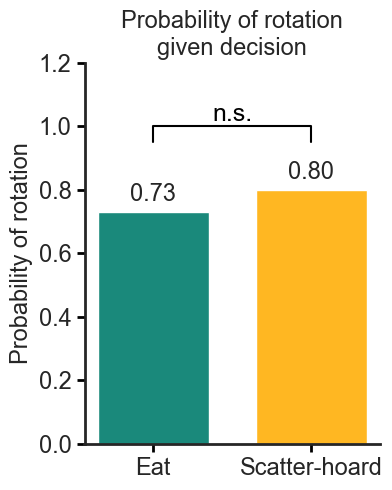

In [15]:
reload(Peanuts)

fruit = 'grape'
a = fruit_data[['scatter.hoarded', 'rotate']][fruit_data['Fruit'] == fruit]
  
Peanuts.plot_mean_rotations_by_decision(a, rotation_col='rotate', decision_col='scatter.hoarded', fruit = fruit)

## Panel K

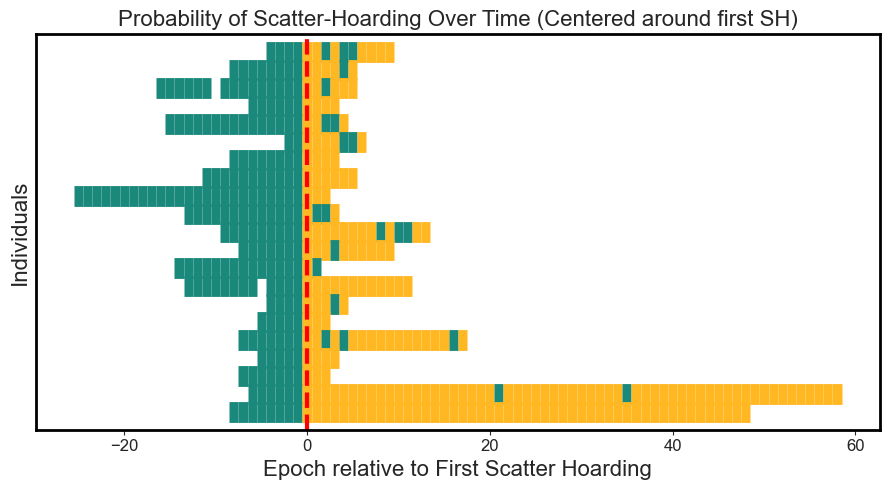

Mann–Whitney U test: stat = 430.500, p = 1.018e-08


In [33]:
reload(Peanuts)

sh_or_rotation = 'scatter-hoard'

a = Peanuts.plot_sh_mode(SH_data, sh_or_rotation)

## Panel L

see modeling - SH-mode

# Figure 2

## Panel B

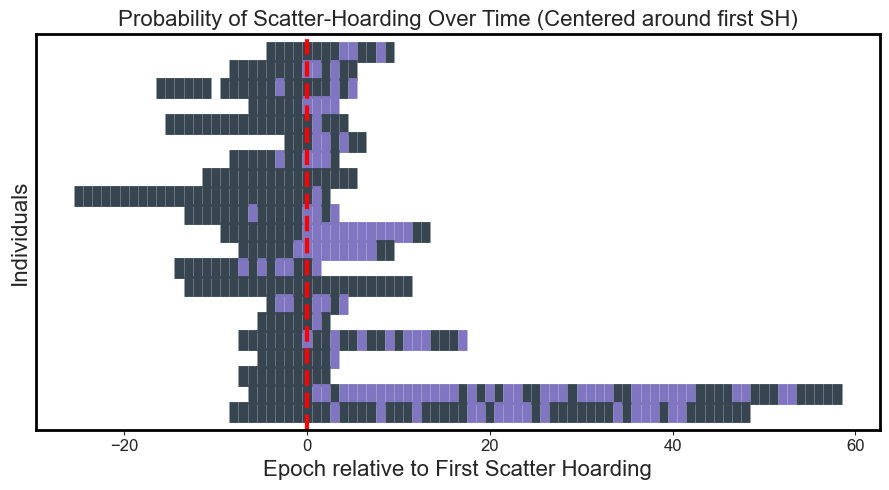

Mann–Whitney U test: stat = 391.000, p = 8.262e-06


In [34]:
reload(Peanuts)

sh_or_rotation = 'rotation'

aligned_rotation = Peanuts.plot_sh_mode(SH_data, sh_or_rotation)

## Panel C

         comparison  n_control  n_group  power
0  empty vs control         12        9  0.079
control 0.8166666666666667
empty 0.8666666666666667

Corrected Holm–Bonferroni p-values across types:
1: p=0.8279 (n.s.)
Saved plot to C:\Users\nacholab-adm\Desktop\figures\empty_vs_full_SH_prob.svg


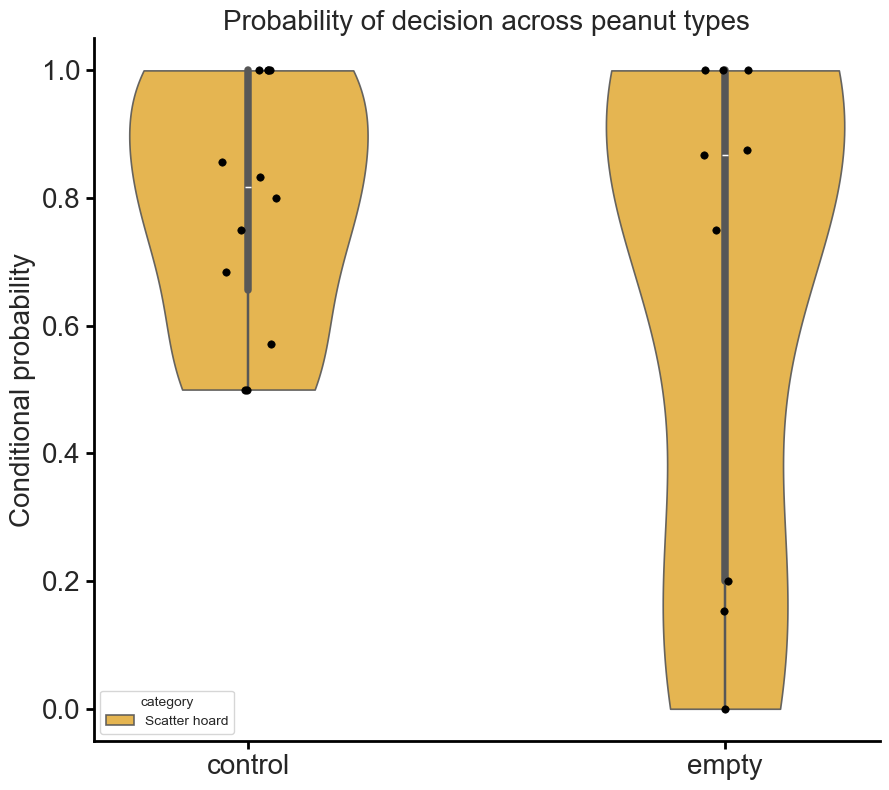

In [37]:
reload(Peanuts)

fullvsempty_data['ID_session'] = fullvsempty_data['ID'] + "_" + fullvsempty_data['Session'].astype(str)

fullvsempty_data = fullvsempty_data[fullvsempty_data['Comments']!='learned']

order = ['control', 'empty'] #, '1-mobile', '2-mobile', '1-immobile', '2-immobile']
proba = 'behavior'   # 'behavior', 'given rotate', 'given behavior'
group_by = 'ID'
connect_scatter = False
min_N_peanuts_per_violin = 2
max_N_missing_violins = 10
show_stats = True
show_reg_lines = False
save_path = r"figures/empty_vs_full_SH_prob.svg"
show = True
only_scatter_hoard = True
violin_width = 0.5
fig_width = 9

violin_df = Peanuts.plot_arena(fullvsempty_data, proba, order, group_by, min_N_peanuts_per_violin, max_N_missing_violins = max_N_missing_violins, connect_scatter = connect_scatter, show_stats = show_stats, show_reg_lines = show_reg_lines, save_path = save_path, show = show, only_scatter_hoard = only_scatter_hoard, violin_width = violin_width, fig_width = fig_width)

## Panel D

Mann-Whitney U test (Control vs Empty): p=6.055e-18


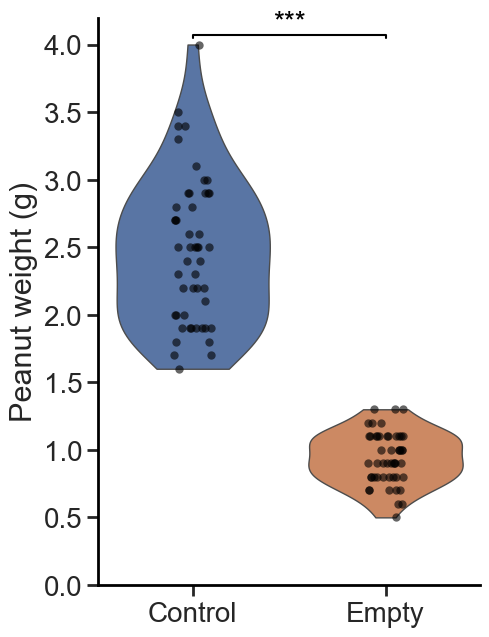

In [45]:
reload(Peanuts)

Peanuts.plot_weights_empty_vs_full(weights_df, save_path = None)

## Panel E


--- Fisher Exact Test (rotation) ---
Groups: control vs empty
Frequencies: 65/148 vs 40/92
p-value: 1


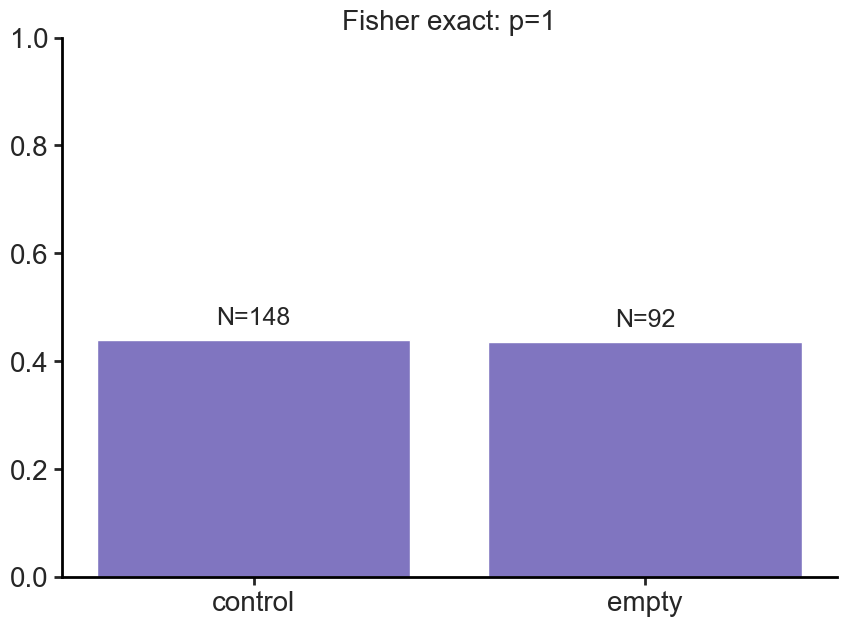

,test,group1,group2,x1,n1,x2,n2,p_value
0,fisher_exact,control,empty,65,148,40,92,1.0


In [49]:
reload(Peanuts)

order = ['control', 'empty']
test = 'fisher'

Peanuts.plot_compute_single_prob(fullvsempty_data, 'rotation', order, '#8075C0', test = test, save_path = None)

## Panel F 

            comparison  n_control  n_group  power
0  1cm_hole vs control         16        6    1.0
1  2cm_hole vs control         16        8    1.0
2   crushed vs control         16       15    1.0
1cm_hole 0.4110576923076923
2cm_hole 0.4083333333333333
control 1.0
crushed 0.2

Omnibus Chi2 for Scatter hoard: p=3.146389312e-21

Pairwise comparisons for Scatter hoard (Holm-corrected Fisher):
  control vs 1cm_hole: p=1.697417848e-14 *
  control vs 2cm_hole: p=2.283821818e-12 *
  control vs crushed: p=5.68340179e-20 *
  1cm_hole vs 2cm_hole: p=1 n.s.
  1cm_hole vs crushed: p=1 n.s.
  2cm_hole vs crushed: p=1 n.s.
Saved plot to C:\Users\nacholab-adm\Desktop\figures\ctrl_1_2_crushed_SH_prob.svg


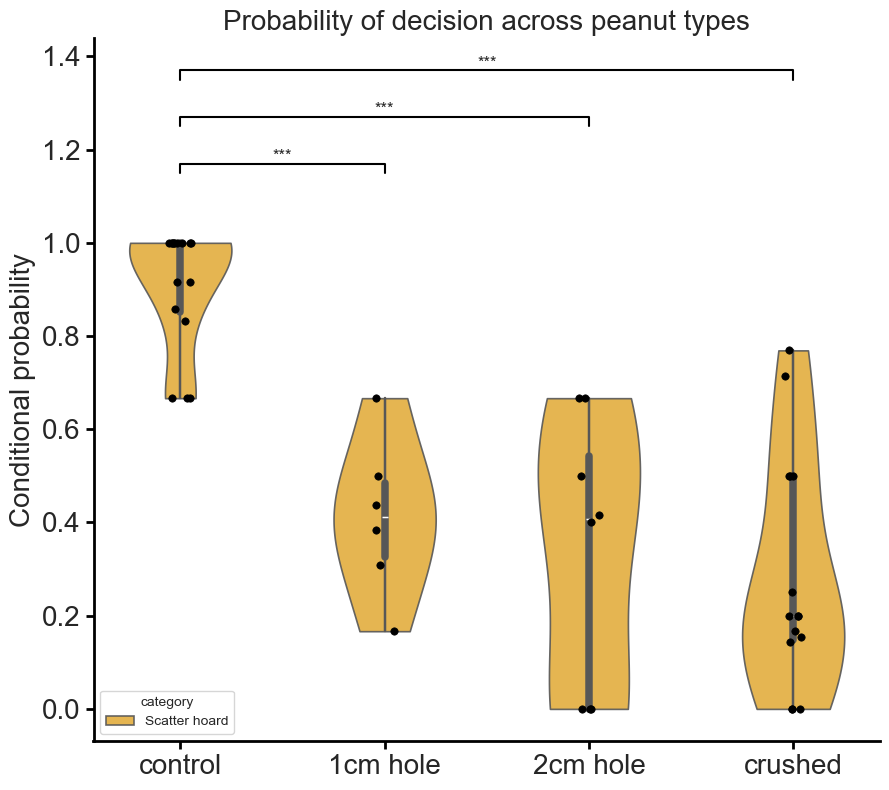

In [53]:
reload(Peanuts)

order = ['control', '1cm_hole', '2cm_hole', 'crushed']
proba = 'behavior'   # 'behavior', 'given rotate', 'given behavior', 'given not rotate'
group_by = 'ID'
min_N_peanuts_per_violin = 2
max_N_missing_violins = 10
connect_scatter = False
show_reg_lines = False
save_path = r"figures/ctrl_1_2_crushed_SH_prob.svg"
show = True
only_scatter_hoard = True
violin_width = 0.5
fig_width = 9
comparisons = 'all'   # 'all' or 'control'
fit_type = 'linear'   # 'sigmoid', 'linear'

a = Peanuts.plot_arena(arena_data, proba, order, group_by, min_N_peanuts_per_violin, max_N_missing_violins = max_N_missing_violins, connect_scatter = connect_scatter, show_reg_lines = show_reg_lines, save_path = save_path, show = show, only_scatter_hoard = only_scatter_hoard, violin_width = violin_width, fig_width = fig_width, comparisons = comparisons, fit_type = fit_type)

## Panel G


--- Chi-square Omnibus Test (rotation) ---
Groups: ['control', '1cm_hole', '2cm_hole', 'crushed']
Chi2: 11.022, df: 3, p-value: 0.01160891912
Post-hoc Pairwise Fisher tests (holm corrected):
  control vs 1cm_hole: p=0.7801244766 (ns)
  control vs 2cm_hole: p=1 (ns)
  control vs crushed: p=0.009971424625 (*)
  1cm_hole vs 2cm_hole: p=1 (ns)
  1cm_hole vs crushed: p=0.5746413612 (ns)
  2cm_hole vs crushed: p=0.3539380694 (ns)


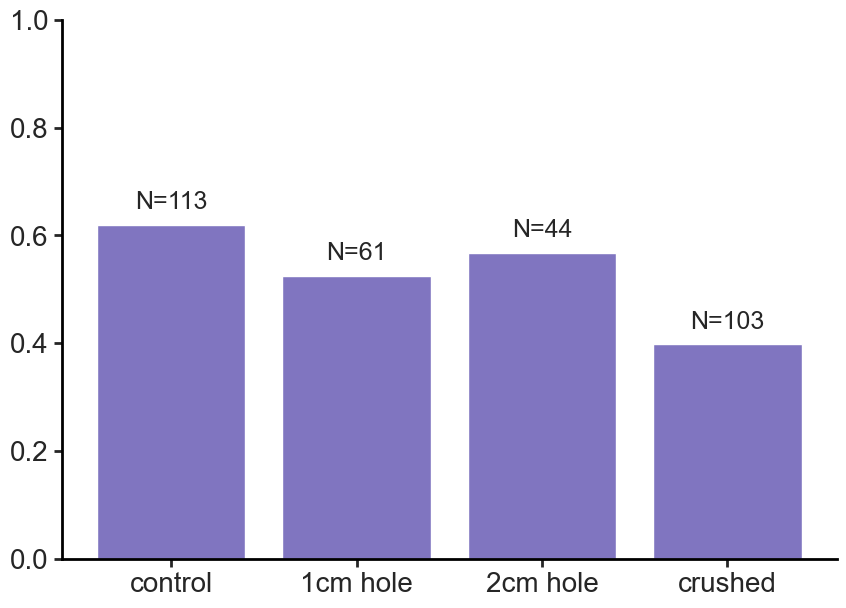

In [56]:
reload(Peanuts)

order = ['control', '1cm_hole', '2cm_hole', 'crushed']
test = 'chi2'

show_scatter = False

df = Peanuts.plot_compute_single_prob(arena_data, 'rotation', order, '#8075C0', show_scatter = show_scatter, test = test, save_path = None)

## Panel H


Linear regression of weight loss vs. recovery time:

  intact → slope = 0.0051, p = 0.4913 (ns), R² = 0.016
    hole → slope = 0.0452, p = 2.063e-05 (***), R² = 0.459
 crushed → slope = 0.0398, p = 0.0008484 (***), R² = 0.298


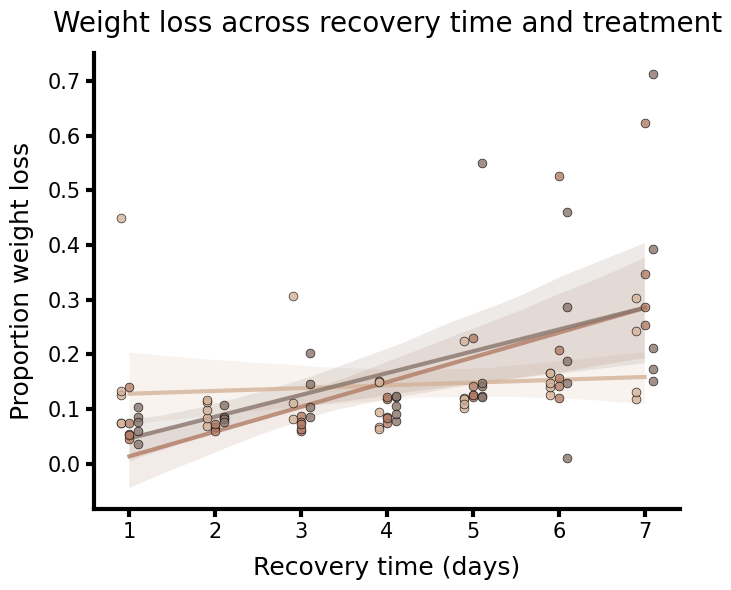

In [59]:
reload(Peanuts)

masses_df['loss_dry_peanut'] = masses_df['peanut'] - masses_df['dry.peanut']
masses_df['loss_dry_peanut_corrected'] = [el if el > 0 else np.nan for el in masses_df['loss_dry_peanut']]
masses_df['prop'] = masses_df['loss_dry_peanut_corrected']/masses_df['peanut']

slopes_mass = Peanuts.show_peanuts_mass(masses_df, None)

## Panel I

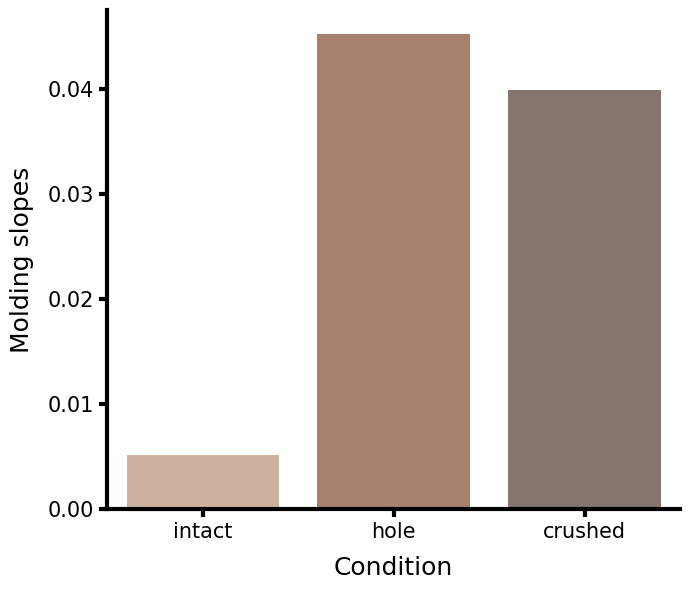

In [62]:
reload(Peanuts)

Peanuts.plot_slopes(slopes_mass, ylabel="Molding slopes", save_path_svg = None)

## Panel J


=== Linear regressions (proportion of red ~ delay) ===

Condition: intact
  Slope:        0.0975
  Intercept:    -0.1509
  R²:           0.4004
  p-value:      1.288e-07 (***)
--------------------------------------------------
Condition: hole
  Slope:        0.1206
  Intercept:    -0.0607
  R²:           0.6692
  p-value:      2.445e-14 (***)
--------------------------------------------------
Condition: crushed
  Slope:        0.1209
  Intercept:    -0.1039
  R²:           0.5062
  p-value:      3.385e-09 (***)
--------------------------------------------------


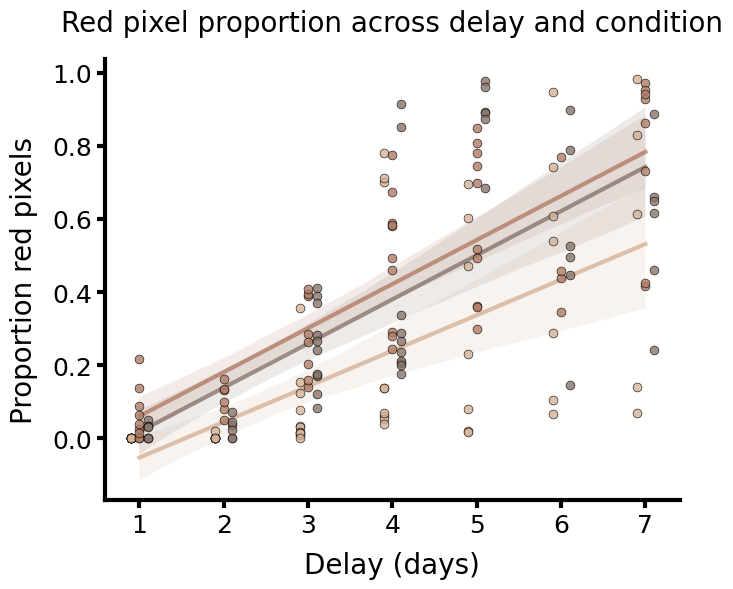

In [69]:
reload(Peanuts)

dict_prop_red = {}
for file in os.listdir(path_to_images_mold):
    if not file.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff')):
        continue  # skip non-image files

    img_path = os.path.join(path_to_images_mold, file)
    img = Image.open(img_path).convert('RGB')
    img_array = np.array(img)

    # --- Count non-white pixels ---
    non_white_mask = np.any(img_array != [255, 255, 255], axis=-1)
    n_non_white = np.sum(non_white_mask)

    # --- Count pure red pixels (255, 0, 0) ---
    red_mask = np.all(img_array == [255, 0, 0], axis=-1)
    n_red = np.sum(red_mask)

    dict_prop_red[file.split('_cropped')[0]] = n_red/n_non_white


# Convert dict → DataFrame
df_vals = pd.DataFrame({
    "key": list(dict_prop_red.keys()),
    "proportion of red": list(dict_prop_red.values())
})

# Extract filename prefix (e.g., "1-5" from "1-5_mask_0")
df_vals["filename"] = df_vals["key"].apply(lambda x: x.split("_")[0])

df_merged = df_vals.merge(peanut_correspondance, on="filename", how="left")

slopes_mold = Peanuts.show_peanut_mold(df_merged, save_path = None)

## Panel K

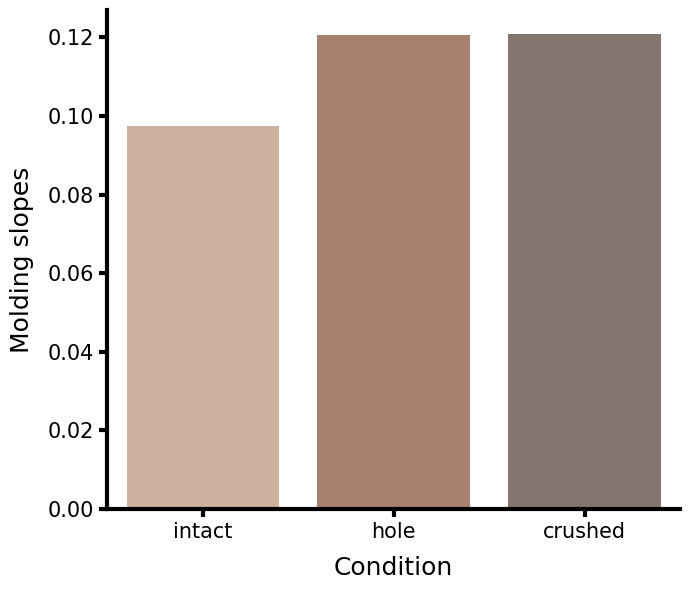

In [72]:
reload(Peanuts)

Peanuts.plot_slopes(slopes_mold, ylabel="Molding slopes", save_path_svg = None)

## Panel L

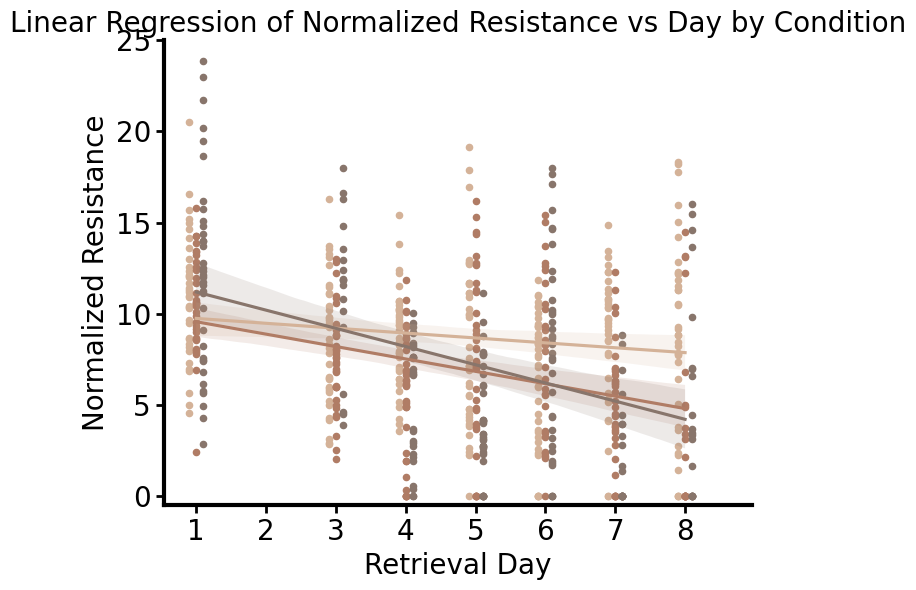

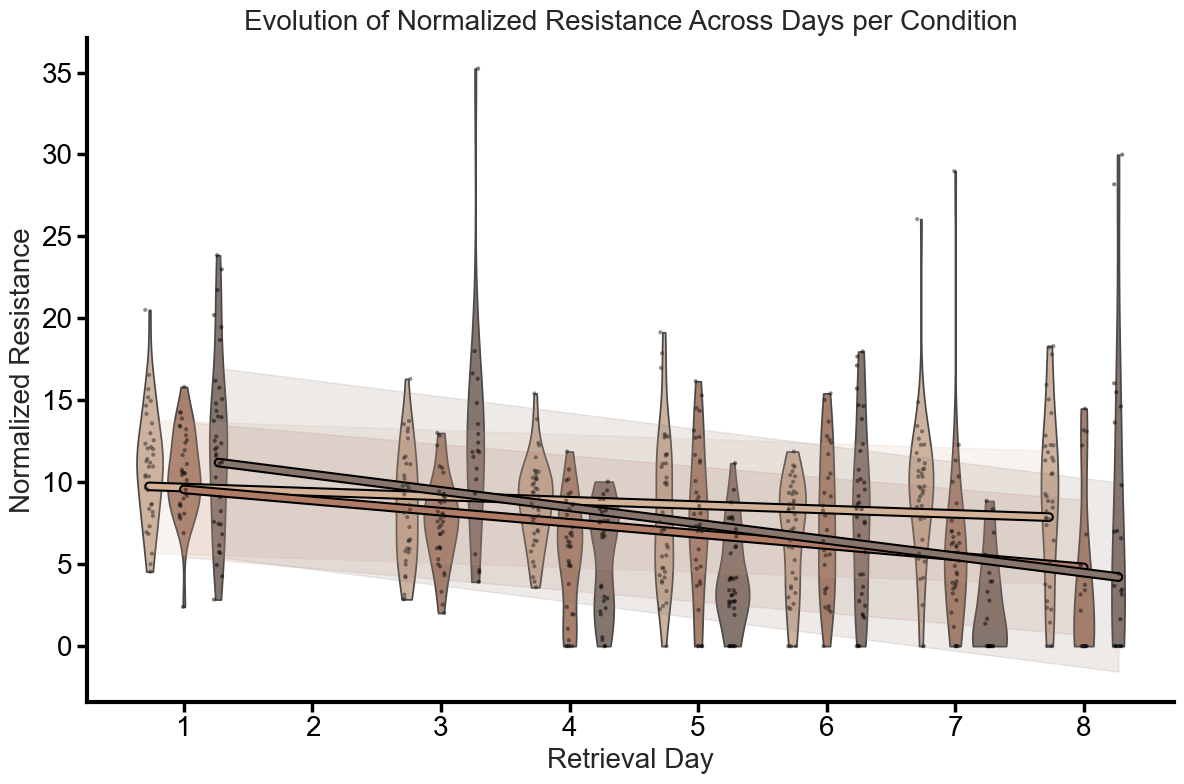

Linear Regression Results:
Intact: Slope = -0.2682, P = 1.9216e-02, R² = 0.0207
Hole: Slope = -0.6803, P = 2.4869e-07, R² = 0.1109
Crushed: Slope = -0.9978, P = 2.1600e-07, R² = 0.1291


In [76]:
reload(from_antigravity_peanuts)

show_regression = True
select_days = None#[1, 3, 4]
metric = 'turgidity'

slopes_turgidity = from_antigravity_peanuts.analyze_peanut_resistance(path_to_putrefaction, show_regression = show_regression, select_days = select_days, metric = metric)

## Panel M

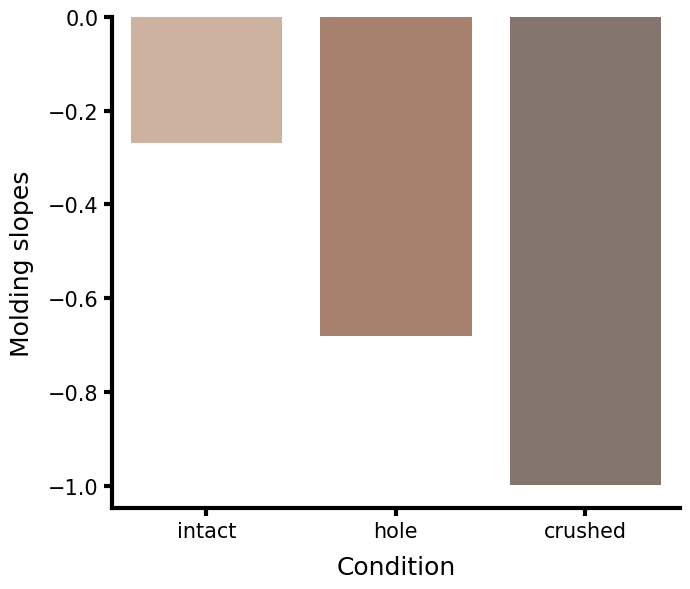

In [78]:
reload(Peanuts)

Peanuts.plot_slopes(slopes_turgidity, ylabel="Molding slopes", save_path_svg = None)

## Panel N

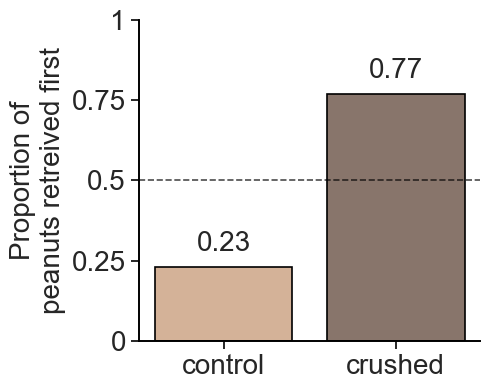

In [83]:
reload(from_antigravity_peanuts)

from_antigravity_peanuts.plot_survival_rates(survival_df)

# Figure 3

## Panel A

In [88]:
reload(Peanuts)

exp_name = 'ALL'   # Either the name of a specific experimentation (without the .csv) or 'ALL'

dict_ethograms = Peanuts.import_ethograms(ethogram_folder, exp_name, expand_teeth_contact=True)

Processing: baby_1405
Processing: baby_1405_bloc1
Processing: boit_1205
Processing: dest_1405 do
Processing: dote_1505
Processing: griz_1305
Processing: griz_1405_bloc1
Processing: griz_1905_bloc1
Processing: griz_1905_bloc2
Processing: griz_1905_bloc3
Processing: ligh_1605_bloc1
Processing: ligh_1605_bloc1bis
Processing: pepp_1305
Processing: repo_1405_bloc1
Processing: repo_1905_bloc0
Processing: repo_1905_bloc1
Processing: repo_1905_bloc1bis
Processing: repo_1905_bloc2
Processing: repo_1905_bloc2bis
Processing: side_1205
Processing: Side_1305
Processing: whit_1305
Processing: whit_1405
Processing: whit_1405_1


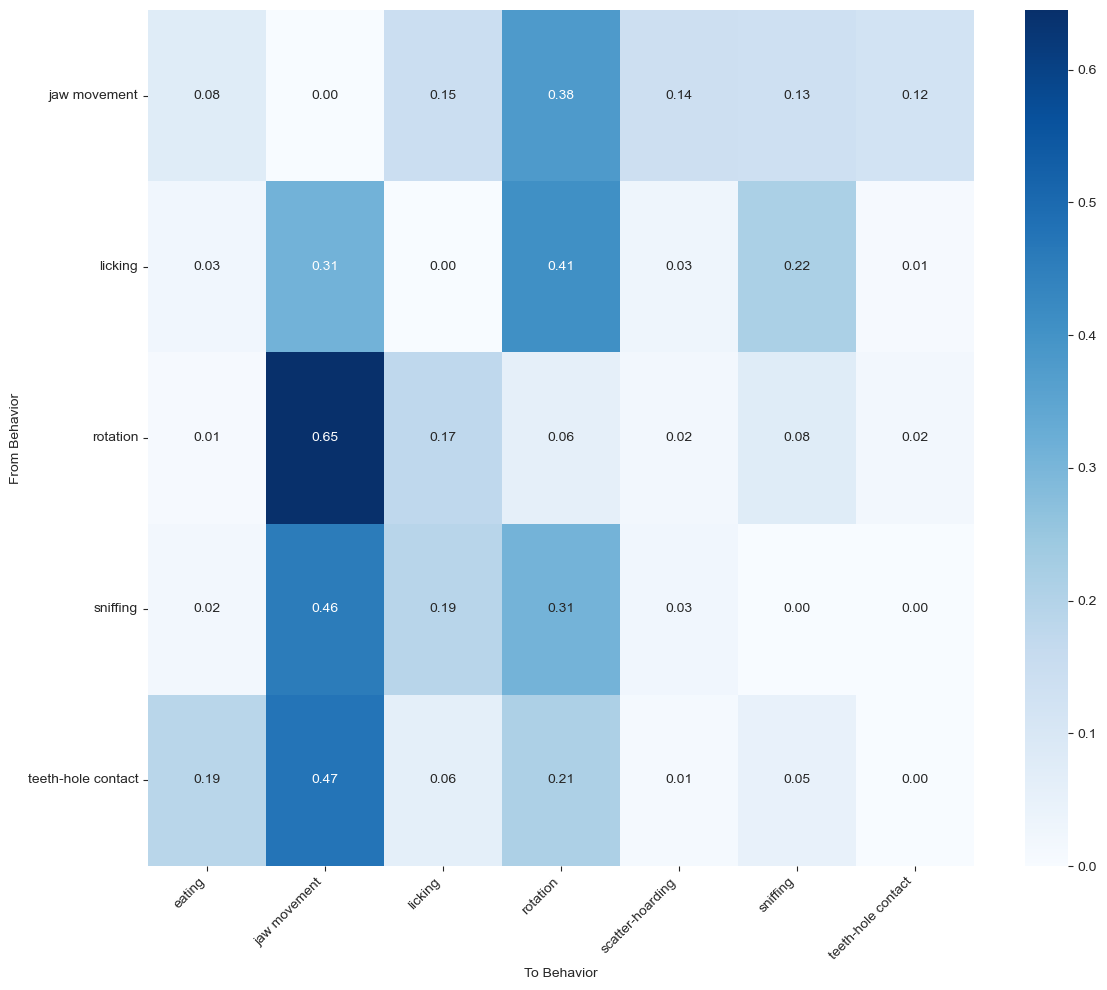

In [90]:
reload(Peanuts)

exp_name = 'ALL'
exclude_behaviors = ['chewing', 'grabbing peanut', 'chomping', 'dropping peanut', 'ear clapping', 'peeling', 'bending', 'lifting', 'mouth', 'pause', 'target']
only_assessing = True
no_display_behaviors = ['chewing', 'chomping', 'dropping peanut', 'ear clapping', 'peeling', 'bending', 'lifting', 'mouth', 'pause', 'target']
pull_rotations = True

show_matrix = True
self_transitions = False
min_count = 3
by_condition = False
by_session = False
include_outcome = True
add_grabbing = False

transition_matrix = Peanuts.compute_transition_probabilities(dict_ethograms, exp_name, exclude_behaviors, min_count, show_matrix = show_matrix, self_transitions = self_transitions, only_assessing = only_assessing, no_display_behaviors = no_display_behaviors, pull_rotations = pull_rotations, by_condition = by_condition, include_outcome = include_outcome, by_session = by_session, add_grabbing = add_grabbing)

## Panel B

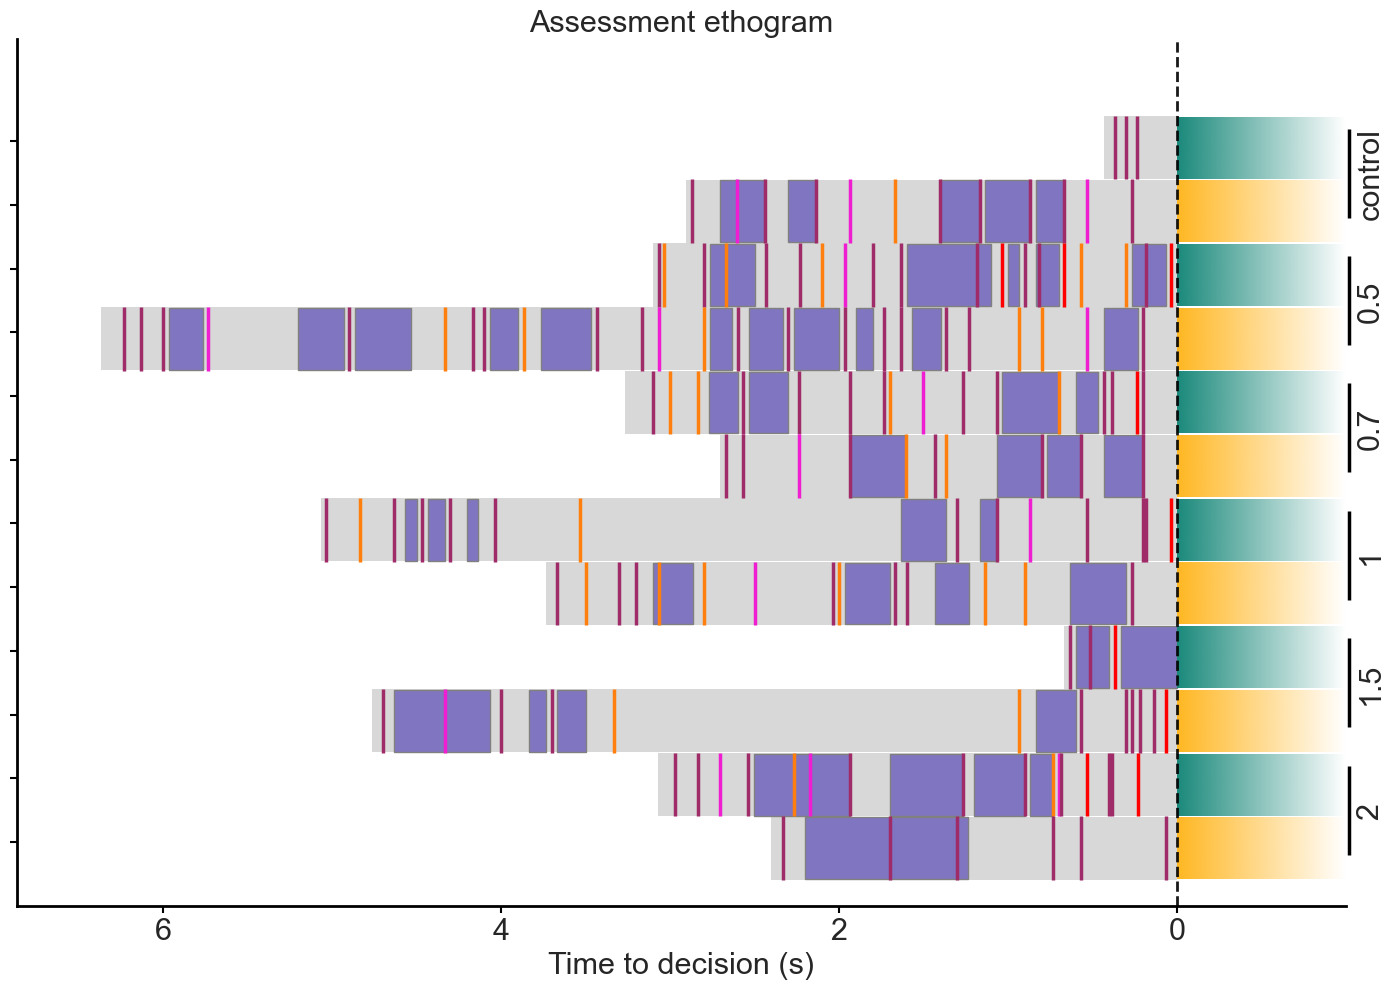

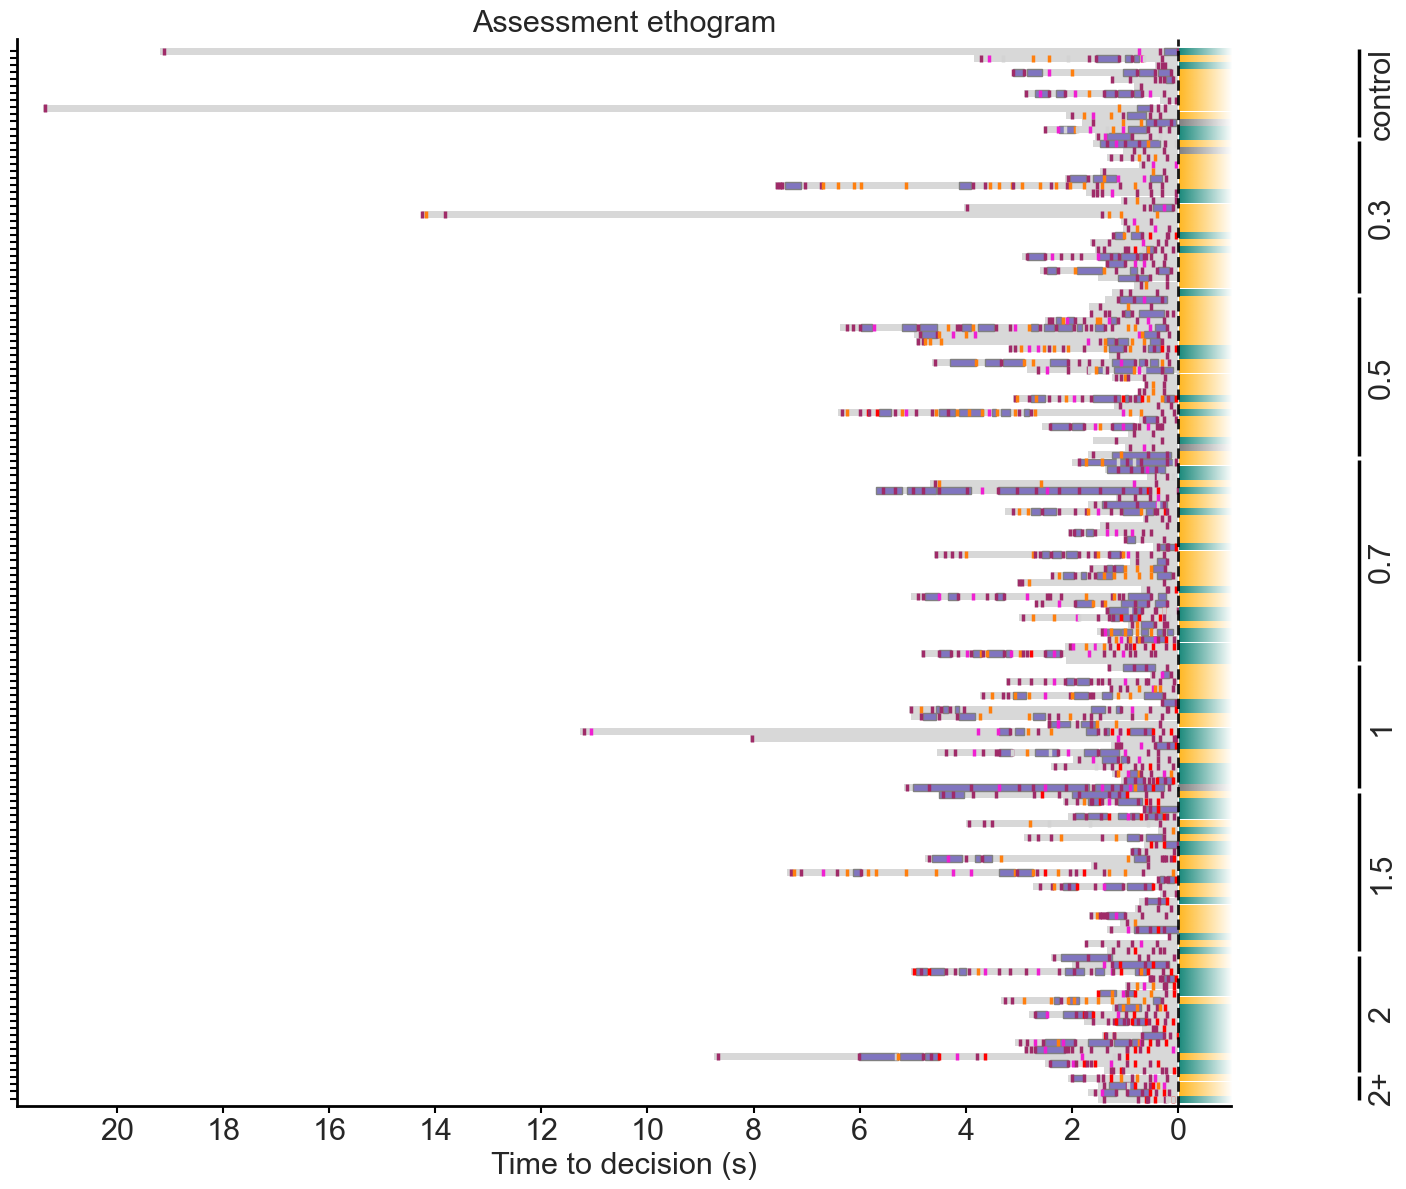

In [93]:
reload(Peanuts)

list_medias = ['Baby_1405_0001_seven(1).mp4', 'griz_1905bloc2_0008_seven.mp4', 
               'griz_1905bloc3_0005_control.mp4', 'Griz_1305_0014_five.mp4', 'Griz_1305_0023_one.mp4', 
               'Griz_1305_0007_onehalf.mp4', 'Griz_1405_0015_one(1).mp4', 'Griz_1405_0016_onehalf(1).mp4', 'Repo_1405_0003_five(1).mp4','repo_1905bloc0_0004_two.mp4', 
               'repo_1905bloc1_0001_control.mp4', 'repo_1905bloc2bis_0001_twoplus.mp4', 'Baby_1405_0008_two.mp4']

rows_ex = Peanuts.plot_multi_behavior_timelines(
    dict_ethograms,
    list_medias,
    figsize=(14, 10),
    row_spacing=0.5,
    tick_spacing=2,
    ordering = True,
    ordering_outcome = True,
    align_end = True,
    save_path= None)

list_medias = []
for ID, processed in dict_ethograms.items():
    if ID != 'boit_1205' and ID != 'dest_1405 do':
        list_medias.append(np.unique(processed['processed']['Media file name']))
list_medias = [x for arr in list_medias for x in arr.tolist()]

rows = Peanuts.plot_multi_behavior_timelines(
    dict_ethograms,
    list_medias,
    figsize=(14, 12),
    row_spacing=0.5,
    tick_spacing=2,
    ordering = True,
    ordering_outcome = False,
    normalize_time=False,
    align_outcomes = 21.4,
    align_end = True)

## Panel C


--- Statistical Test: Kruskal-Wallis ---
H-statistic: 109.356, p-value: 1.793e-24
--- Post-hoc Pairwise Comparisons (Holm-corrected MWU) ---
  jaw movement vs licking: p=0.0000 *
  jaw movement vs sniffing: p=0.0000 *
  licking vs sniffing: p=0.0003 *


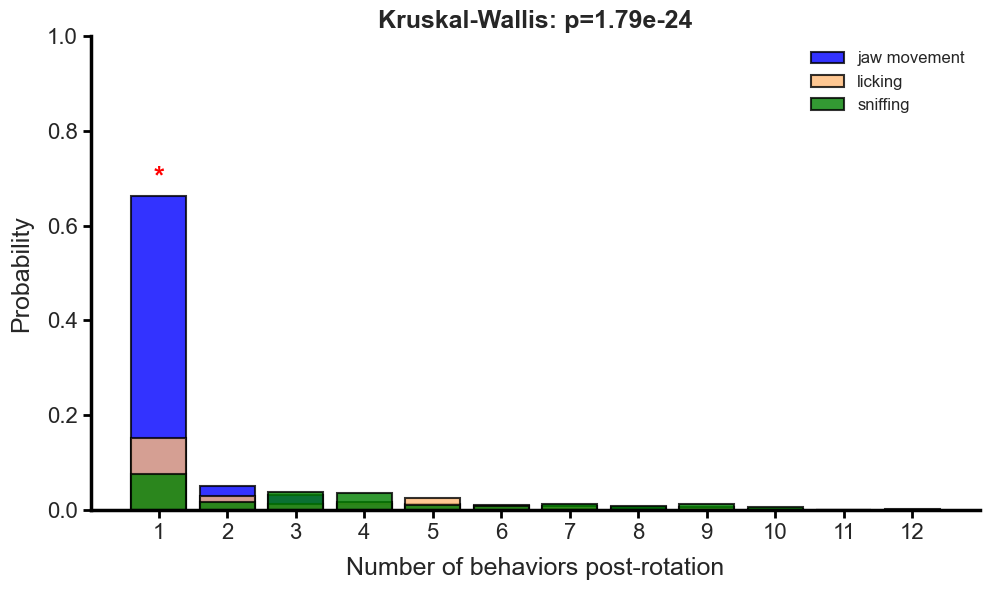

In [95]:
reload(Peanuts)

Peanuts.plot_combined_delays_after_rotation(dict_ethograms, save_path = None)

## Panel E

Front sites file not found: C:\Users\nacholab-adm\Desktop\peanut_symbols\saved_sites/3_stick_front_sites.json


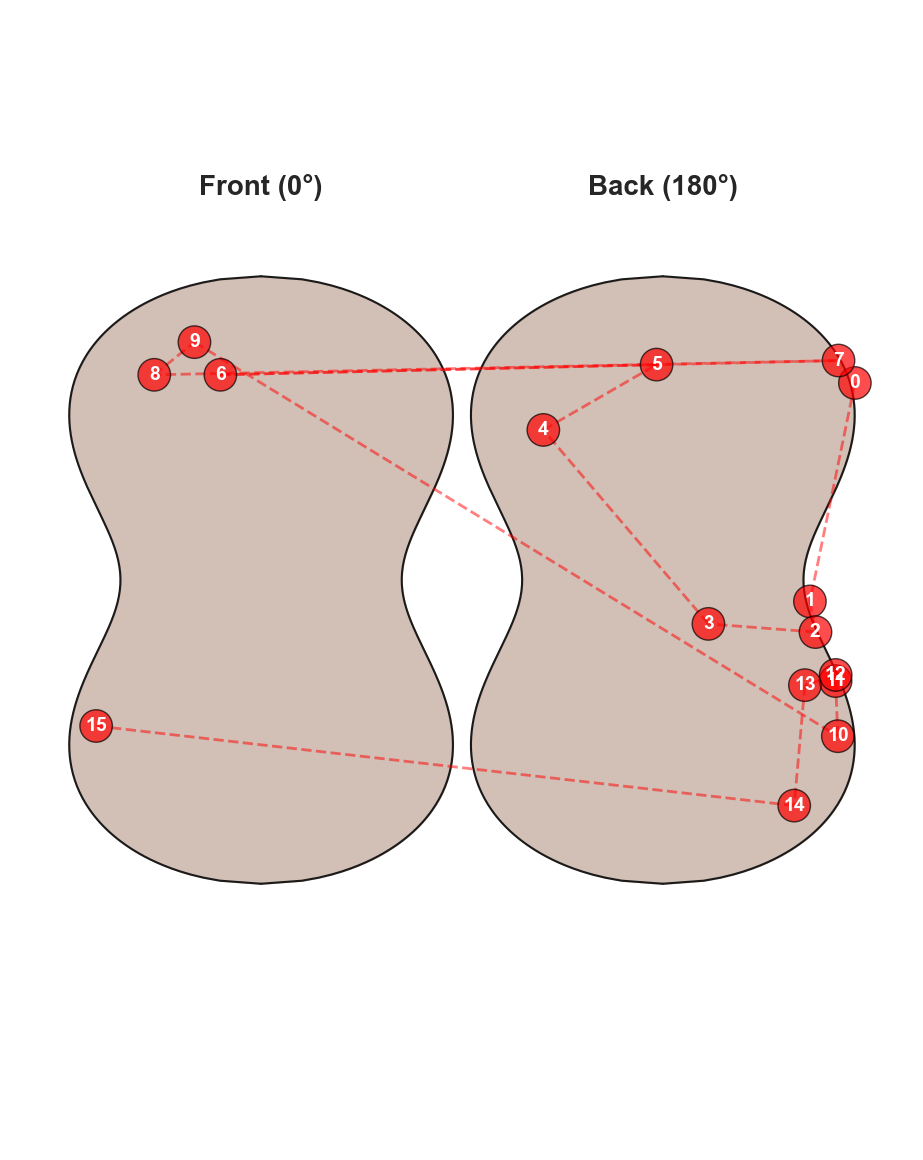

In [104]:
reload(from_antigravity_peanuts)

sites_clamps = sites_path + "/3_stick_sites.json"

show_bottom = True
show_front = True
show_lines = True
simple_lines=True
bottom_color = 'red'
front_color = 'blue'
output_file = None

from_antigravity_peanuts.plot_sequence_for_peanut_two_faces(
    sites_path=sites_clamps, 
    ethogram_path=ethogram_path,
    show_bottom = show_bottom,
    show_front = show_front,
    show_lines=show_lines,
    simple_lines = simple_lines,
    output_file = None
)

## Panel F

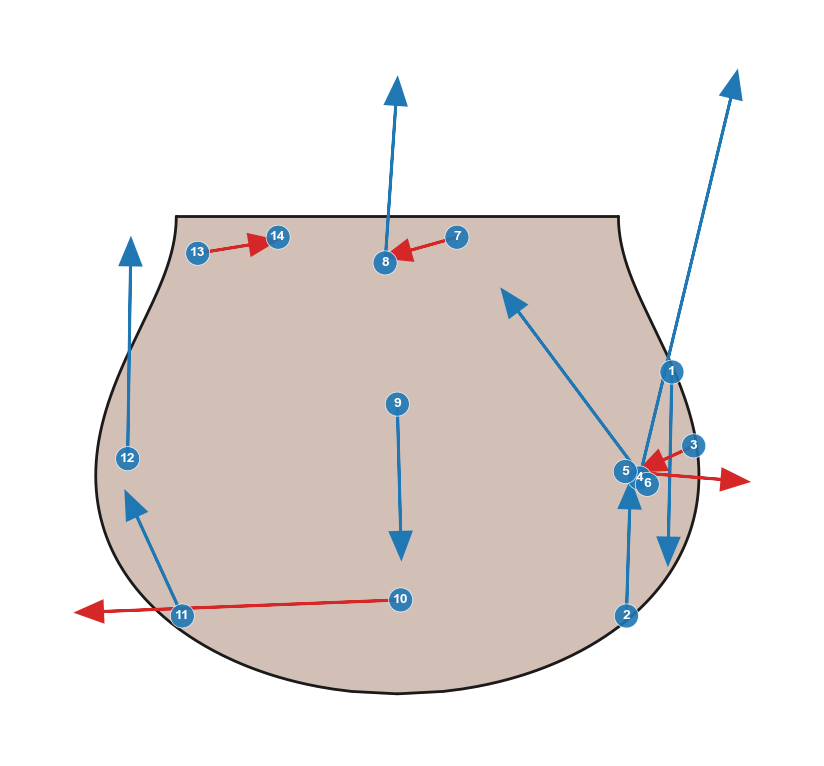

In [134]:
reload(from_antigravity_peanuts)

sites_clamps = sites_path + "/5_good_sites.json"
teeth_mode = 'bottom'   # 'bottom', 'top', or 'both'

clamps_arrows_dict = from_antigravity_peanuts.generate_folded_half_chamber_map_with_sequence(
    sites_path=sites_clamps,
    teeth_mode=teeth_mode, 
    show_quadrants=True,
    show_axes=False,
    show_full_context = False,
    output_file = None,
    plot = True
)

No sites found.


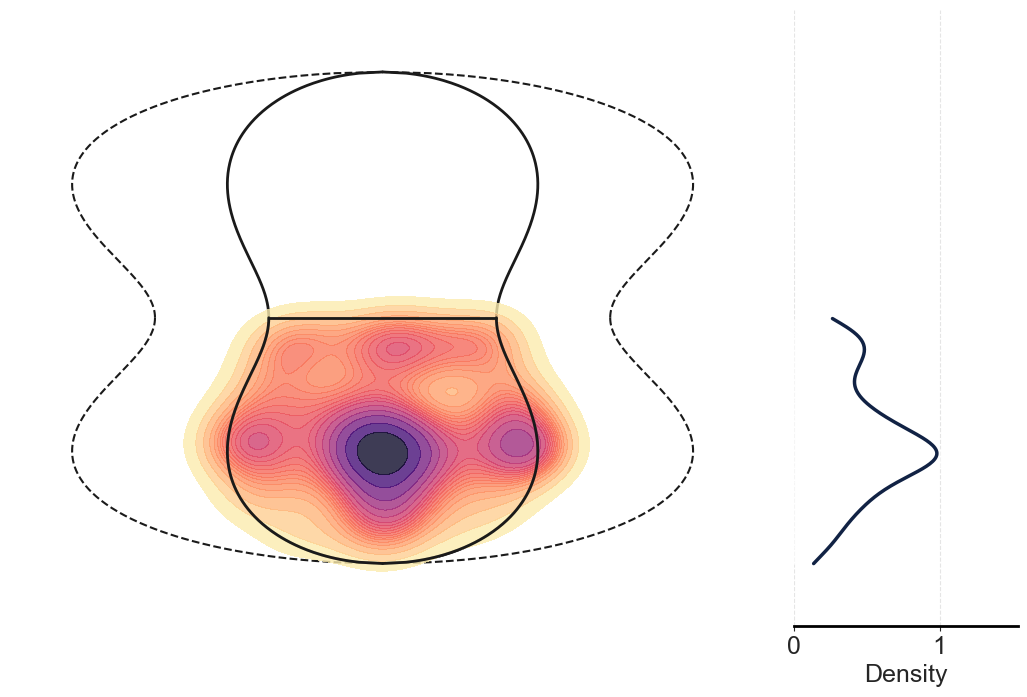

In [135]:
reload(from_antigravity_peanuts)

teeth_mode = 'bottom'   # 'bottom', 'top', or 'both'
show_marginal=True

from_antigravity_peanuts.process_all_peanuts_density(
    sites_directory=sites_path, 
    teeth_mode=teeth_mode, 
    show_full_context=True, 
    output_file = None,
    show_marginal=show_marginal)

## Panel G

No sites found.


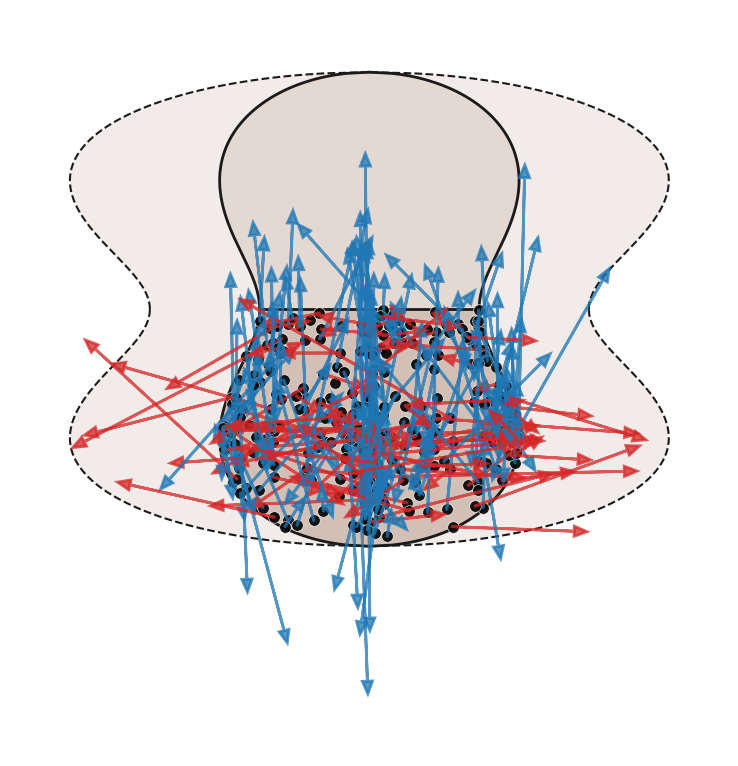

In [137]:
reload(from_antigravity_peanuts)

teeth_mode = 'bottom'   # 'bottom', 'top', or 'both'

from_antigravity_peanuts.process_all_peanuts(
    sites_directory=sites_path,
    teeth_mode=teeth_mode,
    show_full_context = True,
    output_file = None
)

## Panel H


--- Rose Plot Uniformity Stats ---
Total Vectors: 305
Chi-square Stat: 286.836, p-value: 1.612e-56
Result: Distribution is significantly different from uniform (biased).

Post-hoc Bin Analysis (vs Uniform):
  Range           Count    p_uncorr   p_adj      Sig
  -------------------------------------------------------
  [0-9°]          37       0.2147     0.4569     n.s.
  [9-18°]         25       0.2938     0.4569     n.s.
  [18-27°]        15       0.003092   0.02165    *
  [27-36°]        12       0.000414   0.003312   *
  [36-45°]        7        7.279e-06  6.551e-05  *
  [45-54°]        17       0.009975   0.04988    *
  [54-63°]        15       0.003092   0.02165    *
  [63-72°]        23       0.1523     0.4569     n.s.
  [72-81°]        40       0.0698     0.2792     n.s.
  [81-90°]        114      3.49e-57   3.49e-56   *


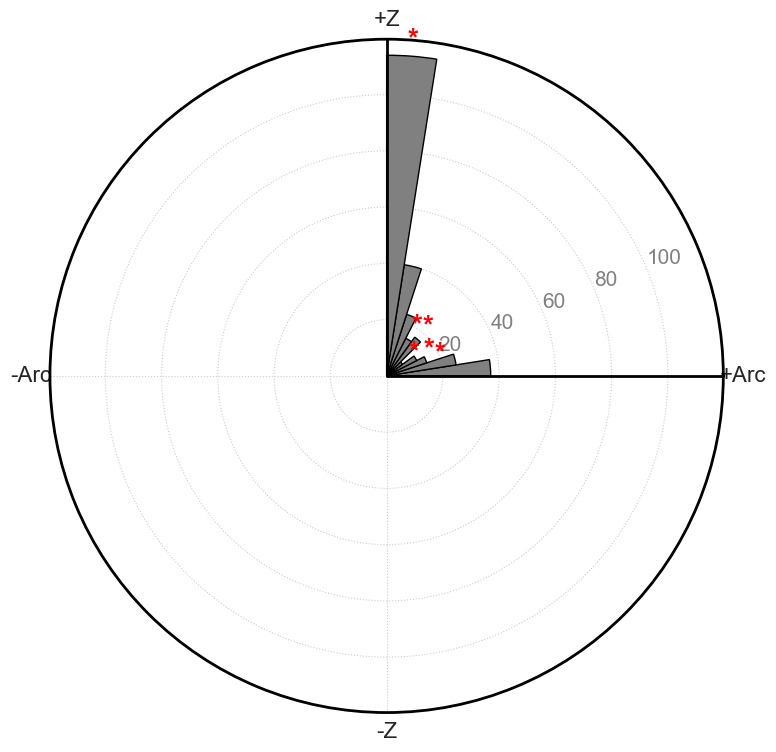

In [139]:
reload(from_antigravity_peanuts)

mode = 'population'  # 'population', '5_good' 
teeth_mode = 'bottom'   # 'bottom', 'both', 'front'
return_stats = False
absolute_val = True

from_antigravity_peanuts.visualize_vector_analysis(sites_path, mode = mode,  teeth_mode = teeth_mode, return_stats = return_stats, absolute_val = absolute_val, output_file = None)


--- Simulated Null Distribution Stats ---
Total simulated vectors: 15500
Chi-square test for uniformity: stat=1.830, p=0.9939
Result: Simulated distribution is not significantly different from mathematical uniform.
Mean Null Profile Distance (Z): 0.55 mm
Mean Null Arc Distance: 0.62 mm
Longitudinal / Transversal Ratio: 0.88x


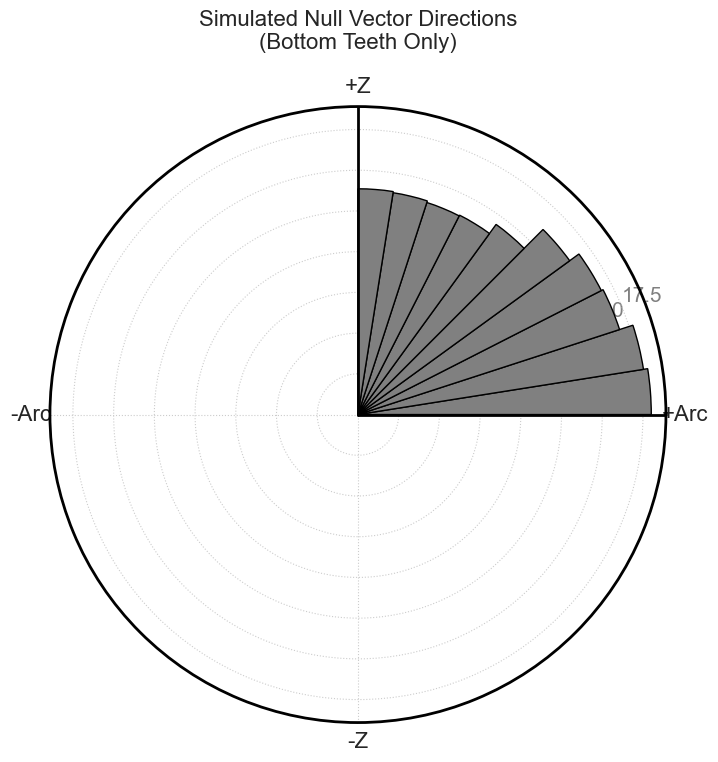

In [215]:
reload(from_antigravity_peanuts)

from_antigravity_peanuts.visualize_simulated_uncorrelated_vectors(
    sites_dir=sites_holes_path, 
    output_file=None, 
    sims_per_sequence=100
)

## Panel I

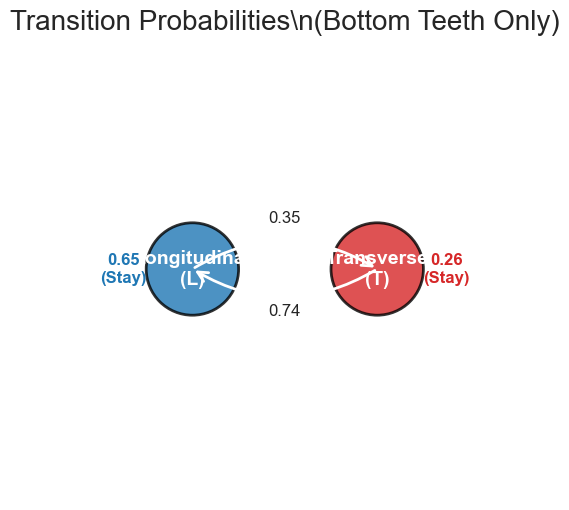

In [141]:
reload(from_antigravity_peanuts)

mode = 'population'  # 'population', '5_good' 
teeth_mode = 'bottom'   # 'bottom', 'both', 'front'

from_antigravity_peanuts.visualize_transition_graph(sites_path, mode = mode, teeth_mode = teeth_mode)

## Panel J

Building Mesh Graph for Geodesic Distance (Shared)...


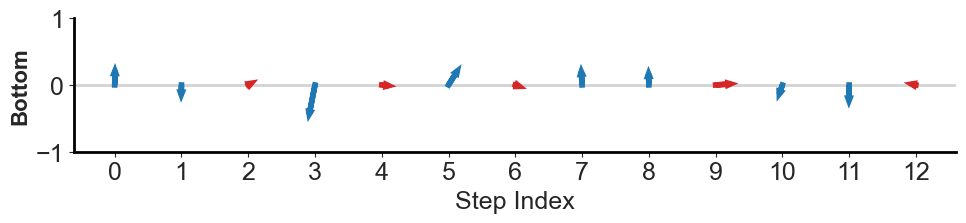

In [143]:
reload(from_antigravity_peanuts)

sites_clamps = sites_path + "/5_good_sites.json"
show_bottom = True
show_front = False
normalize_amplitude = True

from_antigravity_peanuts.visualize_arrow_sequence(sites_clamps, show_bottom = show_bottom, show_front = show_front, normalize_amplitude = normalize_amplitude, output_file = None)

## Panel K

Building Mesh Graph for Geodesic Distance (Shared)...

--- Step Size Statistics ---
Category        | N     | Mean     | Median   | Std     
-------------------------------------------------------
Longitudinal    | 209   | 0.767    | 0.589    | 0.560   
Transverse      | 96    | 0.664    | 0.532    | 0.432   
-------------------------------------------------------


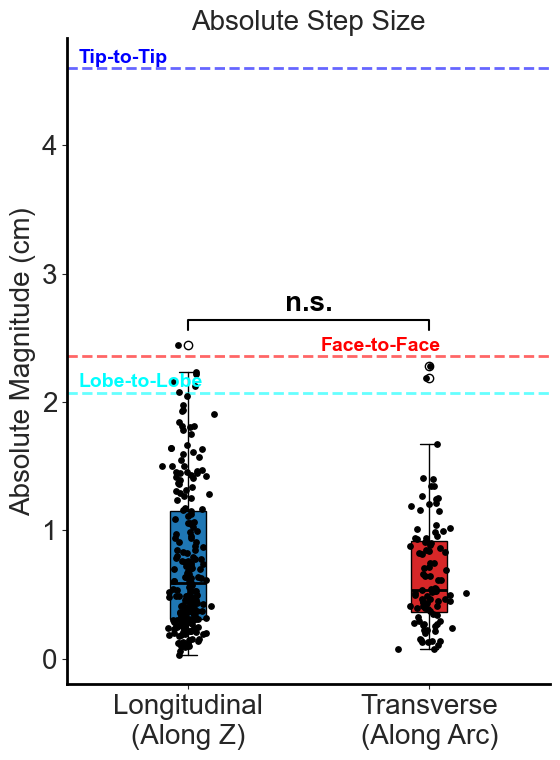

Final p-value:  0.4373864926655622


In [146]:
reload(from_antigravity_peanuts)

mode = 'population'  # 'population', '5_good' 
teeth_mode = 'bottom'   # 'bottom', 'both', 'front'
return_stats = False
normalize_amplitude = False

from_antigravity_peanuts.visualize_step_size_analysis(sites_path, mode = mode, teeth_mode = teeth_mode, return_stats = return_stats, normalize_amplitude = normalize_amplitude, output_file = None)

## Panel L

No sites found.


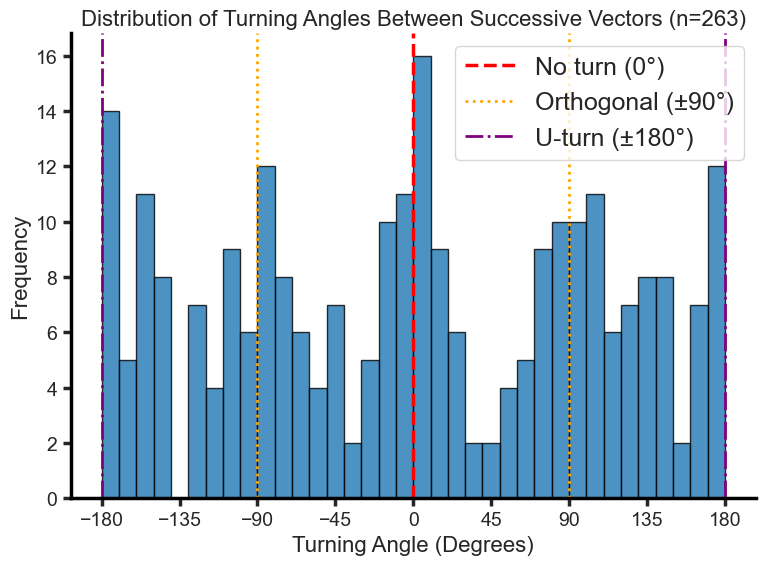

Right Turns (0 to 180°): 133
Left Turns (0 to -180°): 129
Straight/No Turn (0°): 1

Binomial Test p-value: 0.8530
Conclusion: No significant difference between the number of Left and Right turns.


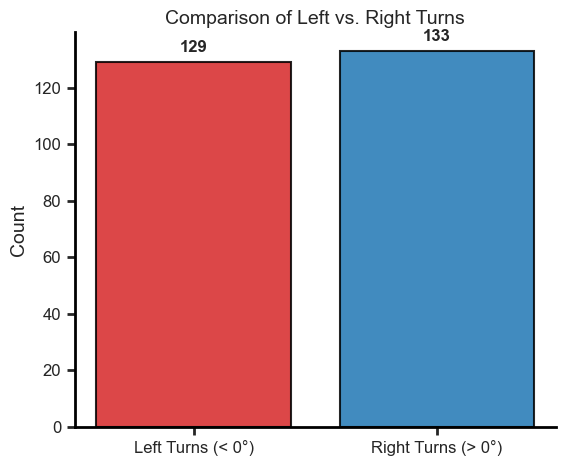

In [149]:
reload(from_antigravity_peanuts)

teeth_mode = 'bottom'

# Call the function to compute and plot the turning angles
turning_angles = from_antigravity_peanuts.compute_and_plot_turning_angles(
    sites_directory=sites_path,
    teeth_mode=teeth_mode,
    output_file=None
)

# Call the new function
from_antigravity_peanuts.plot_turning_angles_bias(
    turning_angles=turning_angles, 
    output_file=None
)

## Panel M

No sites found.


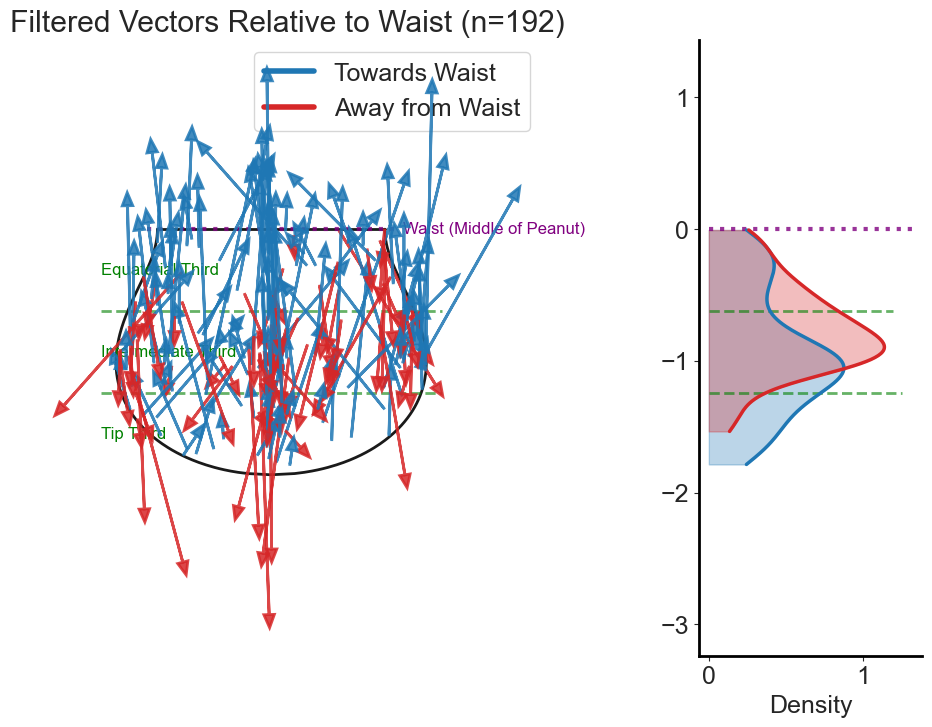

Equatorial Third: 32 Towards Waist, 25 Away from Waist (Total: 57)
Intermediate Third: 55 Towards Waist, 42 Away from Waist (Total: 97)
Tip Third: 32 Towards Waist, 6 Away from Waist (Total: 38)
No sites found.


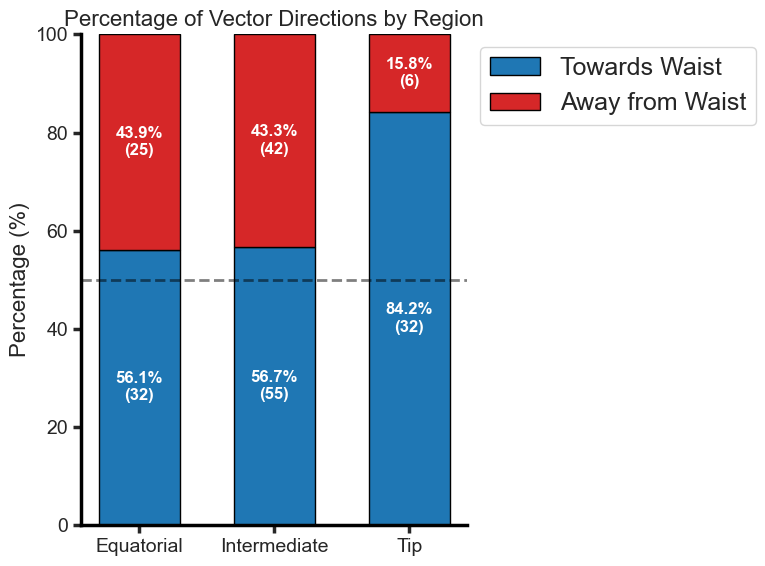

In [153]:
reload(from_antigravity_peanuts)

# Call the function
longitudinal_arrows = from_antigravity_peanuts.plot_longitudinal_barycenter_vectors(
    sites_directory=sites_path,
    teeth_mode='bottom',
    show_full_context=True,
    output_file=None,
    show_marginal=True
)

# Extract counts per section
for region in ['Equatorial', 'Intermediate', 'Tip']:
    region_arrows = [a for a in longitudinal_arrows if a['region'] == region]
    towards = sum(1 for a in region_arrows if a['direction'] == 'Towards Waist')
    away = sum(1 for a in region_arrows if a['direction'] == 'Away from Waist')
    print(f"{region} Third: {towards} Towards Waist, {away} Away from Waist (Total: {len(region_arrows)})")
    
teeth_mode = 'bottom'

# Call the function
ratio_counts = from_antigravity_peanuts.plot_longitudinal_barycenter_ratios(
    sites_directory=sites_path,
    teeth_mode=teeth_mode,
    output_file=None,
    plot_mode='stacked'   # 'staced' or 'ratio' 
)

## Panel O

see modeling - target search on ovoid

## Panel P

see modeling - target search on ovoid

## Panel R

see modeling - optimal walks

## Panel S

see modeling - optimal walks

# Figure 4

## Panel C


--- Prob Contact Stats ---
Global Chi-square: p=3.836e-15
Trend Test (Regression): slope=0.437, p=0.0007049, R^2=0.957


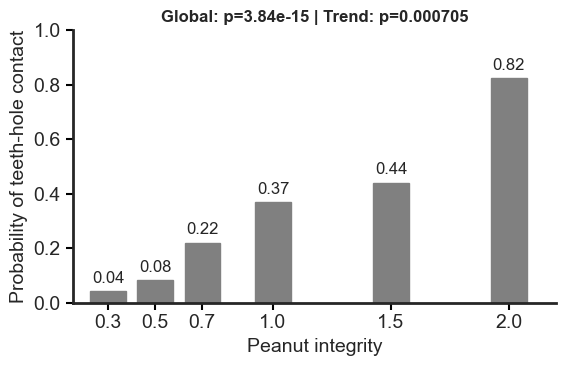

In [165]:
reload(Peanuts)

Peanuts.plot_prob_contact(dict_ethograms, output_file = None)

## Panel D


--- Stats: Rotation vs No Rotation ---
  (Method: False Discovery Rate / Benjamini-Hochberg)
  Peanut       p-raw      p-adj      Sig
  ------------------------------------------
  three        0.0743     0.08916    n.s.
  five         0.0160     0.02529    *
  seven        0.0169     0.02529    *
  one          0.0000     4.984e-05  *
  onehalf      0.0006     0.001884   *
  two          0.4062     0.4062     n.s.


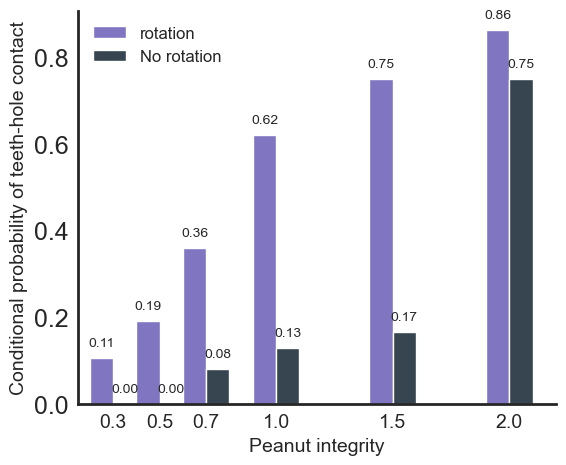

In [168]:
reload(Peanuts)

Peanuts.plot_prob_contact_rotation(dict_ethograms, output_file = None)

## Panel E

=== PSTH Event Counts ===
Eat events found in eating scoring: 41
Clamp events found in ethogram: 181
Teeth Hole Contact events found in ethogram: 46
Clamps mapped within ±20.0s window: 143
Teeth contacts mapped within ±20.0s window: 38


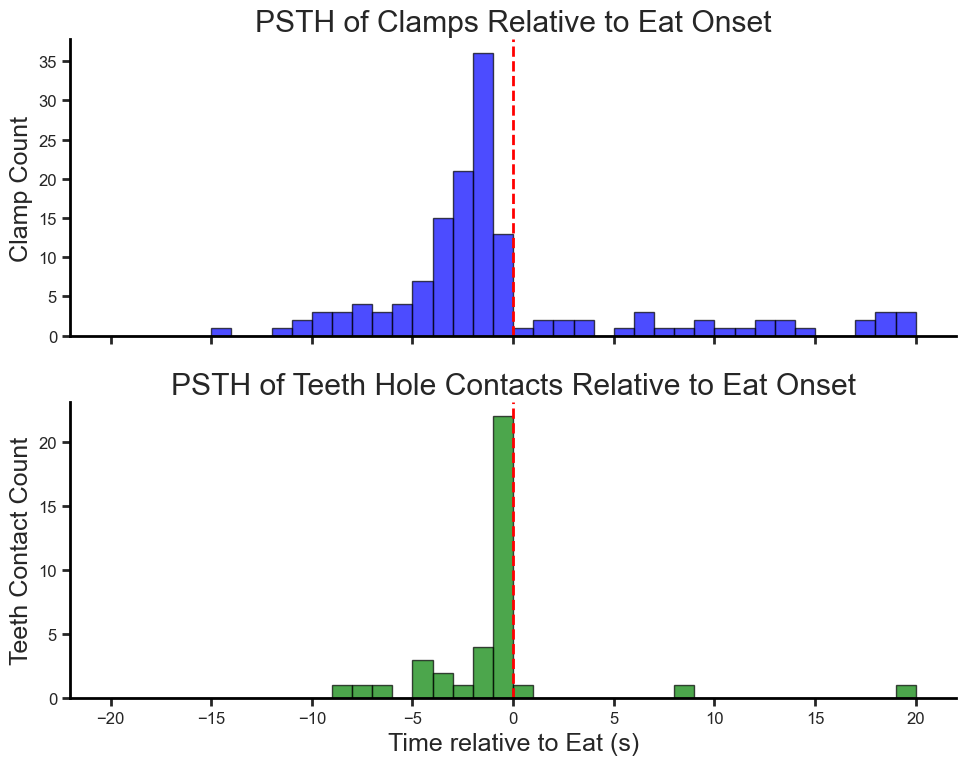

In [177]:
reload(from_antigravity_peanuts)

# Generate and display the PSTH plot
fig, axes = from_antigravity_peanuts.plot_eating_psth(
    ethogram_path=ethogram_hole_path,
    eating_scoring_path=eating_scoring_path,
    window=20.0, # Change this to zoom in/out (e.g. 10.0 for +/- 10 seconds)
    save_path=None
)

## Panel F

       comparison  n_control  n_group  power
0  0,3 vs control          7        8  0.315
1  0,5 vs control          7        8  0.264
2  0,7 vs control          7        8  0.597
3    1 vs control          7        5  0.258
4  1,5 vs control          7        4  0.795
5    2 vs control          7        5  1.000
Scatter hoard 1.0
Scatter hoard 0.7651515151515151
Scatter hoard 0.7333333333333334
Scatter hoard 0.5681818181818181
Scatter hoard 0.56
Scatter hoard 0.5147058823529411
Scatter hoard 0.25

Corrected Holm–Bonferroni p-values across types:
1: p=0.4055 (n.s.)
2: p=0.4055 (n.s.)
3: p=0.1452 (n.s.)
4: p=0.4055 (n.s.)
5: p=0.1288 (n.s.)
6: p=0.0292 (*)

Stats regression lines:
  Scatter hoard linear: p = 0.0000223608
Scatter hoard: linear R²=0.3448, p=0.0000


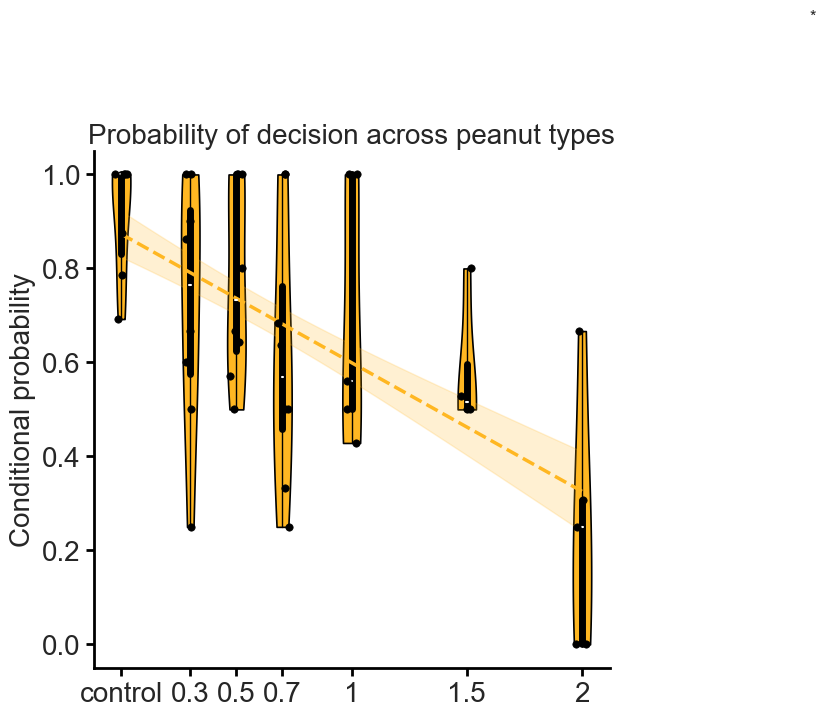

In [183]:
reload(Peanuts)

param_data['type'] = [str(el) for el in param_data['type']]
param_data['ID_session'] = param_data['ID'] + "_" + param_data['Session'].astype(str)

order = ['control', '0,3', '0,5', '0,7', '1', '1,5', '2']
proba = 'behavior'   # 'behavior', 'given rotate', 'given behavior', 'given teeth-hole'
group_by = 'ID'
connect_scatter = False
min_N_peanuts_per_violin = 2
max_N_missing_violins = 10
show_reg_lines = True
only_scatter_hoard = True
violin_width = 15
fig_width = 10
comparisons = 'control'   # 'all' or 'control'
fit_type = 'linear'   # 'sigmoid', 'linear'

violin_df_rotations = Peanuts.plot_arena(param_data, proba, order, group_by, min_N_peanuts_per_violin, max_N_missing_violins = max_N_missing_violins, connect_scatter = connect_scatter, show_reg_lines = show_reg_lines, save_path = None, only_scatter_hoard = only_scatter_hoard, violin_width = violin_width, fig_width = fig_width, comparisons = comparisons, fit_type = fit_type)

## Panel G


--- Stats: Outcome SH vs Eat (Shifted by THC) ---
Outcome Ratio (Eat:SH):
  THC (+):  63:11 (86.3% vs 15.1%)
  THC (-):  30:172 (14.4% vs 82.3%)
Fisher Exact (Behavior Choice dependent on THC): p=1.224e-27, odds=32.84
Result: THC significantly shifts the balance between Eating and Scatter-hoarding.


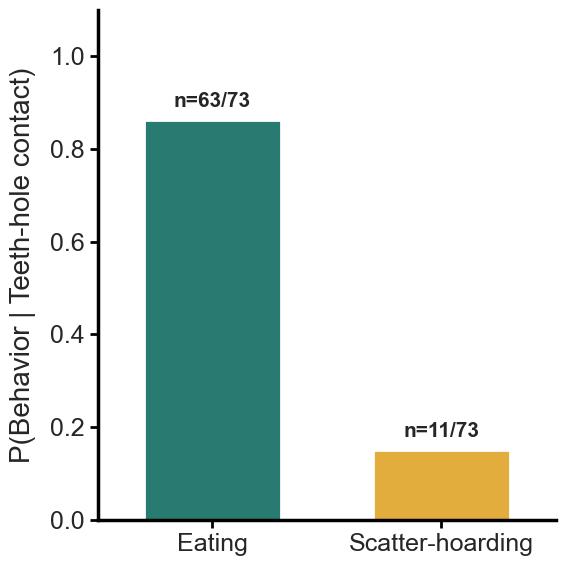

In [185]:
reload(Peanuts)

Peanuts.compute_prob_outcome_given_thc(dict_ethograms, output_file = None)

## Panel H

              Mixed Linear Model Regression Results
Model:                MixedLM     Dependent Variable:     y       
No. Observations:     85          Method:                 REML    
No. Groups:           11          Scale:                  0.1133  
Min. group size:      3           Log-Likelihood:         -51.4517
Max. group size:      22          Converged:              Yes     
Mean group size:      7.7                                         
------------------------------------------------------------------
                        Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------
Intercept                0.763    0.155  4.923 0.000  0.459  1.067
assessing_time           0.033    0.023  1.423 0.155 -0.012  0.077
jaw_movement            -0.019    0.018 -1.048 0.295 -0.054  0.016
licking                  0.003    0.023  0.116 0.908 -0.042  0.048
peanut_type              0.048    0.097  0.494 0.621 -0.143  0.239
rotation  

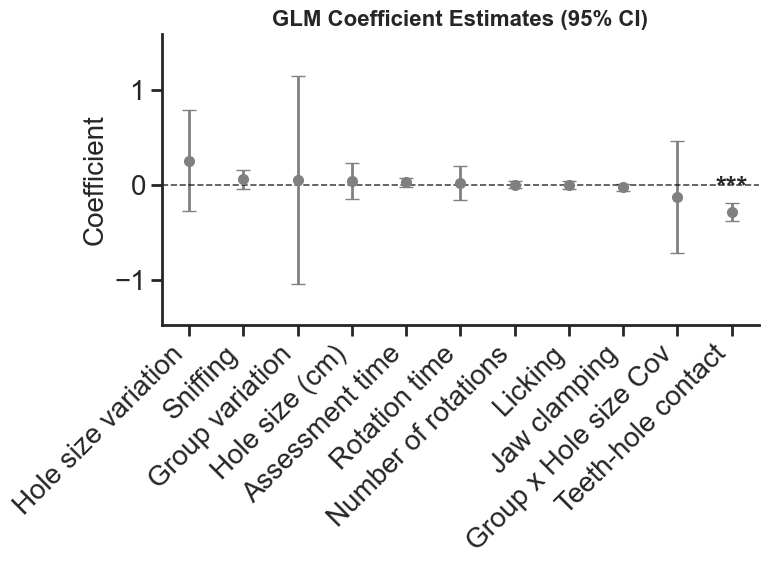

In [192]:
reload(Peanuts)

output = Peanuts.build_output(dict_ethograms)

peanut_map = {
        '0,3': 'three',
        '0,5': 'five',
        '0,7': 'seven',
        '1': 'one',
        '1,5': 'onehalf',
        '2': 'two',
        '2+': 'twoplus',
        'control': 'control'
    }

param_data['type'] = [str(el) for el in param_data['type']]
param_data['ID_session'] = param_data['ID'] + "_" + param_data['Session'].astype(str)
param_data['peanut_type'] = param_data['type'].map(peanut_map)
param_data['video_name'] = [f"{id_[:4]}_{date.replace('/', '').capitalize()}_{order:04d}_{type_}" for id_, date, order, type_ in zip(param_data['ID'], param_data['Date'], param_data['order_taken'], param_data['peanut_type'])]

for peanut in range(len(output)):
    video_title = output[peanut]['file name'].split('.')[0].capitalize()
    if video_title in list(param_data['video_name']):
        output[peanut]['teeth from sheet'] = param_data['teeth-hole contact'][param_data['video_name'] == video_title].iloc[0]
    else:
        output[peanut]['teeth from sheet'] = np.nan

output_teeth = Peanuts.create_teeth_doublecheck(output)

# 1. Feature Prep (ensure peanut_type is NOT in behavior_to_remove)
behavior_to_remove = [
    'previous outcome', 'teeth-hole contact', 'file name', "pause",
    "dropping peanut", 'ear clapping', 'grabbing peanut',
    "lifting", 'target', 'mouth', 'bending', 'chewing', 'teeth from sheet'
]
X, y, cleaned_df = Peanuts.prepare_behavior_df(output_teeth, behavior_to_remove)

# 2. Filter bad animals
outcome_diversity = cleaned_df.groupby("animal_id")["y"].nunique()
bad_animals = outcome_diversity[outcome_diversity == 1].index.tolist()
mask = ~cleaned_df["animal_id"].isin(bad_animals)

cleaned_df_filtered = cleaned_df[mask].copy()
X_filtered = X[mask].rename(columns=lambda col: col.replace(' ', '_').replace('-', '_')).reset_index(drop=True)
y_filtered = y[mask].reset_index(drop=True)
animal_id = cleaned_df_filtered['animal_id'].reset_index(drop=True)

# 3. Build features_df
features_df = pd.concat([animal_id, X_filtered], axis=1)
features_df['y'] = y_filtered
features_df = features_df.dropna(subset=['y'])

predictors = X_filtered.columns.difference(['const'])
formula = "y ~ " + " + ".join(predictors)

# 4. Run Mixing Effect Model
model_random = sm.regression.mixed_linear_model.MixedLM.from_formula(
    formula, 
    data=features_df, 
    groups=features_df["animal_id"], 
    re_formula="~peanut_type"
)
res_random = model_random.fit()

print(res_random.summary())
Peanuts.plot_GLM_coeffs(res_random, output_file=None)

## Panel I

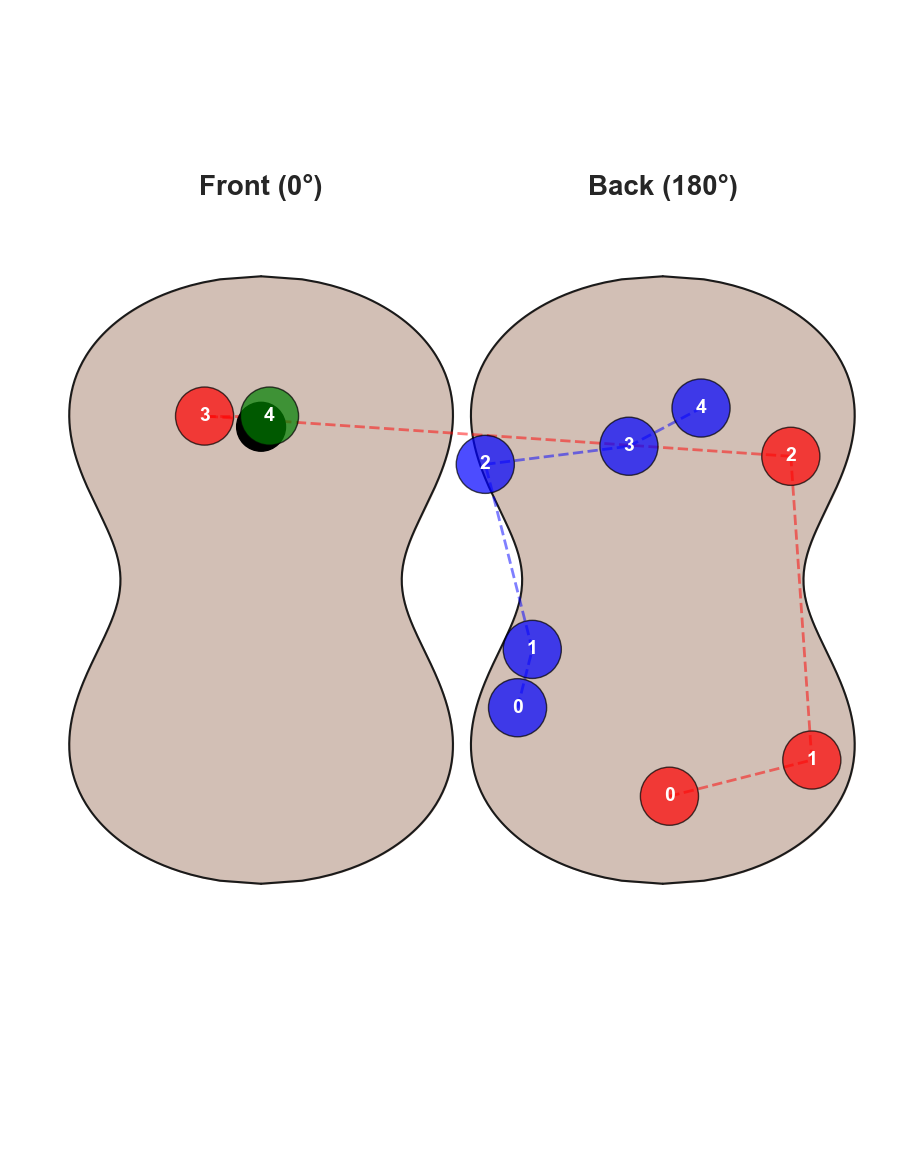

In [200]:
reload(from_antigravity_peanuts)

clamp_hole_path = sites_holes_path + "/hole_leftnosedot_4_sites.json"

# Use the hole ethogram and a specific hole coordinate json file
show_bottom = True
show_front = True
show_lines = True
simple_lines = True
bottom_color = 'red'
front_color = 'blue'

from_antigravity_peanuts.plot_sequence_for_peanut_two_faces(
    sites_path=clamp_hole_path, 
    ethogram_path=ethogram_hole_path,
    show_bottom = show_bottom,
    show_front = show_front,
    show_lines = show_lines,
    simple_lines = simple_lines,
    bottom_color = bottom_color,
    front_color = front_color,
    output_file = None)

## Panel J


--- Rose Plot Uniformity Stats ---
Total Vectors: 155
Chi-square Stat: 78.226, p-value: 3.635e-13
Result: Distribution is significantly different from uniform (biased).

Post-hoc Bin Analysis (vs Uniform):
  Range           Count    p_uncorr   p_adj      Sig
  -------------------------------------------------------
  [0-9°]          17       0.688      0.7043     n.s.
  [9-18°]         20       0.2283     0.7043     n.s.
  [18-27°]        7        0.02286    0.16       +
  [27-36°]        6        0.01097    0.08779    +
  [36-45°]        9        0.0818     0.4908     n.s.
  [45-54°]        3        0.0008177  0.007359   *
  [54-63°]        10       0.1409     0.7043     n.s.
  [63-72°]        21       0.1409     0.7043     n.s.
  [72-81°]        19       0.3487     0.7043     n.s.
  [81-90°]        43       1.8e-13    1.8e-12    *


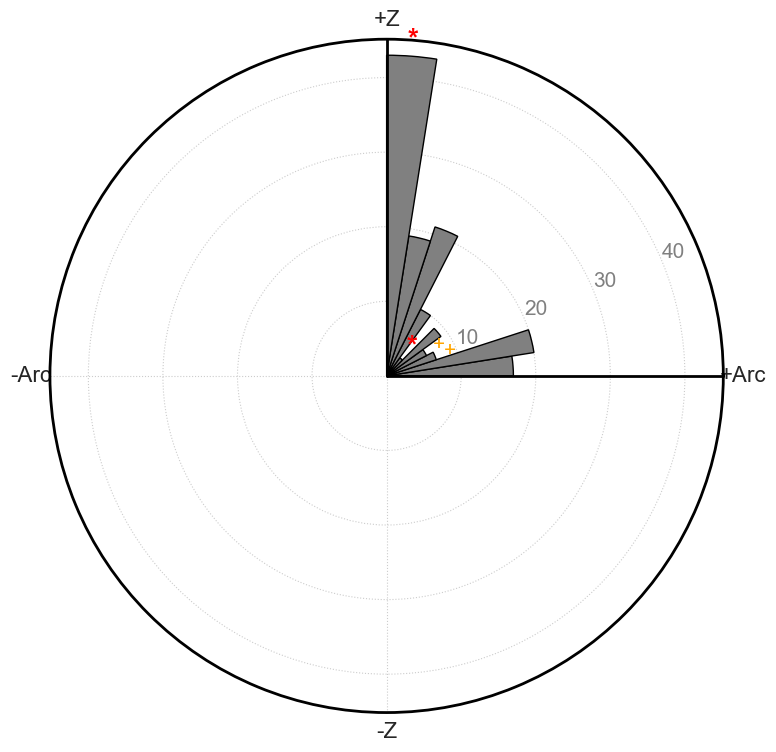

In [203]:
reload(from_antigravity_peanuts)

mode = 'population'  # 'population', '5_good' 
teeth_mode = 'bottom'   # 'bottom', 'both', 'front'
return_stats = False
absolute_val = True

from_antigravity_peanuts.visualize_vector_analysis(sites_holes_path, mode = mode,  teeth_mode = teeth_mode, return_stats = return_stats, absolute_val = absolute_val, output_file = None)


--- Simulated Null Distribution Stats ---
Total simulated vectors: 7750
Chi-square test for uniformity: stat=1.351, p=0.9981
Result: Simulated distribution is not significantly different from mathematical uniform.
Mean Null Profile Distance (Z): 0.55 mm
Mean Null Arc Distance: 0.62 mm
Longitudinal / Transversal Ratio: 0.89x
Saved plot to C:\Users\nacholab-adm\Desktop\figures\last_three_movements.svg


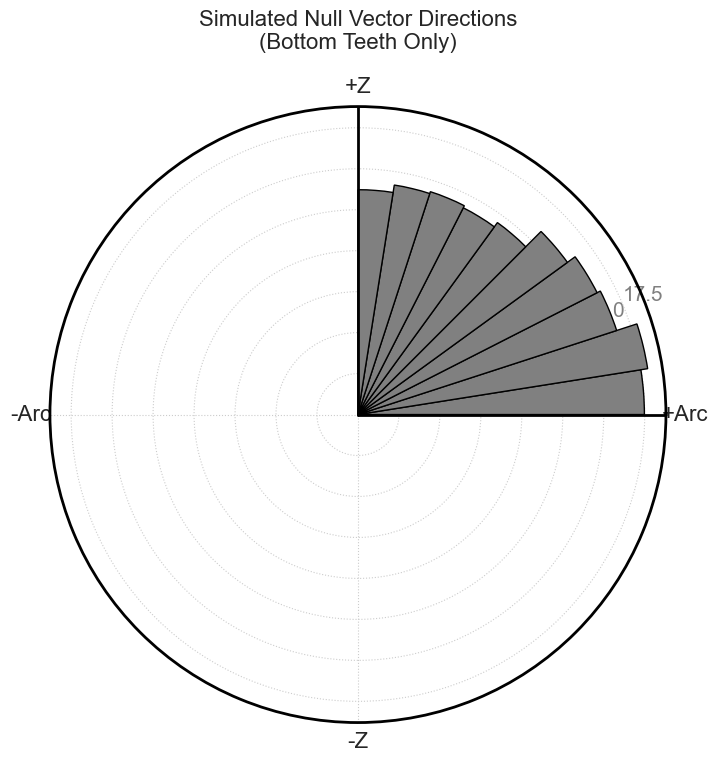

In [213]:
reload(from_antigravity_peanuts)

mode = 'population'  # 'population', '5_good' 
teeth_mode = 'bottom'   # 'bottom', 'both', 'front'
return_stats = False
absolute_val = True

# This plots ONLY the null distribution of the URW simulation for the hole data lengths!
from_antigravity_peanuts.visualize_simulated_uncorrelated_vectors(
    sites_dir=sites_holes_path, 
    mode=mode,  
    teeth_mode=teeth_mode, 
    return_stats=return_stats, 
    absolute_val=absolute_val, 
    output_file=output_file,
    sims_per_sequence=50
)

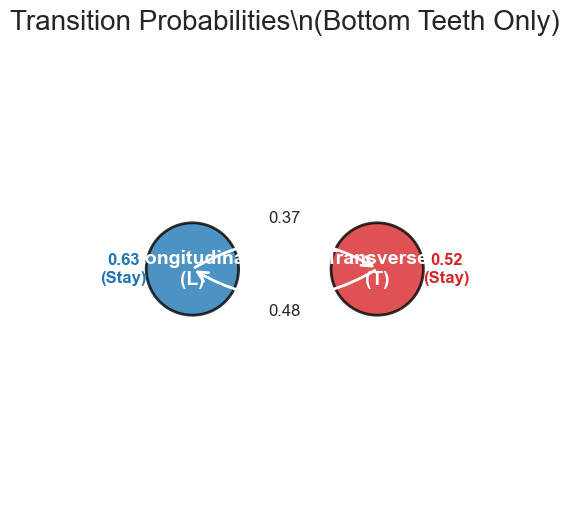

In [204]:
reload(from_antigravity_peanuts)

mode = 'population'  # 'population', '5_good' 
teeth_mode = 'bottom'   # 'bottom', 'both', 'front'

from_antigravity_peanuts.visualize_transition_graph(sites_holes_path, mode = mode, teeth_mode = teeth_mode, output_file = None)

## Panel K

=== Transition Evolution Summary ===
Total videos parsed: 1
Total transition segments collected: 83


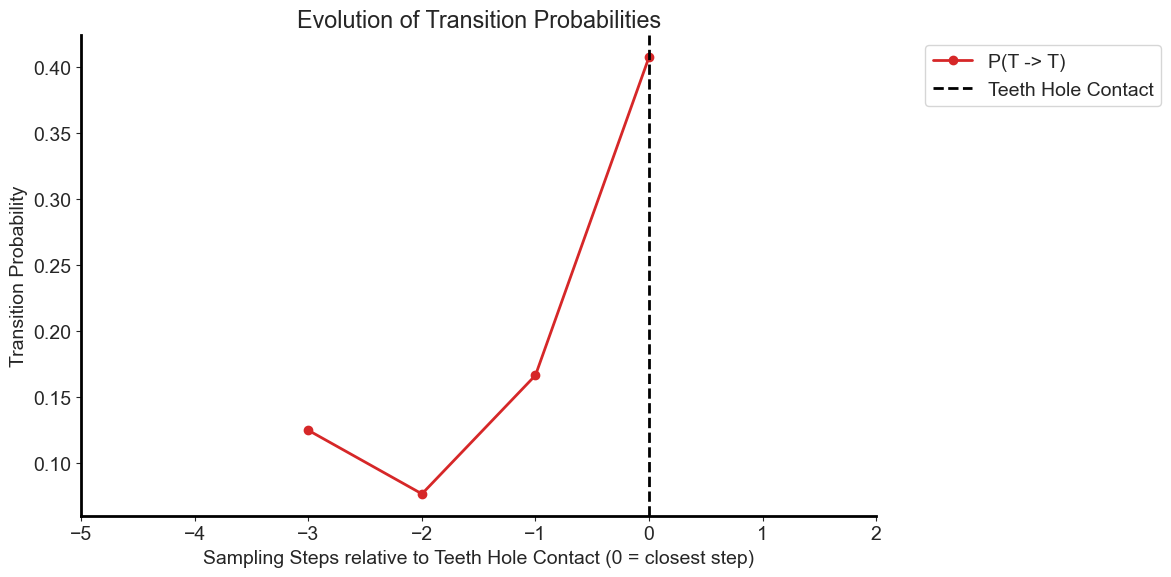

In [208]:
reload(from_antigravity_peanuts)

# Visualize how transition probabilities evolve over time, relative to Teeth Hole Contact!
from_antigravity_peanuts.plot_transition_evolution(
    ethogram_path=ethogram_hole_path, 
    sites_directory=sites_holes_path, 
    teeth_mode='bottom', 
    output_file=None,
    bin_size=1.0,           # Size of the time bins in seconds
    time_range=(-5, 2),    # How far before and after t=0 to analyze
    x_axis_mode='steps',      # 'steps' or 'time'
    min_sample_size=3,
    probability_mode='marginal',  # <--- Set this to 'marginal' to sum to 1 otherwise 'conditional'
    show_only_TT=True
)

## Panel L

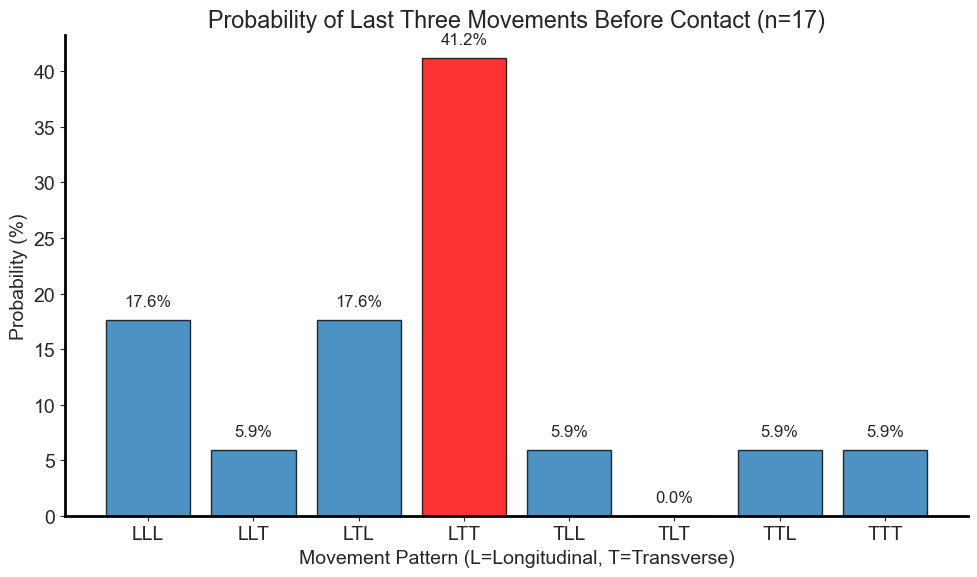

In [211]:
reload(from_antigravity_peanuts)

# Generate the plot
from_antigravity_peanuts.plot_last_three_movements_probability(
    ethogram_path=ethogram_hole_path, 
    sites_directory=sites_holes_path, 
    teeth_mode='bottom', 
    output_file=None
)

## Panel M


--- Spearman Rank Correlation (Pre-Contact Ramp-Up) ---
Testing steps from min to 0 (N=41 individual movements)
Spearman rho: 0.100
p-value:      0.5323
Result: No significant monotonic trend leading up to the hole.
-------------------------------------------------------



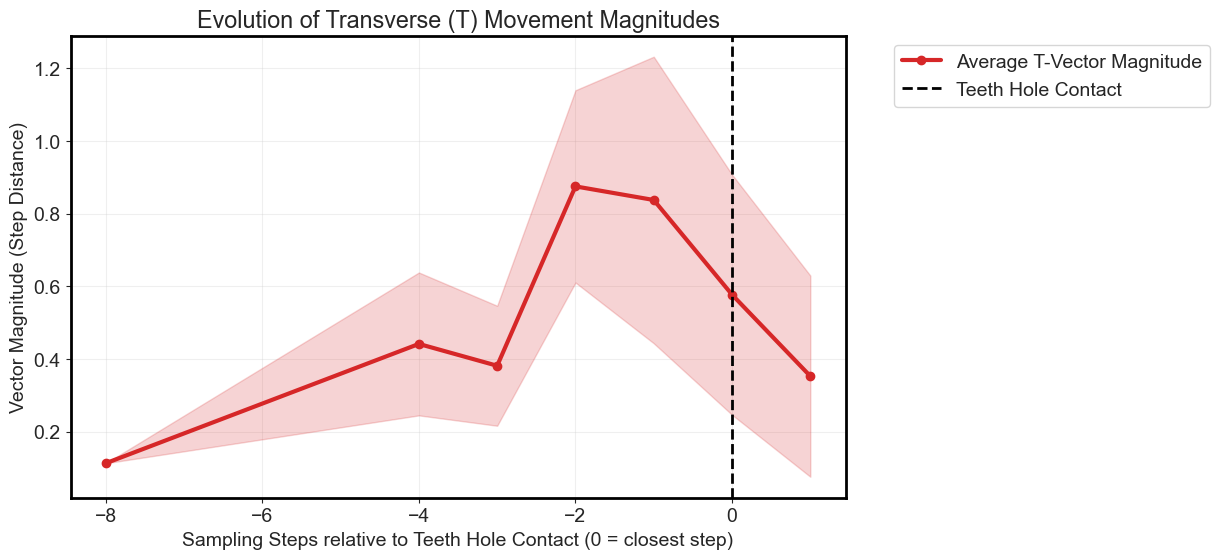

In [217]:
reload(from_antigravity_peanuts)

from_antigravity_peanuts.plot_vector_magnitude_evolution(
    ethogram_path=ethogram_hole_path, 
    sites_directory=sites_holes_path, 
    teeth_mode='bottom', 
    output_file=None,
    time_range=(-15, 15),   # Plots 15 steps before and 15 steps after
    movement_type='T'    # Try 'both', 'L', or 'T'
)

## Panel N


Contingency Table (Paired Bottom vs Top Teeth Touch):
               Top Teeth Touch  No Top Teeth Touch
Bottom Teeth    2                19                
No Bottom Teeth 4                0                 

McNemar's exact test p-value: 0.0026
Proportion of sessions where Bottom Teeth touched: 84.0%
Proportion of sessions where Top Teeth touched:    24.0%


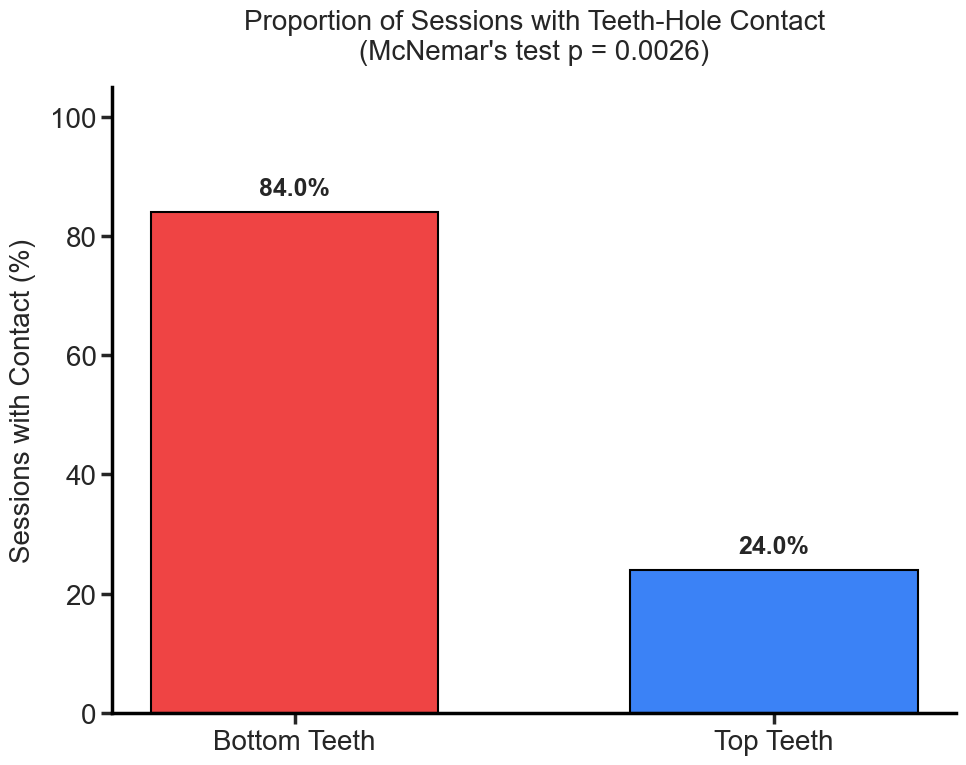

In [220]:
reload(from_antigravity_peanuts)

df_results = from_antigravity_peanuts.compare_binary_teeth_contacts(
    sites_dir=sites_holes_path,
    ethogram_path=ethogram_hole_path,
    output_file=None,
    use_rectangle=True,     # Using rectangle representation for the clamp
    clamp_dims=(0.7, 0.3),
    filter_no_contact=True
)

## Panel O - U

see modeling - DDM

# Modeling

## SH-mode

Per-animal model comparison (sum of AIC across animals):
   Model     AIC_sum   AIC_mean
2     CP  236.325498  11.253595
1  Trend  245.463000  11.688714
3    HMM  387.352970  18.445380
0    IID  486.193012  23.152048


[LOOCV] Running subject-level cross-validation (21 animals)...


100%|██████████████████████████████████████████████████████████████████████████████████| 21/21 [00:39<00:00,  1.87s/it]


LOOCV Model Comparison (Predictive Log-Likelihood):
   Model  Predictive_LL     Avg_LL
3    HMM    -141.037738  -6.716083
4   HSMM    -164.881482  -7.851499
2     CP    -247.790091 -11.799528
1  Trend    -257.612332 -12.267254
0    IID    -310.165213 -14.769772

Global (pooled) model comparison:
          Model  k          LL         AIC
3    HMM_global  4 -136.640312  281.280624
4   HSMM_global  4 -151.585786  311.171571
2     CP_global  3 -227.896734  461.793467
1  Trend_global  2 -232.190329  468.380659
0    IID_global  1 -294.586375  591.172751

First plot saved to C:\Users\nacholab-adm\Desktop\figures\SH_mode_models.svg


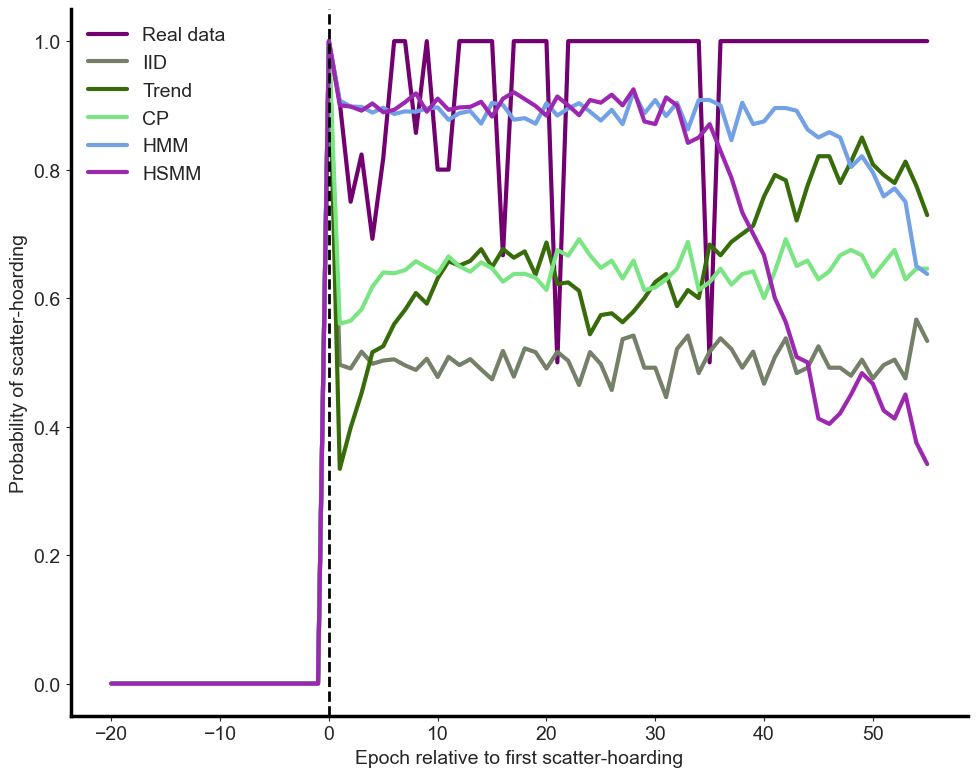

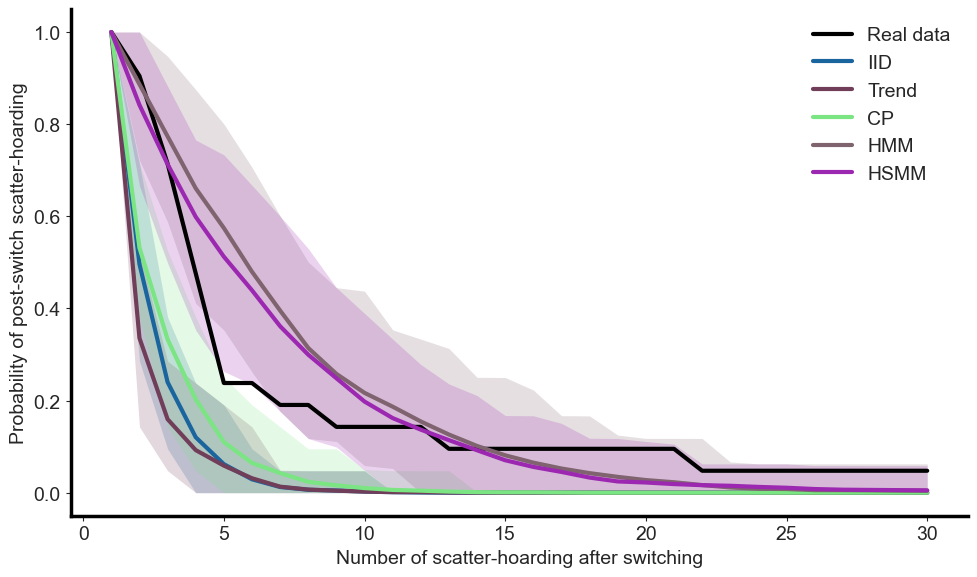

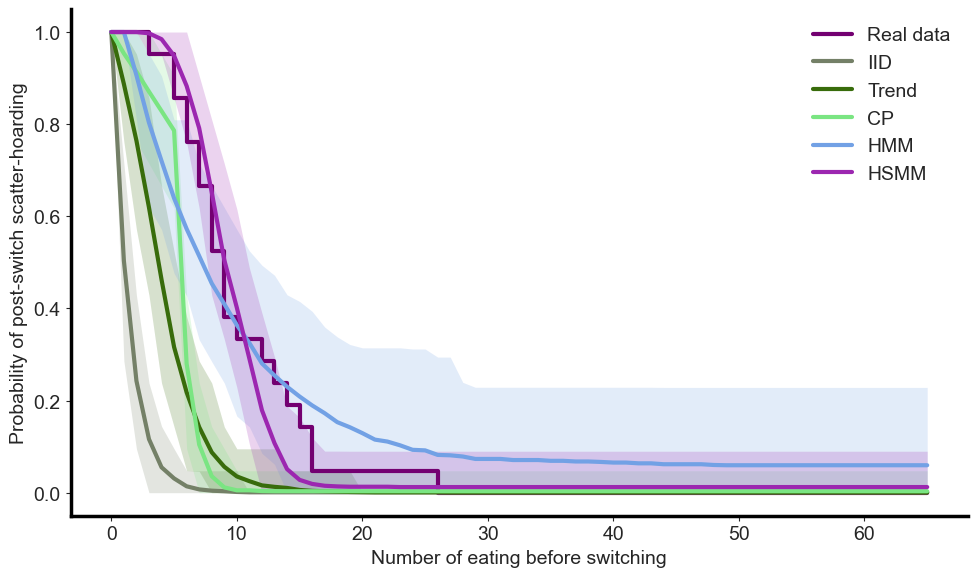

KM quantiles (empirical vs global predictive intervals):
              Model        KM_Q25      KM_Median           KM_Q75
          Empirical           7.0            9.0             13.0
  IID (global pred) 1.0 [1.0,1.0]  1.5 [1.0,2.0]    2.4 [1.0,4.0]
Trend (global pred) 2.7 [2.0,4.0]  4.5 [3.0,6.0]    6.2 [4.7,8.0]
   CP (global pred) 5.4 [3.0,6.0]  6.0 [6.0,6.3]    6.5 [6.0,7.0]
  HMM (global pred) 4.3 [3.0,6.3] 7.6 [5.0,13.0]  15.8 [7.7,65.0]
 HSMM (global pred) 7.9 [6.0,9.0] 9.8 [8.0,11.3] 12.2 [10.0,14.0]


In [261]:
reload(pooled_model_pipeline_tau_global)

aic_table, global_params = pooled_model_pipeline_tau_global.run_full_pipeline(structured_data)

In [262]:
aic_table

,Model,k,LL,AIC
3,HMM_global,4,-136.640312,281.280624
4,HSMM_global,4,-151.585786,311.171571
2,CP_global,3,-227.896734,461.793467
1,Trend_global,2,-232.190329,468.380659
0,IID_global,1,-294.586375,591.172751


Model comparison plot saved to C:\Users\nacholab-adm\Desktop\figures\AIC_comparison.svg


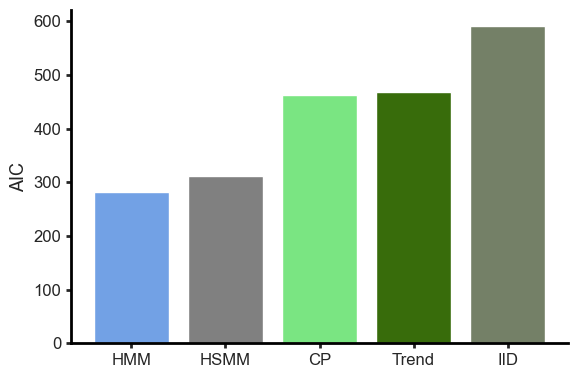

In [267]:
reload(pooled_model_pipeline_tau_global)

save_path = r"figures/AIC_comparison.svg"
pooled_model_pipeline_tau_global.plot_model_comparison(aic_table, save_path=save_path)

In [263]:
global_params

{'IID': {'p': np.float64(0.4988235294117647)},
 'Logistic': {'a': -2.0809857320019054, 'dlt': 4.149091192968417},
 'Change-point': {'p0': 0.047619047619047616, 'p1': 0.646875, 'tau': 5},
 'HMM': {'q': 1e-06,
  'r': 0.8953725060237026,
  'pi': 0.11156735369525382,
  'eps': 1e-06},
 'HSMM': {'q': 1e-06,
  'r': 0.9000587230816824,
  'lam0': 7.611820154539165,
  'lam1': 42.84921610898128}}

In [282]:
reload(pooled_model_pipeline_tau_global)

simulated_outputs = pooled_model_pipeline_tau_global.run_models_with_global_params(
    structured_data, 
    global_params, 
    seed=9
)
# You can access simulated behaviors like this:
iid_y = simulated_outputs["IID_y"]
hmm_y = simulated_outputs["HMM_y"]
hmm_s = simulated_outputs["HMM_s"]

[1, 1, 4, 1, 1, 4, 8, 4, 9, 6, 13, 5, 9, 1, 18, 2, 2, 7, 6, 2, 2]
[1, 1, 4, 1, 1, 4, 8, 4, 9, 6, 13, 5, 9, 1, 18, 2, 2, 7, 6, 2, 2]
C:\Users\nacholab-adm\Desktop\figures/SH_mode_HMM_fited.svg


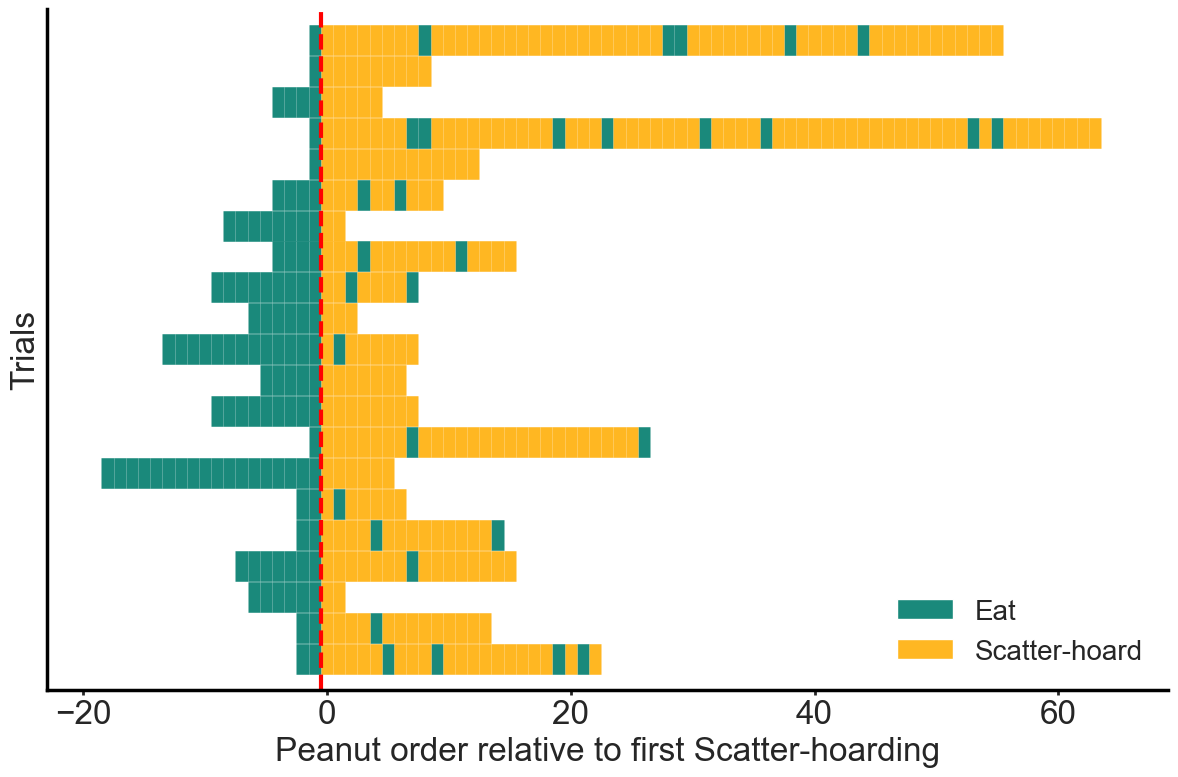

In [283]:
reload(modeling)

aligned_matrix, zero_idx = modeling.align_trials1(hmm_y)
modeling.plot_aligned_bars(aligned_matrix, zero_idx, plot_probability=False, metric = 'HMM_fited')

[1, 1, 4, 1, 1, 4, 8, 4, 9, 6, 13, 5, 9, 1, 18, 2, 2, 7, 6, 2, 2]
[1, 1, 4, 1, 1, 4, 8, 4, 9, 6, 13, 5, 9, 1, 18, 2, 2, 7, 6, 2, 2]
C:\Users\nacholab-adm\Desktop\figures/SH_mode_HMM_fited.svg


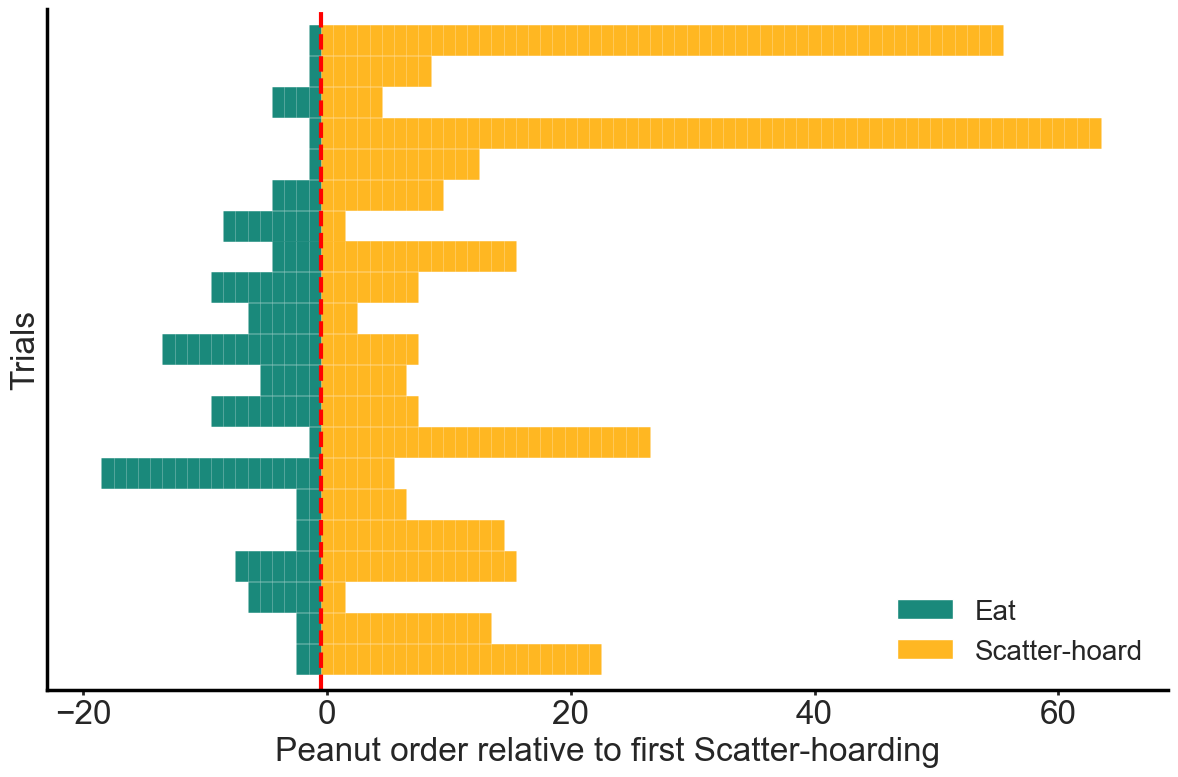

In [284]:
reload(modeling)

aligned_matrix, zero_idx = modeling.align_trials1(hmm_s)
modeling.plot_aligned_bars(aligned_matrix, zero_idx, plot_probability=False, metric = 'HMM_fited')

Computing AIC landscape slices (this may take a minute)...
HMM AIC landscape saved to C:\Users\nacholab-adm\Desktop\figures\HMM_Landscape.svg


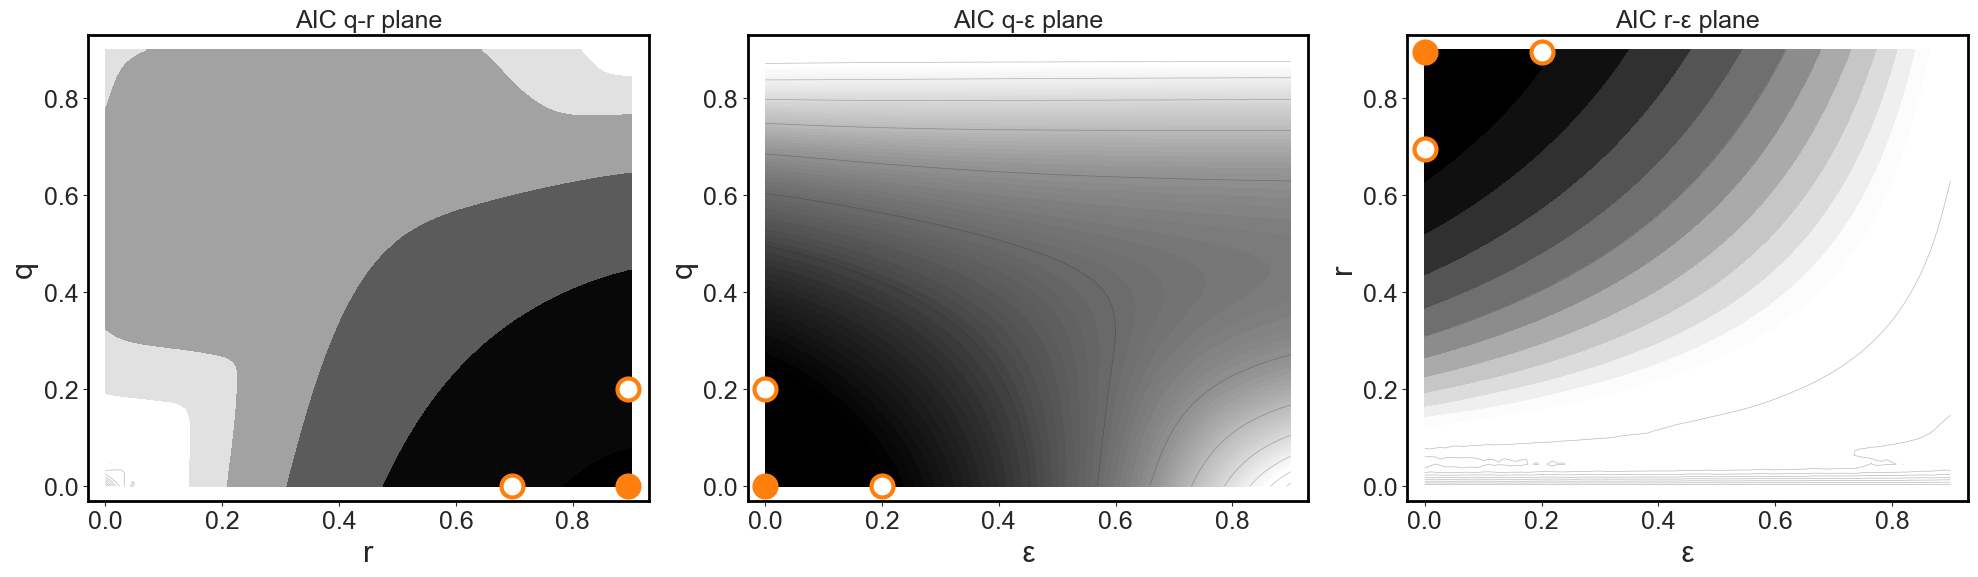

In [268]:
reload(pooled_model_pipeline_tau_global)

hmm_variations = {'fitted': global_params['HMM'], 
                  'r': {'q': 1e-06, 'r': 0.8953725060237026-0.2, 'pi': 0.11156735369525382, 'eps': 1e-06}, 
                  'q': {'q': 1e-06+0.2, 'r': 0.8953725060237026, 'pi': 0.11156735369525382, 'eps': 1e-06}, 
                  'eps': {'q': 1e-06, 'r': 0.8953725060237026, 'pi': 0.11156735369525382, 'eps': 1e-06+0.2}}

save_path = r"figures/HMM_Landscape.svg"
pooled_model_pipeline_tau_global.plot_hmm_aic_landscape(
    structured_data, 
    fitted_params=global_params['HMM'], 
    hmm_variations=hmm_variations,
    save_path=save_path
)

[5, 2, 2, 4, 2, 2, 3, 1, 6, 1, 1, None, 1, 4, 3, 5, 3, 3, 2, 2, 3]
[5, 2, 2, 4, 2, 2, 3, 1, 6, 1, 1, 0, 1, 4, 3, 5, 3, 3, 2, 2, 3]
C:\Users\nacholab-adm\Desktop\figures/SH_mode_simulaton_q.svg


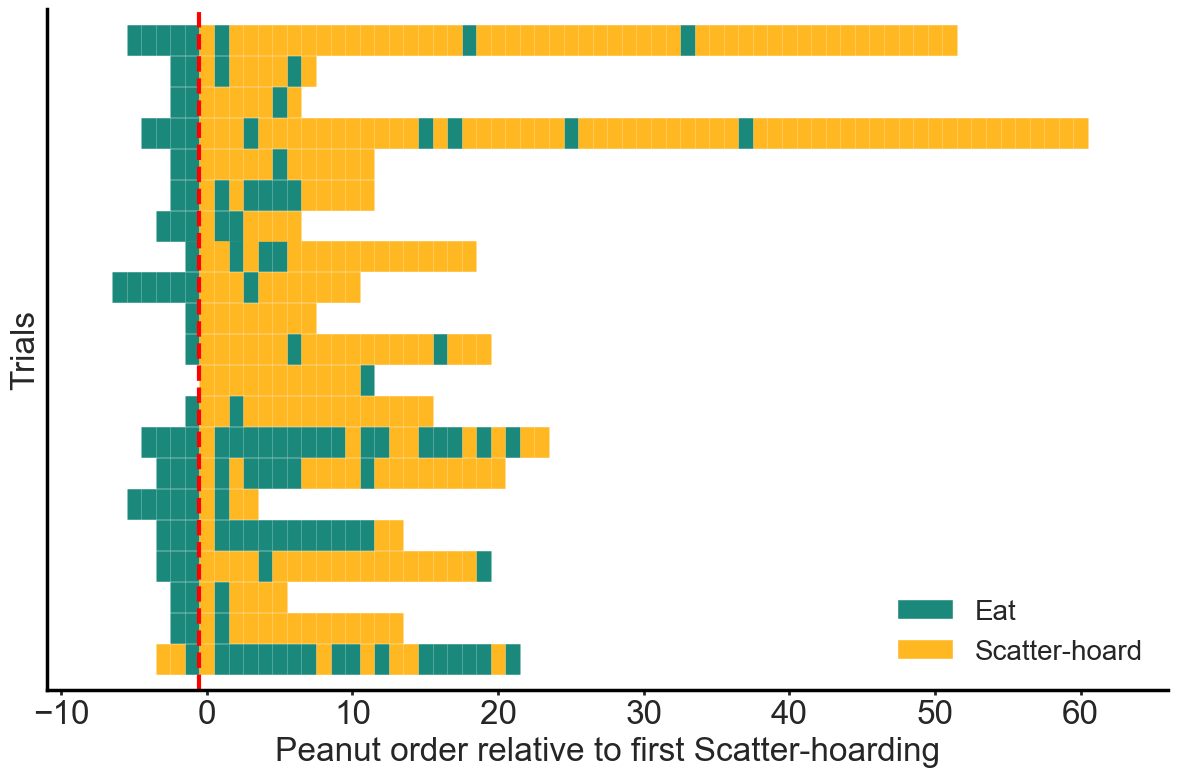

In [290]:
reload(modeling)
reload(pooled_model_pipeline_tau_global)

param_simulated = 'q'

metric = 'simulaton_' + param_simulated

hmm_play = pooled_model_pipeline_tau_global.hmm_emit(structured_data, hmm_variations[param_simulated], force_emit = True)
aligned_matrix, zero_idx = modeling.align_trials1(hmm_play[0])
modeling.plot_aligned_bars(aligned_matrix, zero_idx, plot_probability=False, metric = metric)

[5, 2, 3, 38, 7, 8, 9, 3, 10, 4, 2, 4, 2, 13, 8, 4, 14, 6, 1, 7, 11]
[5, 2, 3, 38, 7, 8, 9, 3, 10, 4, 2, 4, 2, 13, 8, 4, 14, 6, 1, 7, 11]
C:\Users\nacholab-adm\Desktop\figures/SH_mode_simulaton_r.svg


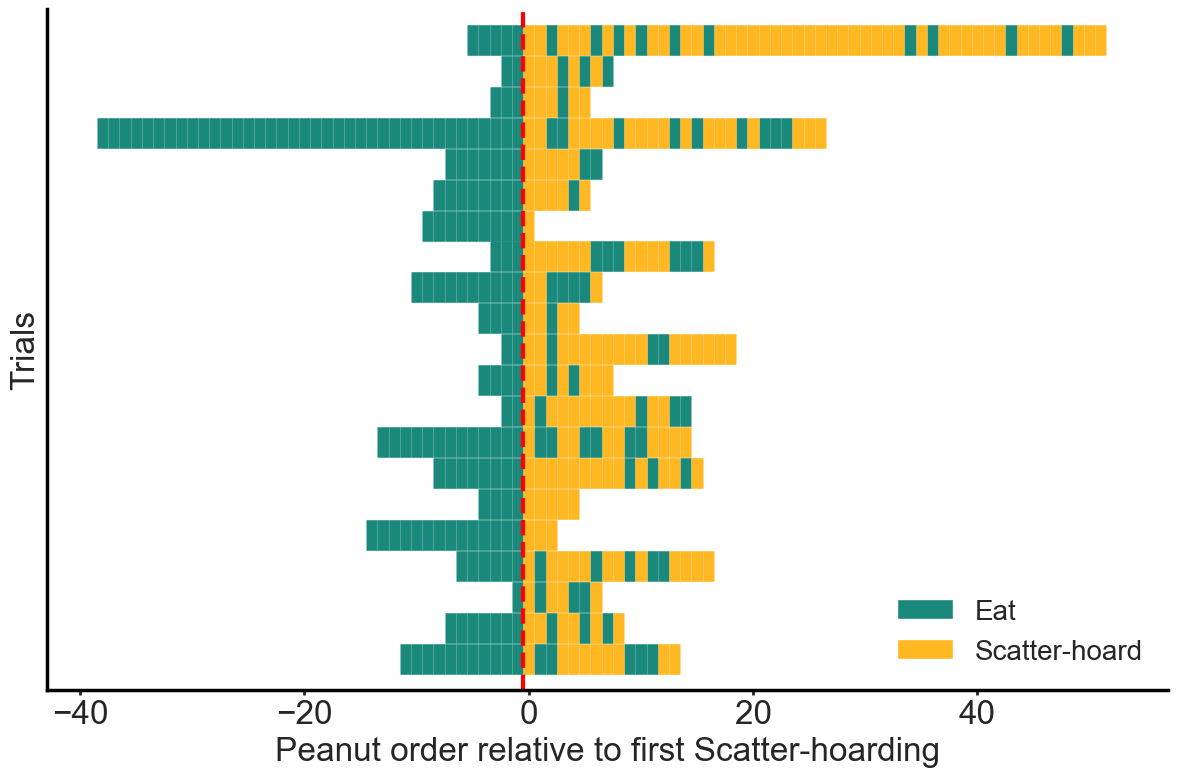

In [291]:
reload(modeling)
reload(pooled_model_pipeline_tau_global)

param_simulated = 'r'

metric = 'simulaton_' + param_simulated

hmm_play = pooled_model_pipeline_tau_global.hmm_emit(structured_data, hmm_variations[param_simulated], force_emit = True)
aligned_matrix, zero_idx = modeling.align_trials1(hmm_play[0])
modeling.plot_aligned_bars(aligned_matrix, zero_idx, plot_probability=False, metric = metric)

[7, 2, 4, 13, 10, 12, 1, 3, 5, 1, 4, 8, 5, 12, 8, 3, 1, 11, 6, 8, 10]
[7, 2, 4, 13, 10, 12, 1, 3, 5, 1, 4, 8, 5, 12, 8, 3, 1, 11, 6, 8, 10]
C:\Users\nacholab-adm\Desktop\figures/SH_mode_simulaton_eps.svg


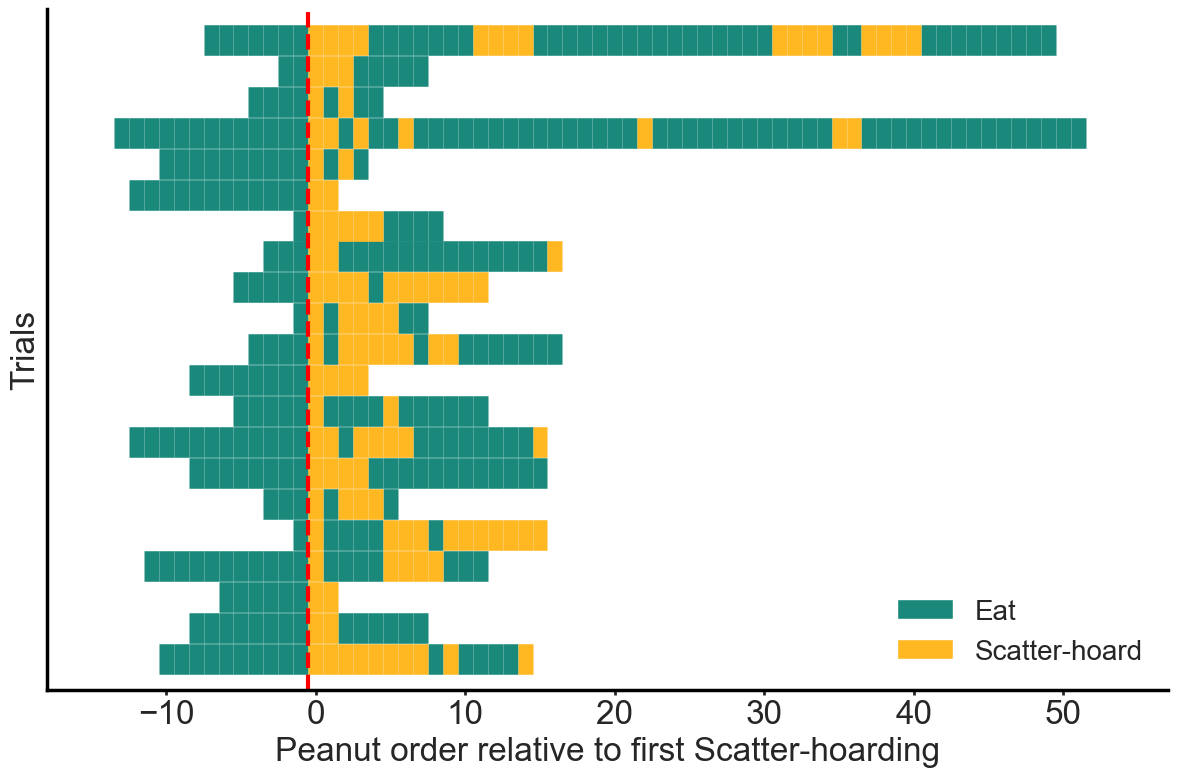

In [292]:
reload(modeling)
reload(pooled_model_pipeline_tau_global)

param_simulated = 'eps'

metric = 'simulaton_' + param_simulated

hmm_play = pooled_model_pipeline_tau_global.hmm_emit(structured_data, hmm_variations[param_simulated], force_emit = True)
aligned_matrix, zero_idx = modeling.align_trials1(hmm_play[0])
modeling.plot_aligned_bars(aligned_matrix, zero_idx, plot_probability=False, metric = metric)

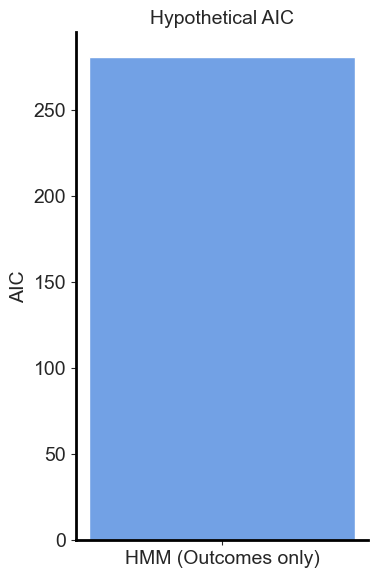

In [297]:
reload(pooled_model_pipeline_tau_global)

bivariate_hmm_fitted = pooled_model_pipeline_tau_global.fit_bivariate_hmm(path_to_shmode)

In [298]:
bivariate_hmm_fitted

{'qy': 1e-06,
 'q_y': 1e-06,
 'qz': 0.047832118207323415,
 'q_z': 0.047832118207323415,
 'ry': 0.895674330206327,
 'r_y': 0.895674330206327,
 'rz': 0.46893157374178207,
 'r_z': 0.46893157374178207,
 'pi': 0.11152037099690947,
 'eps': 1e-06,
 'log_likelihood': -337.85146714941004,
 'hypothetical_aic_y': 281.2808323076951}

In [301]:
from importlib import reload
reload(pooled_model_pipeline_tau_global)

# Run the simulation wrapper using your fitted parameter dictionary and your dataset:
simulated_outputs = pooled_model_pipeline_tau_global.simulate_bivariate_hmm_predictions(bivariate_hmm_fitted, structured_data)

# Access the simulated lists directly from the resulting dictionary:
sim_outcomes = simulated_outputs["HMM_bivariate_y"]
sim_rotations = simulated_outputs["HMM_bivariate_z"]
sim_states = simulated_outputs["HMM_bivariate_s"]

Probability of rotation before 0: 0.0566
Probability of rotation after 0: 0.4890
C:\Users\nacholab-adm\Desktop\figures/SH_mode_rotation.svg


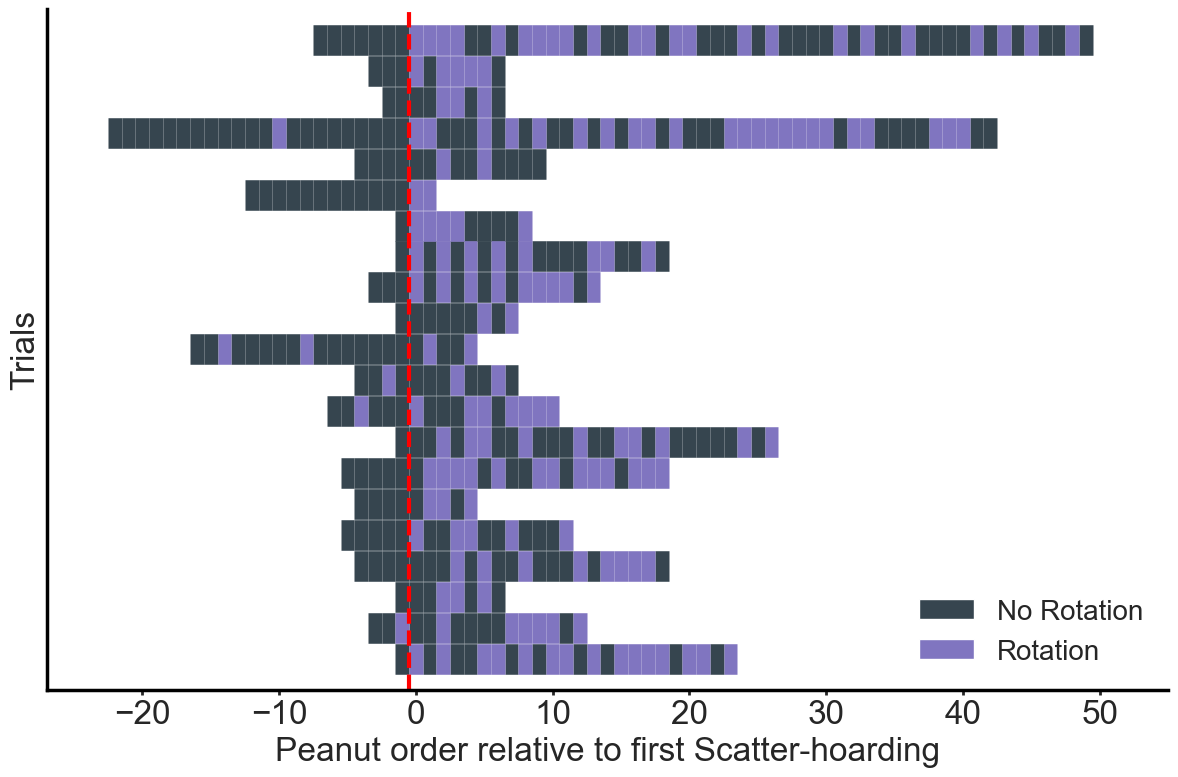

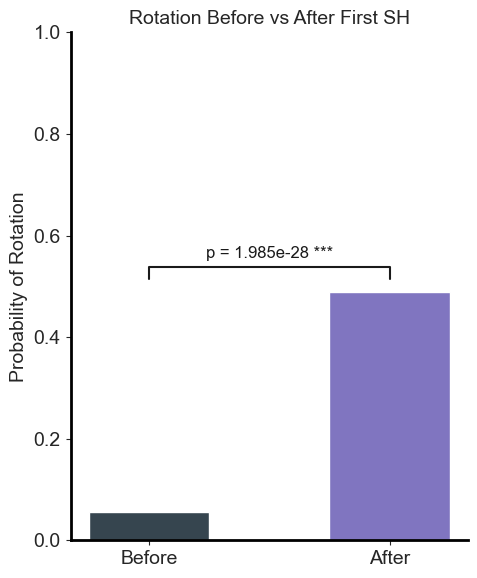

In [302]:
reload(modeling)

metric = 'rotation'

aligned_matrix_rotations, zero_idx_rotations = modeling.align_trials2(sim_outcomes, sim_rotations)
modeling.plot_aligned_bars(aligned_matrix_rotations, zero_idx_rotations, plot_probability=False, rotation = True, metric = metric)

[7, 3, 2, 22, 4, 12, 1, 1, 3, 1, 16, 4, 6, 1, 5, 4, 5, 4, 1, 3, 1]
[7, 3, 2, 22, 4, 12, 1, 1, 3, 1, 16, 4, 6, 1, 5, 4, 5, 4, 1, 3, 1]
C:\Users\nacholab-adm\Desktop\figures/SH_mode_HMM_fited.svg


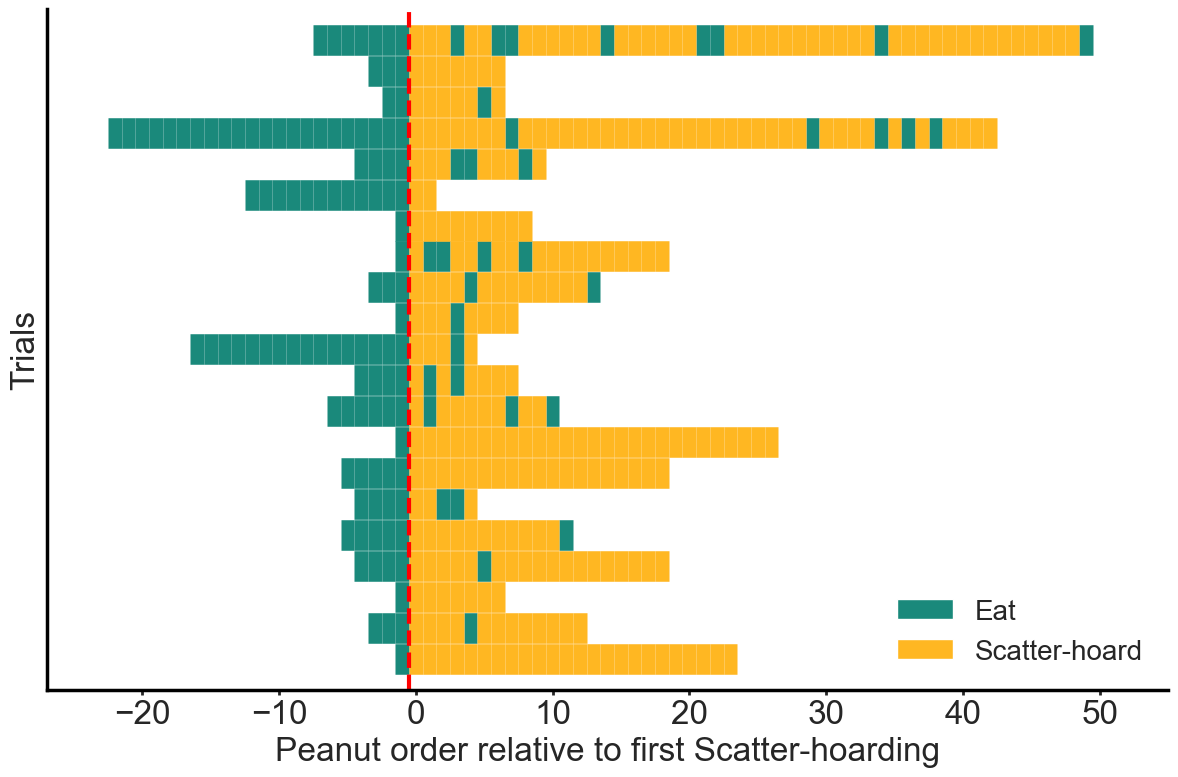

Probability of rotation given Eat (after 1st SH): 0.4571
Probability of rotation given Scatter-hoard (after 1st SH): 0.4930


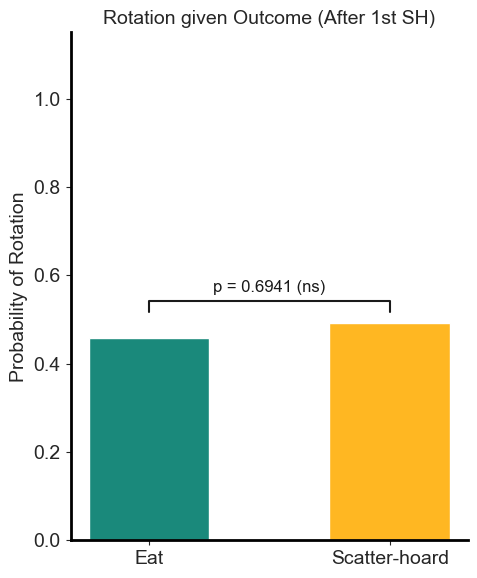

In [307]:
reload(modeling)

# Assuming you have generated both aligned matrices
aligned_matrix_outcomes, zero_idx = modeling.align_trials1(sim_outcomes)
aligned_matrix_rotations, _ = modeling.align_trials2(sim_outcomes, sim_rotations)

# Pass both matrices to plot_aligned_bars
modeling.plot_aligned_bars(
    aligned_matrix=aligned_matrix_outcomes, 
    zero_idx=zero_idx, 
    plot_probability=False, 
    metric='HMM_fited',
    rotation_matrix=aligned_matrix_rotations  # New parameter
)

[7, 3, 2, 22, 4, 12, 1, 1, 3, 1, 16, 4, 6, 1, 5, 4, 5, 4, 1, 3, 1]
[7, 3, 2, 22, 4, 12, 1, 1, 3, 1, 16, 4, 6, 1, 5, 4, 5, 4, 1, 3, 1]
C:\Users\nacholab-adm\Desktop\figures/SH_mode_HMM_fited.svg


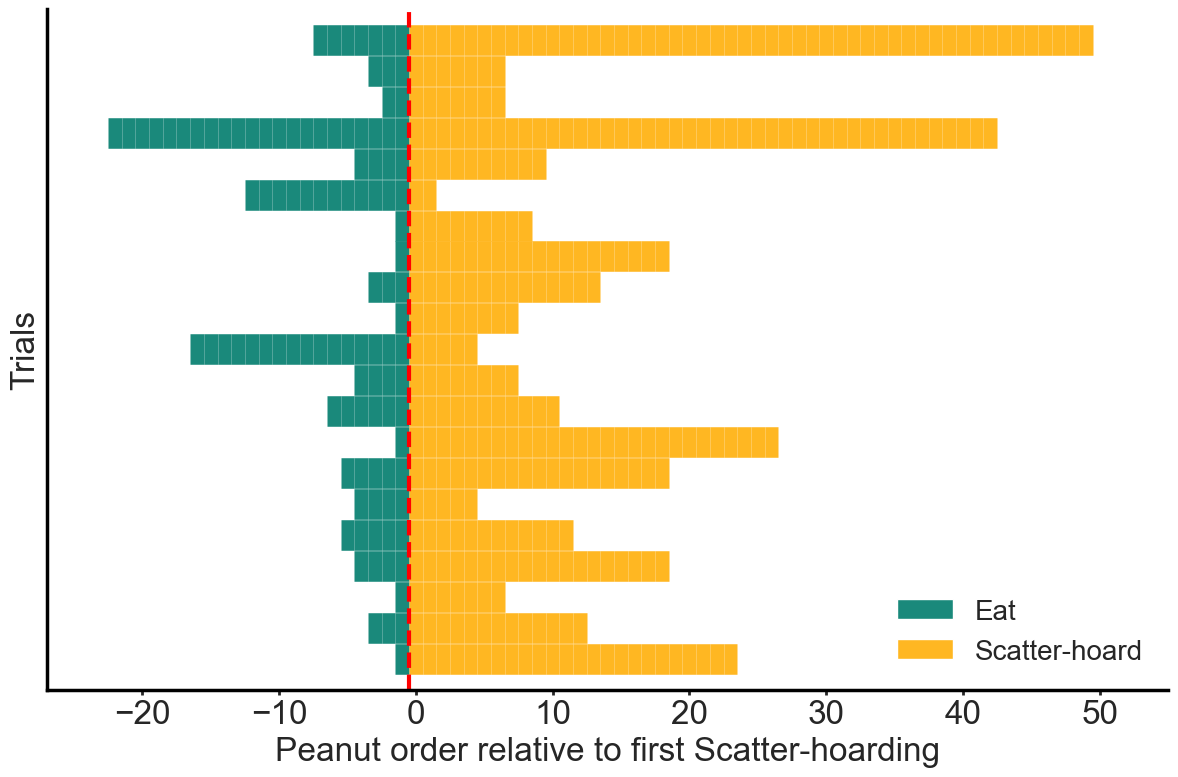

In [305]:
reload(modeling)

model = 'HMM_bivariate_s'
aligned_matrix, zero_idx = modeling.align_trials1(sim_states)
modeling.plot_aligned_bars(aligned_matrix, zero_idx, plot_probability=False, metric = 'HMM_fited')

Computing Bivariate HMM AIC landscape slices...
Minimal AIC in computed landscape: 687.7023


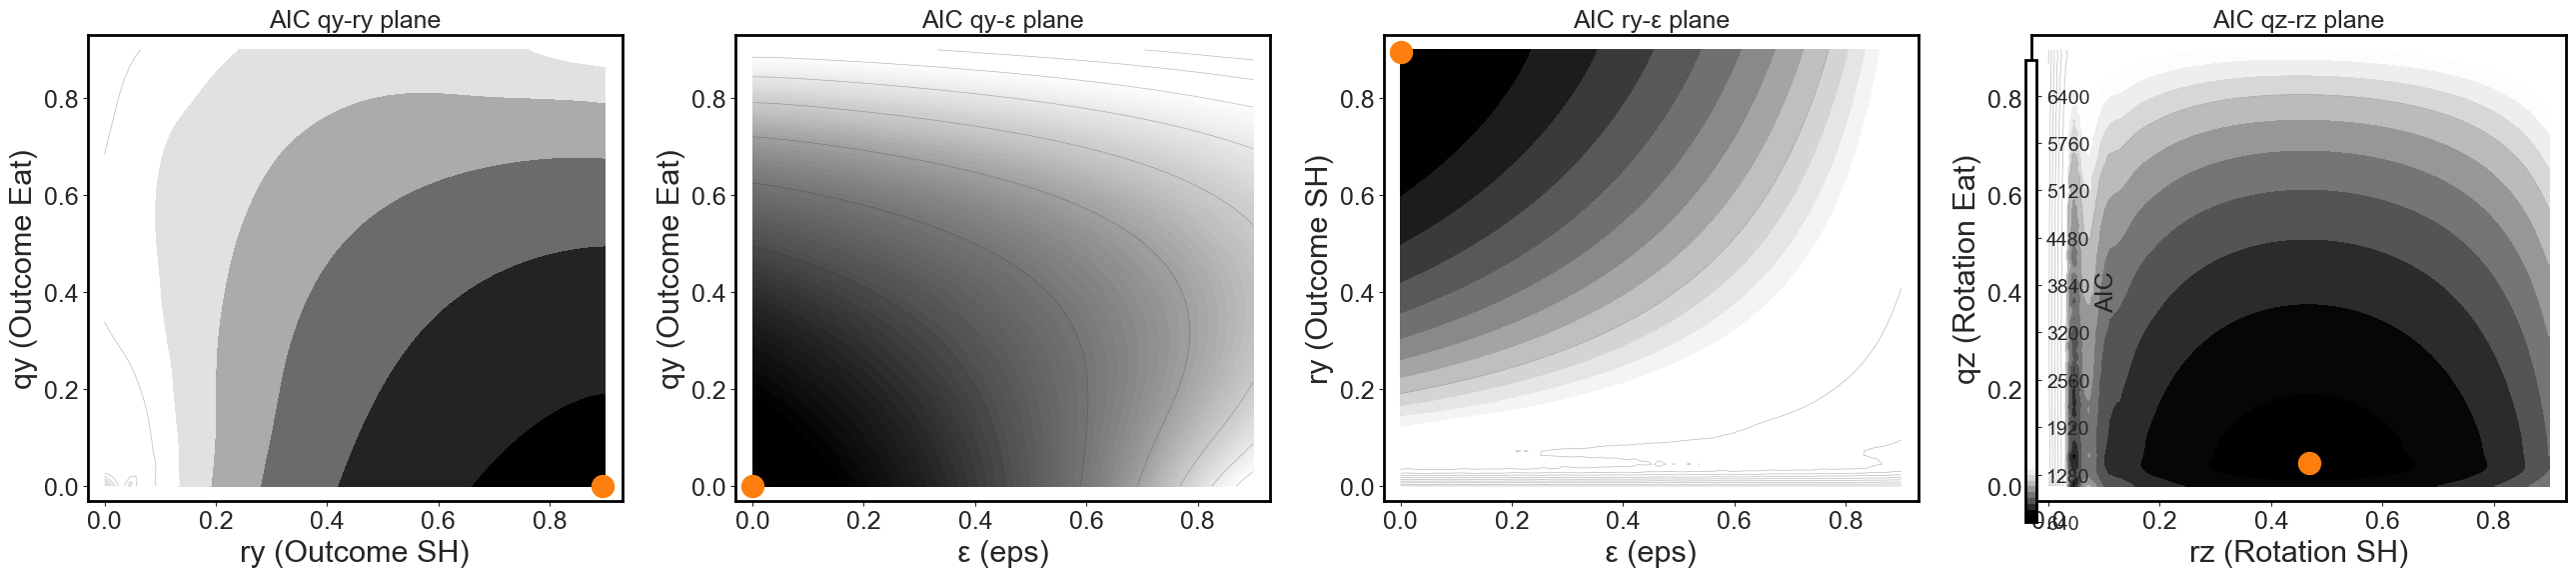

In [304]:
reload(pooled_model_pipeline_tau_global)

pooled_model_pipeline_tau_global.plot_bivariate_hmm_aic_landscape(path_to_shmode,
    structured_data, 
    fitted_params=bivariate_hmm_fitted,
    save_path=None
)

## Target search on ovoid

Running ovoid baseline simulations with effective_radius = 0.5 + 0.3...
Finished 100 batches of 1000 sims in 17.8 seconds
Stats (Markov Final vs Pooled): p=8.0009e-30
Stats (Pooled vs Inversed): p=1.5295e-32
Stats (Markov Final vs Inversed): p=2.5205e-34


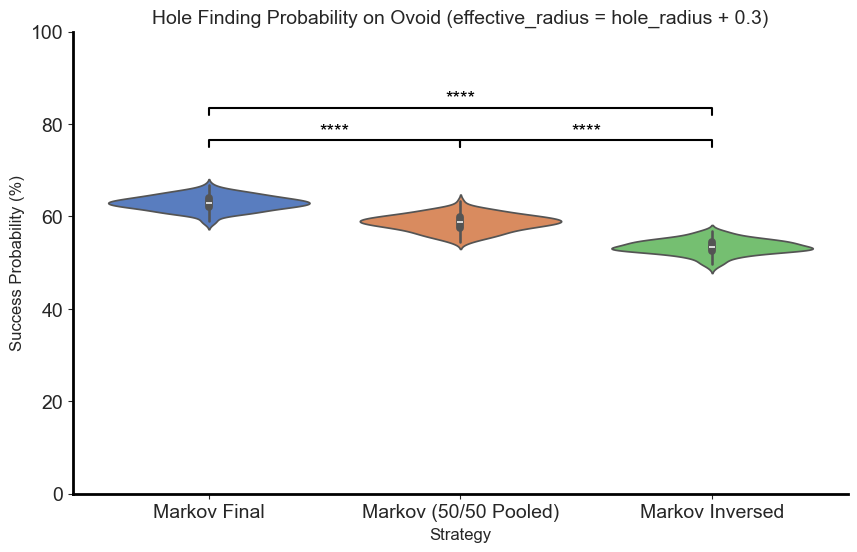

Plot saved to None


In [316]:
reload(from_antigravity_peanuts)

# Run the batched violin/bar plot simulation specifically for the 1cm hole on the Ovoid
from_antigravity_peanuts.plot_multi_strategy_1cm_hole_batched_ovoid(
    output_file=None,
    sims_per_batch=1000,
    num_batches=100,
    target_std=0.3,
    n_steps=5,
    plot_type='violin' # Switch this to 'bar' if you prefer a barplot instead!
)

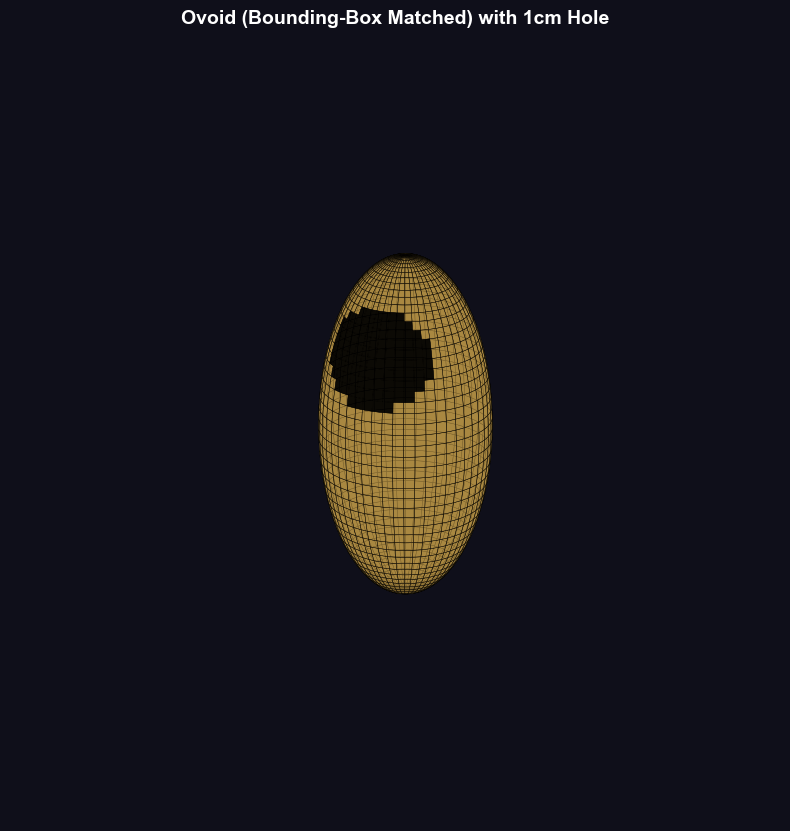

In [326]:
reload(from_antigravity_peanuts)

from_antigravity_peanuts.plot_static_3d_ovoid_hole_bounding_matched(
    output_svg=None
)

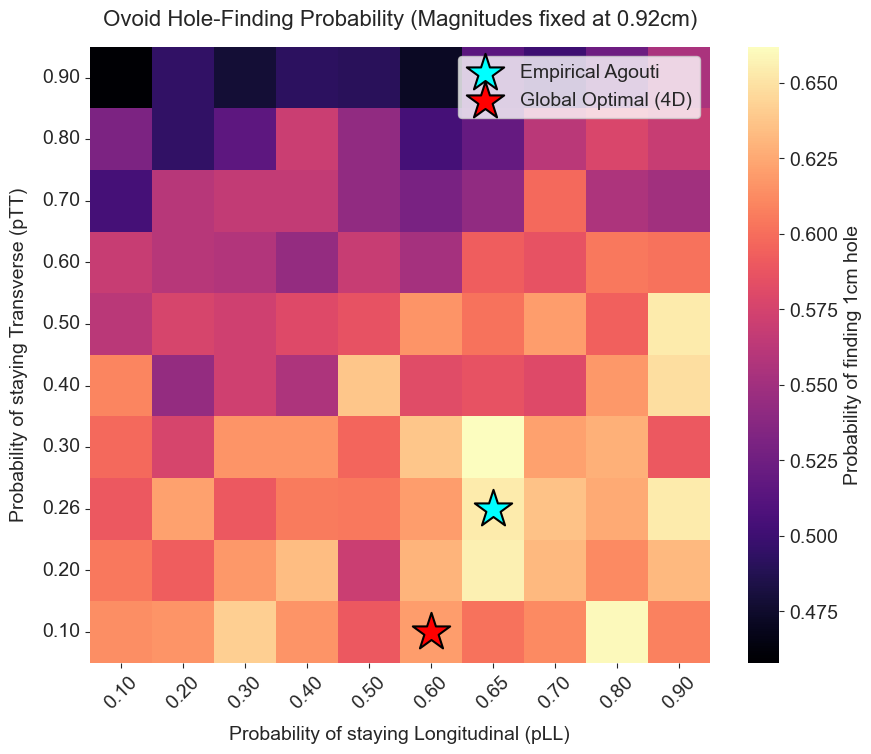

In [321]:
import importlib
import from_antigravity_peanuts
importlib.reload(from_antigravity_peanuts)

from_antigravity_peanuts.plot_2d_transition_sweep_stars(ovoid_sweep_data_path, None)

Running inverted ovoid baseline simulations with effective_radius = 0.5 + 0.3...
Finished 100 batches of 1000 sims in 20.9 seconds
Stats (Markov Final vs Pooled): p=1.0048e-26
Stats (Pooled vs Inversed): p=3.8947e-24
Stats (Markov Final vs Inversed): p=4.0809e-34


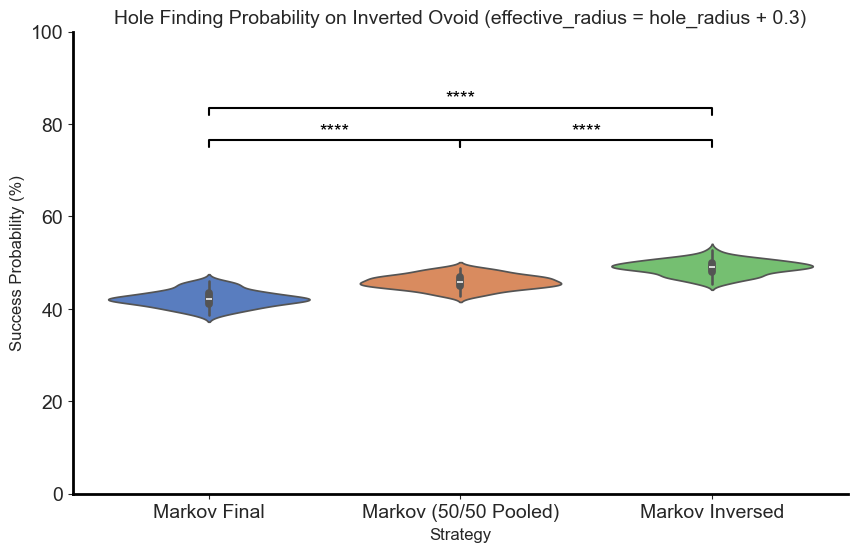

In [325]:
reload(from_antigravity_peanuts)

from_antigravity_peanuts.plot_multi_strategy_1cm_hole_batched_inverted_ovoid(
    output_file=None,
    sims_per_batch=1000,
    num_batches=100,
    target_std=0.3,
    n_steps=5,
    plot_type='violin'
)

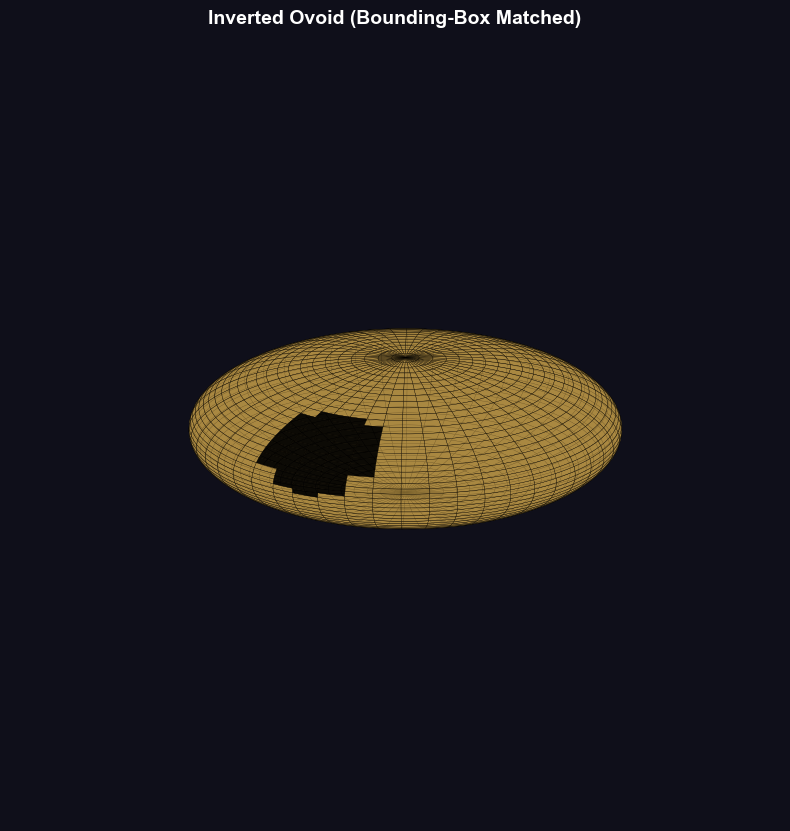

In [327]:
reload(from_antigravity_peanuts)

# Run the function to generate the SVG and display the plot
from_antigravity_peanuts.plot_static_3d_inverted_ovoid_hole_bounding_matched(
    output_svg=None
)

## Optimal walks

Processed multi-strategy sim for hole_2_stick (K_animal = 26)
Processed multi-strategy sim for hole_3_good_bis (K_animal = 18)
Processed multi-strategy sim for hole_3_good (K_animal = 14)
Processed multi-strategy sim for hole_DSCN0436 (K_animal = 6)
Processed multi-strategy sim for hole_DSCN0527 (K_animal = 8)
Processed multi-strategy sim for hole_DSCN0536 (K_animal = 8)
Processed multi-strategy sim for hole_DSCN0552 (K_animal = 6)
Processed multi-strategy sim for hole_DSCN0598 (K_animal = 6)
Processed multi-strategy sim for hole_DSCN0599 (K_animal = 6)
Processed multi-strategy sim for hole_DSCN0600 (K_animal = 12)
Processed multi-strategy sim for hole_DSCN0815 (K_animal = 8)
Processed multi-strategy sim for hole_DSCN0817 (K_animal = 6)
Processed multi-strategy sim for hole_DSCN0826_bis (K_animal = 8)
Processed multi-strategy sim for hole_DSCN0826 (K_animal = 10)
Processed multi-strategy sim for hole_DSCN0829 (K_animal = 12)
Processed multi-strategy sim for hole_DSCN0834_bis (K_animal 

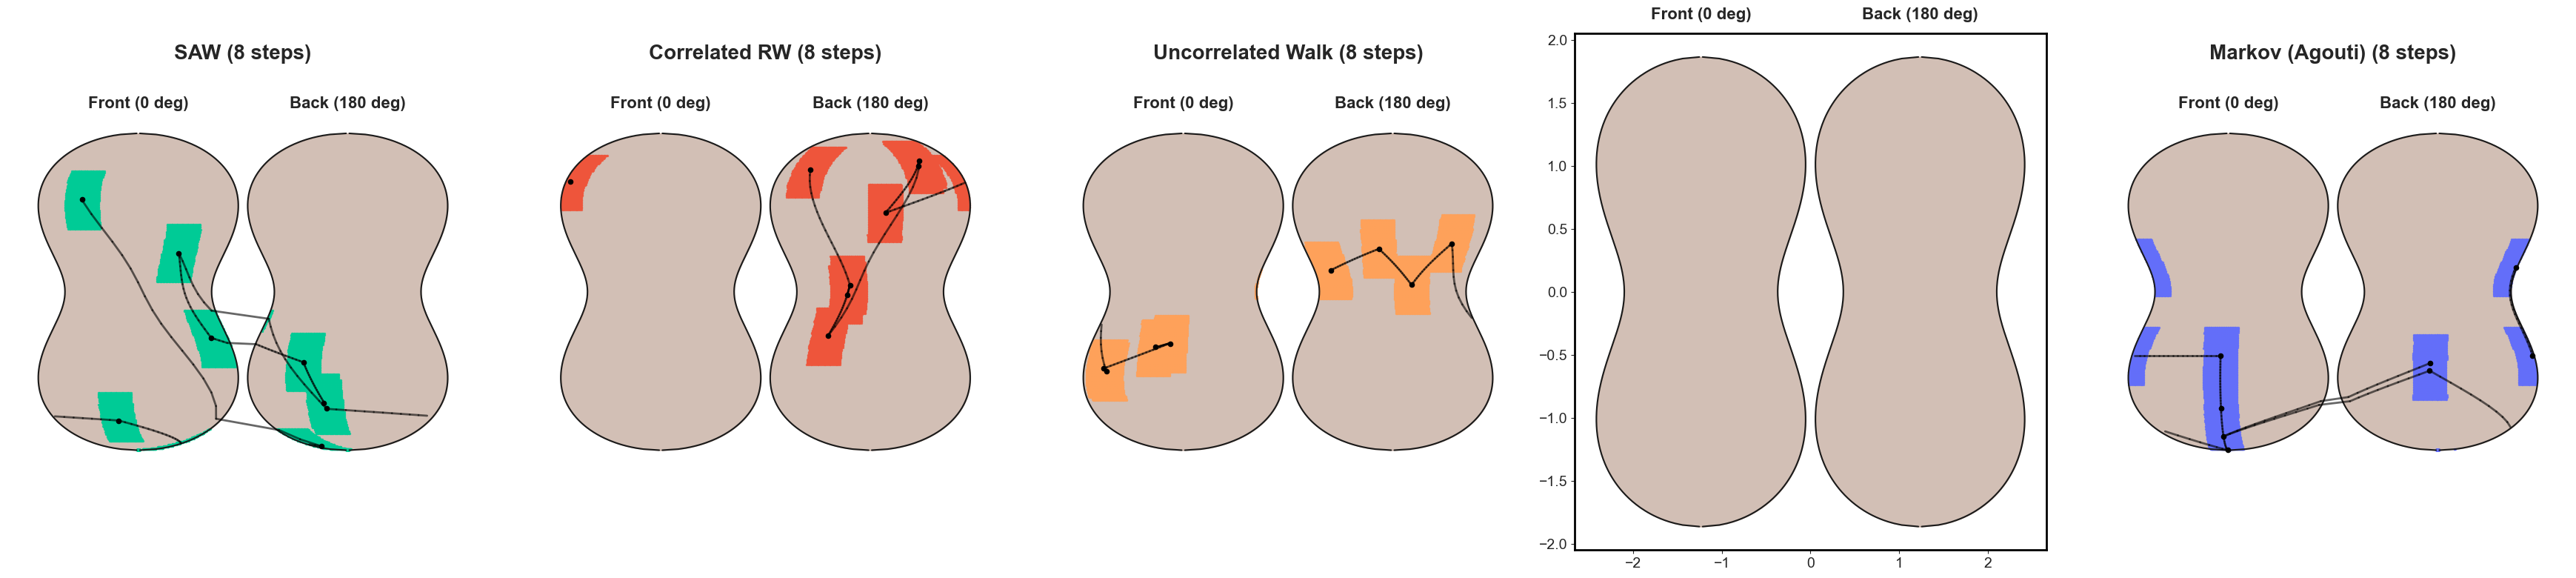

In [337]:
reload(from_antigravity_peanuts)

df_sim = from_antigravity_peanuts.run_advanced_trajectory_tracking(
    sites_dir= sites_holes_path,
    num_simulations=500,      
    record_max_steps=20,      
    randomize_starts=True
)

from_antigravity_peanuts.plot_patchiness_comparison_two_faces(
    df_sim, 
    output_file=None, 
    max_steps=8
)

Auto-switched to front sites: hole_3_good_front_sites.json
\n--- Real Peanut (7 steps) ---
Total Peanut Surface Area: 16.44 cm^2
Total Geodesic Distance Traveled: 4.14 cm
Area Covered: 1.76 cm^2 (10.7%)
Area Overlapped: 0.19 cm^2 (1.2%)
Saved patchiness visualization to C:\Users\nacholab-adm\Desktop\figures\patchiness_TwoFaces_RealPeanut.svg


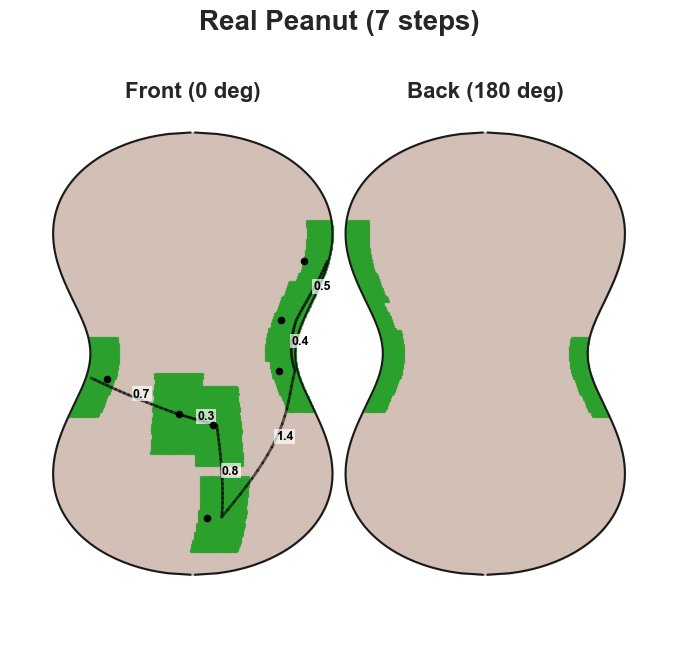

In [334]:
reload(from_antigravity_peanuts)

from_antigravity_peanuts.plot_patchiness_real_peanut_two_faces(
    json_file=r"data_paper/saved_sites/hole\hole_3_good_sites.json",
    output_file=r"figures/patchiness_TwoFaces_RealPeanut.svg",
    max_steps=8
)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


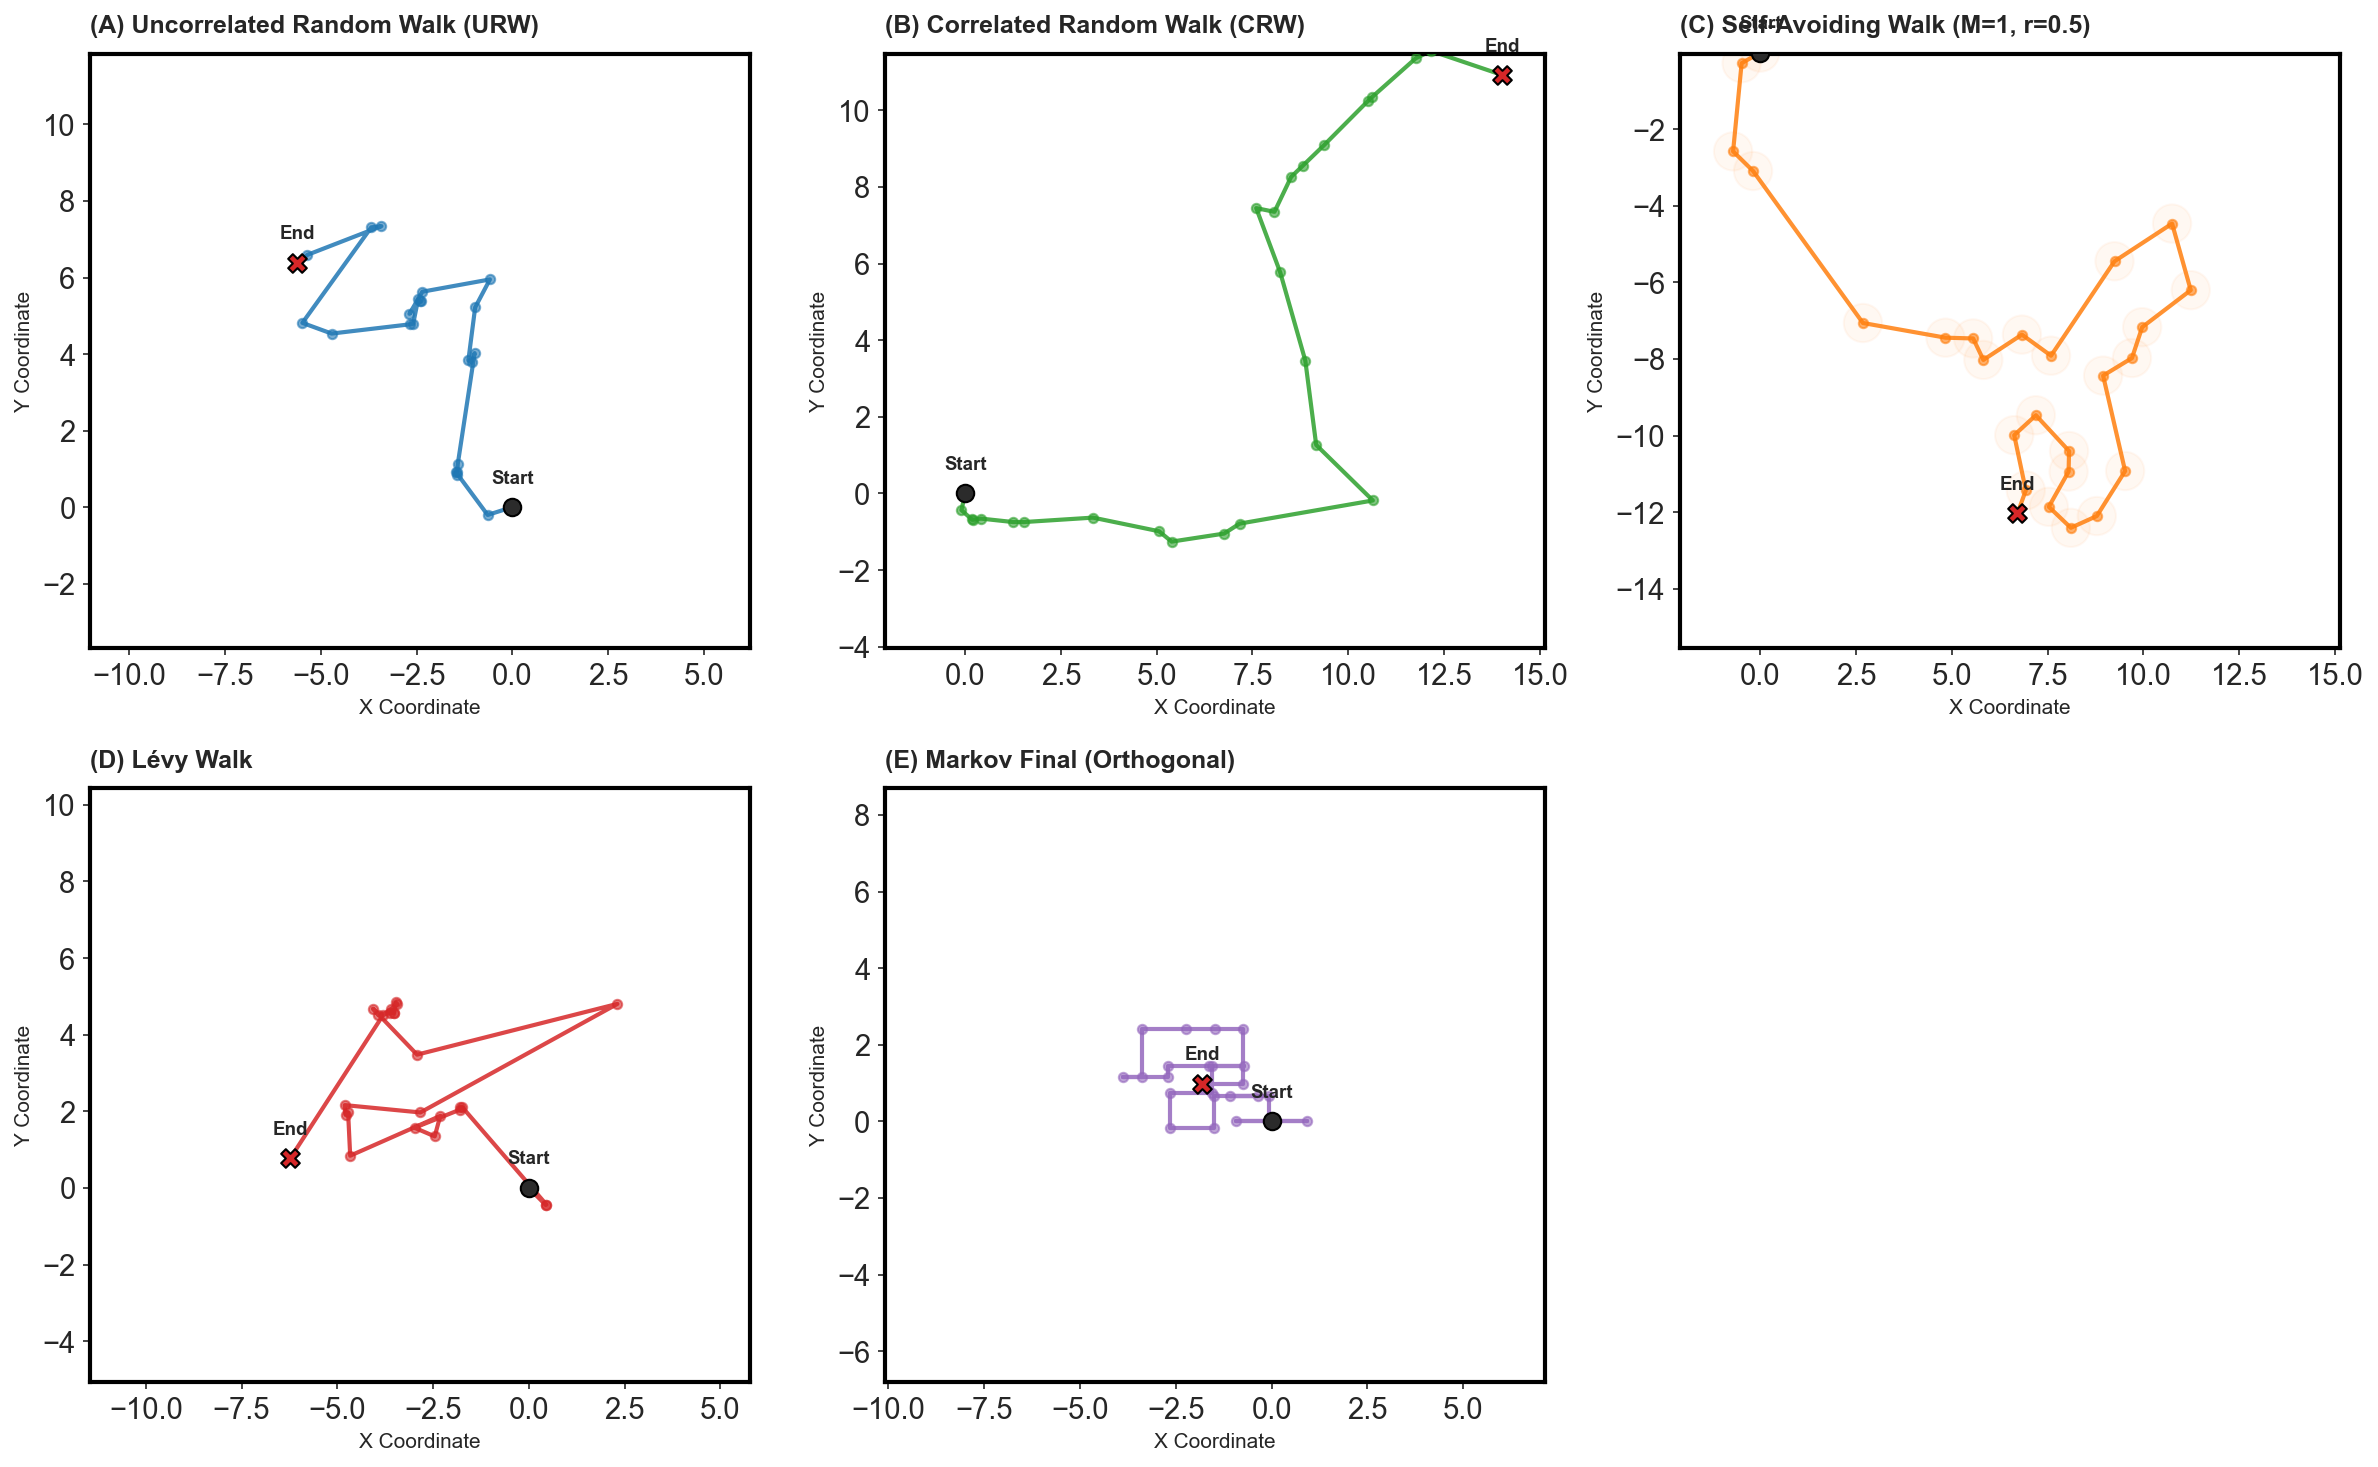

In [335]:
reload(from_antigravity_peanuts)

from_antigravity_peanuts.plot_scientific_walks_with_markov(steps=25, saw_radius=0.5, seed=rd.randint(1, 1000),
                                                          output_file=None)

Sweeping for 8 clamps (n_steps=4). Num sims: 10000
D=0.3cm -> Markov Final: 4.5%, Correlated Random Walk: 3.5%, Self-Avoiding Walk (M=2): 3.8%, Uncorrelated Walk: 3.4%, Lévy Walk: 3.6%
D=0.5cm -> Markov Final: 11.6%, Correlated Random Walk: 8.6%, Self-Avoiding Walk (M=2): 9.4%, Uncorrelated Walk: 9.2%, Lévy Walk: 10.0%
D=0.7cm -> Markov Final: 22.7%, Correlated Random Walk: 16.0%, Self-Avoiding Walk (M=2): 19.0%, Uncorrelated Walk: 17.3%, Lévy Walk: 19.4%
D=1.0cm -> Markov Final: 41.8%, Correlated Random Walk: 29.1%, Self-Avoiding Walk (M=2): 35.6%, Uncorrelated Walk: 31.2%, Lévy Walk: 35.2%
D=1.5cm -> Markov Final: 72.5%, Correlated Random Walk: 54.6%, Self-Avoiding Walk (M=2): 69.3%, Uncorrelated Walk: 56.7%, Lévy Walk: 57.9%
D=2.0cm -> Markov Final: 89.5%, Correlated Random Walk: 73.2%, Self-Avoiding Walk (M=2): 90.0%, Uncorrelated Walk: 74.2%, Lévy Walk: 74.5%


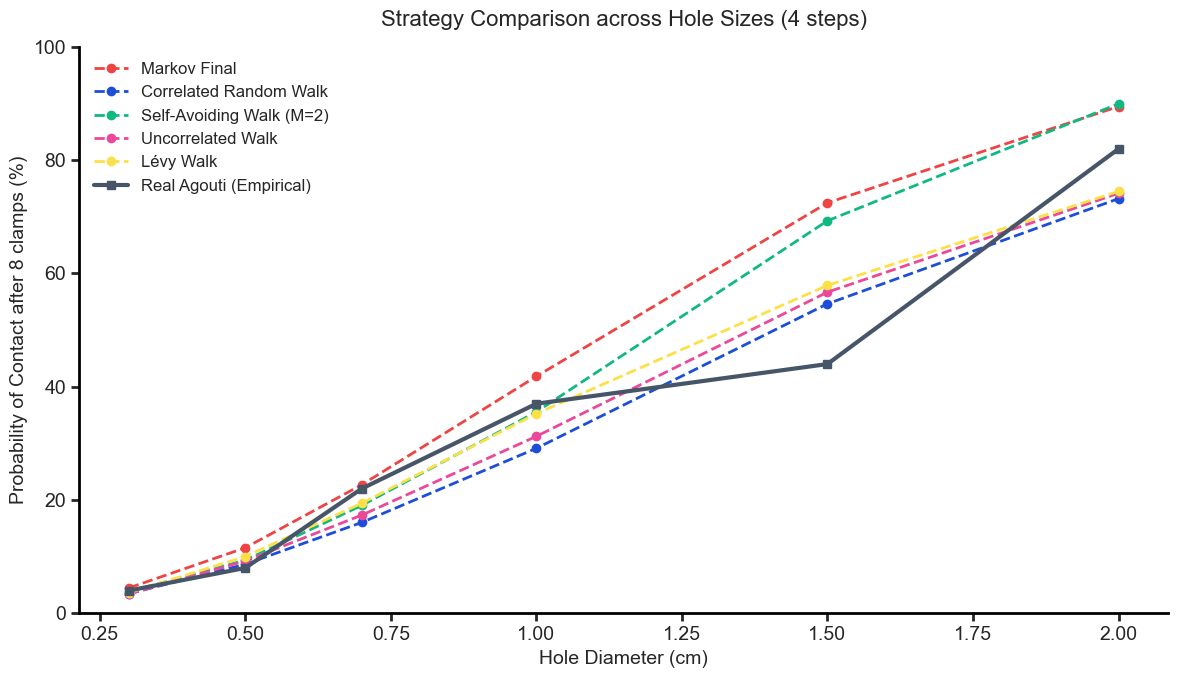

In [336]:
reload(from_antigravity_peanuts)

from_antigravity_peanuts.plot_multi_strategy_hole_size_sweep(
    output_file=None,
    num_simulations=10000,
    target_std=0.3,
    n_steps=4
)

## DDM

In [343]:
data = load_data()
traces = load_or_build_traces(data["sizes"])

Loading walker traces from peanut_traces_N500_B100.npz


In [344]:
reload(ddm_m5)

list_fits = []
for k in range(50):
    fit_m5 = ddm_m5.fit_model("M5", data, traces)
    list_fits.append(fit_m5)

M5 (walker + eps): drift=+0.1060  B_cache=+0.3050  B_eat=+0.5316  J=+0.5162  eps=+0.0313  loss=5.397
M5 (walker + eps): drift=+0.1034  B_cache=+0.2993  B_eat=+0.5377  J=+0.5228  eps=+0.0313  loss=5.693
M5 (walker + eps): drift=+0.1067  B_cache=+0.3072  B_eat=+0.5275  J=+0.5280  eps=+0.0308  loss=5.350
M5 (walker + eps): drift=+0.1075  B_cache=+0.3167  B_eat=+0.5266  J=+0.5078  eps=+0.0309  loss=5.795
M5 (walker + eps): drift=+0.1049  B_cache=+0.3048  B_eat=+0.5251  J=+0.5135  eps=+0.0308  loss=5.469
M5 (walker + eps): drift=+0.1025  B_cache=+0.3083  B_eat=+0.5298  J=+0.5377  eps=+0.0297  loss=5.533
M5 (walker + eps): drift=+0.1030  B_cache=+0.3148  B_eat=+0.5342  J=+0.5342  eps=+0.0299  loss=5.240
M5 (walker + eps): drift=+0.1021  B_cache=+0.3008  B_eat=+0.5369  J=+0.5338  eps=+0.0307  loss=5.434
M5 (walker + eps): drift=+0.1036  B_cache=+0.3114  B_eat=+0.5268  J=+0.5189  eps=+0.0320  loss=5.750
M5 (walker + eps): drift=+0.1058  B_cache=+0.3092  B_eat=+0.5427  J=+0.5186  eps=+0.0304  l

In [346]:
dict_simulations_params = {
    param: [sim['params_dict'][param] for sim in list_fits]
    for param in ['drift', 'B_cache', 'B_eat', 'J', 'eps']
}
{param: [np.mean(val), np.std(val)] for param, val in dict_simulations_params.items()}

{'drift': [np.float64(0.10433521283087226), np.float64(0.0017295618389229512)],
 'B_cache': [np.float64(0.30667782969932844),
  np.float64(0.005086951008145953)],
 'B_eat': [np.float64(0.5313913305066328), np.float64(0.009189767204212365)],
 'J': [np.float64(0.5245716838676299), np.float64(0.011361298274680577)],
 'eps': [np.float64(0.030865427812918136), np.float64(0.0006820611329818388)]}

In [348]:
# Evaluate models (M4 & M5) using the unified eval_model wrapper
pred_m5 = ddm_m5.eval_model("M5", fit_m5["params"], traces, data["sizes"])
# Each returns {"pc": {size: P(cache)}, "ns": {size: array of clamp counts}}

# Build/Load random traces and evaluate the M5 model on them as well
random_traces = ddm_m5.load_or_build_random_traces(data["sizes"], sampling_mode="first_z")
pred_random = ddm_m5.eval_model("M5", fit_m5["params"], random_traces, data["sizes"])

Loading random traces (first_z) from peanut_random_traces_first_z_N500_B100.npz


In [349]:
metrics = ddm_m5.summarize_models({
    "M5 walker + eps": (pred_m5, 5),
}, data)


model                    k  cache-SSE       logL        AIC
  M5 walker + eps        5      3.252    -219.81     449.62


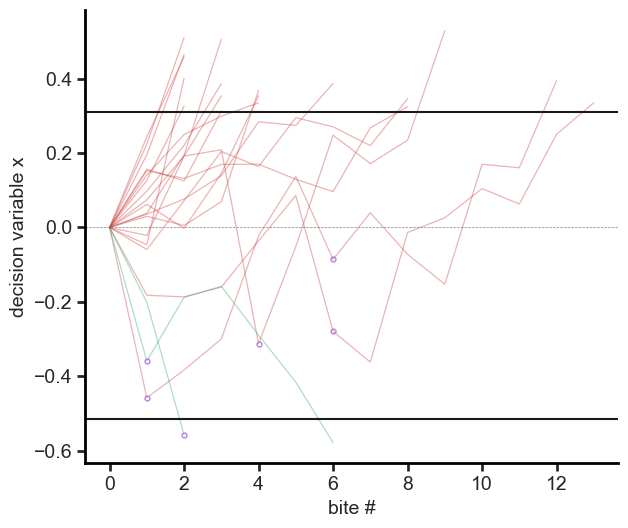

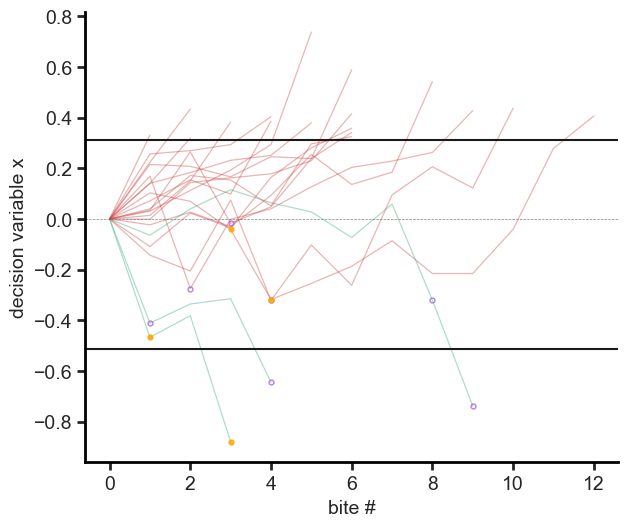

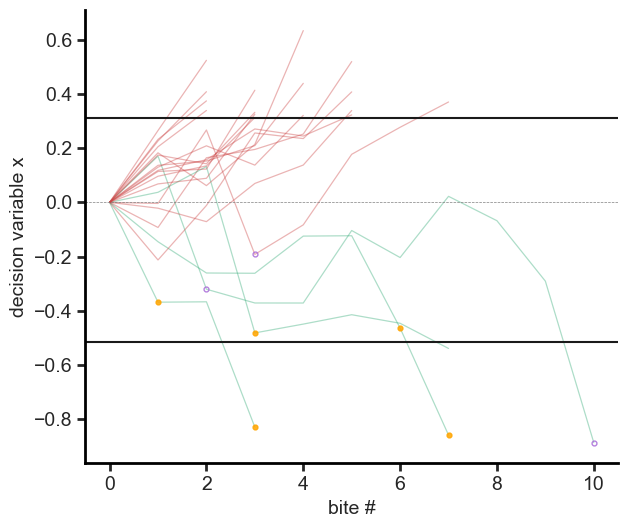

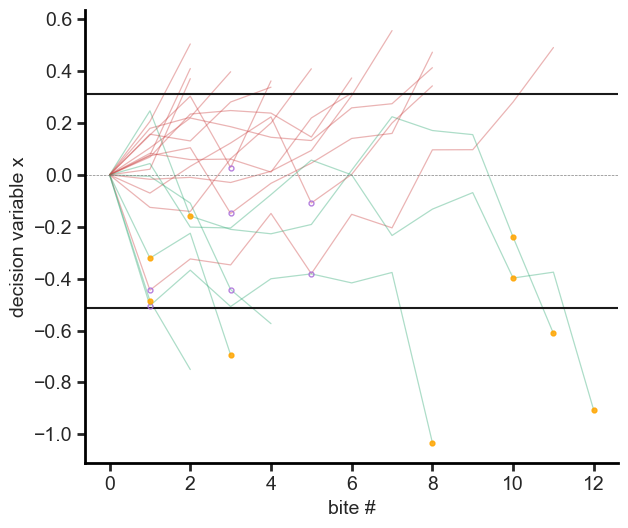

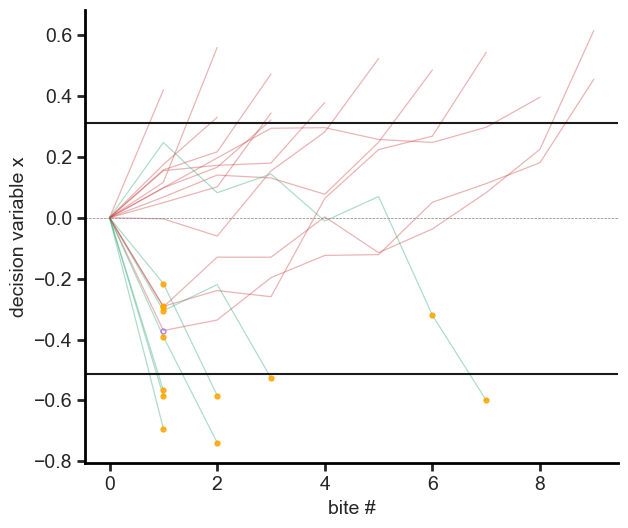

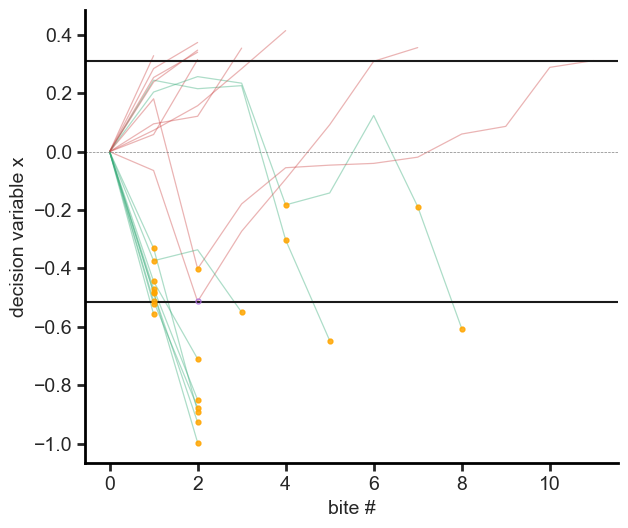

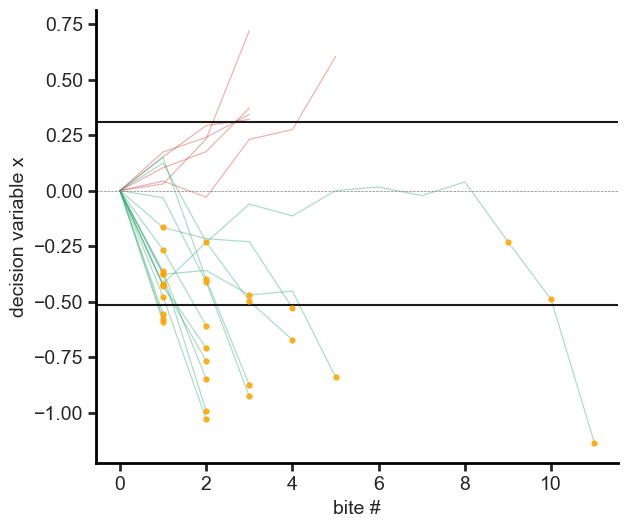

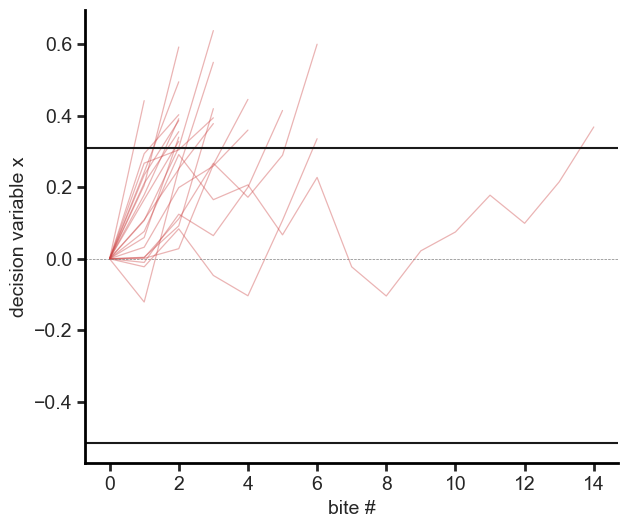

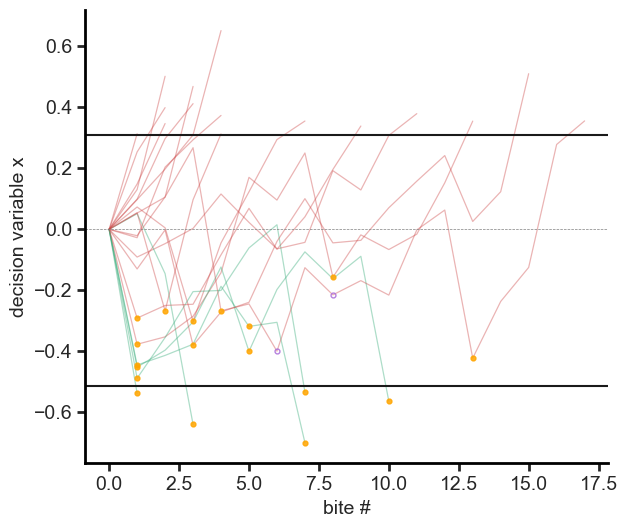

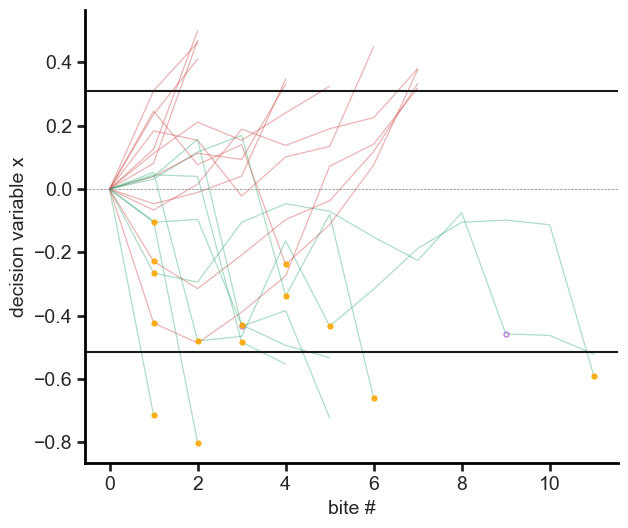

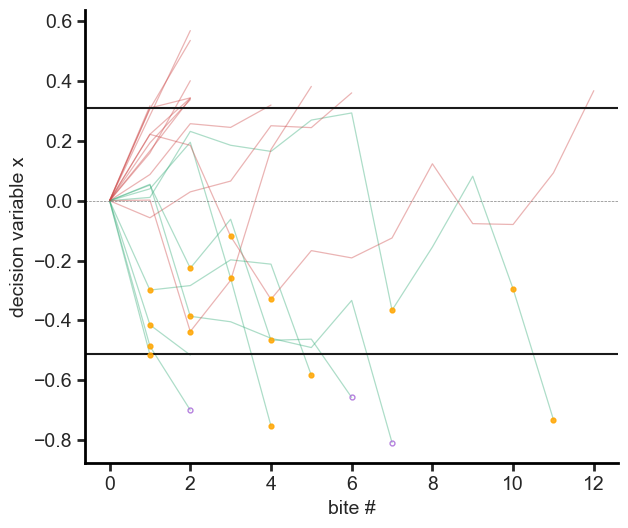

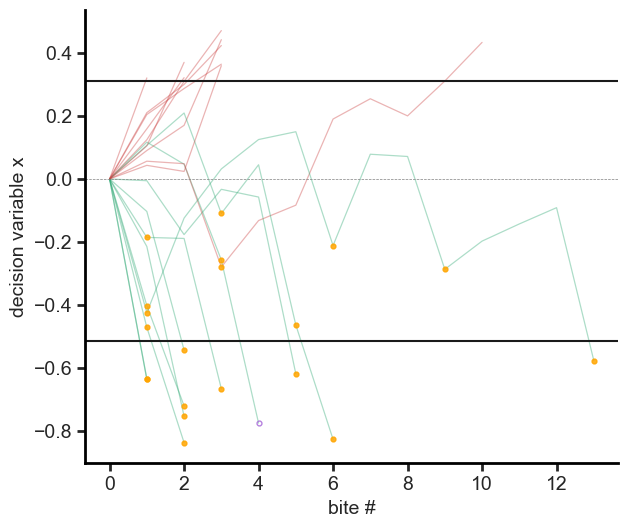

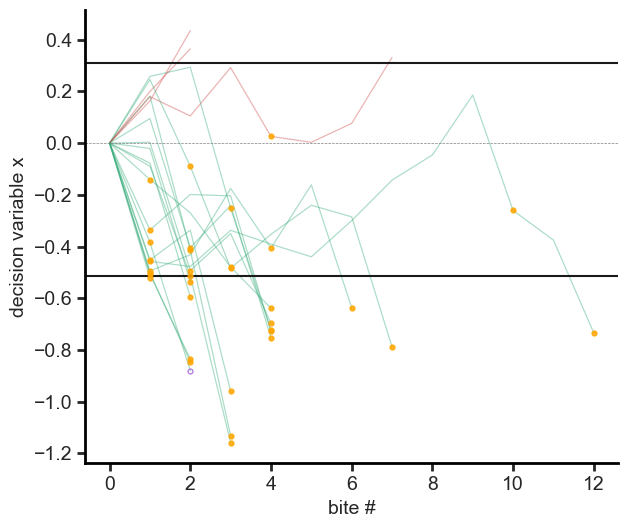

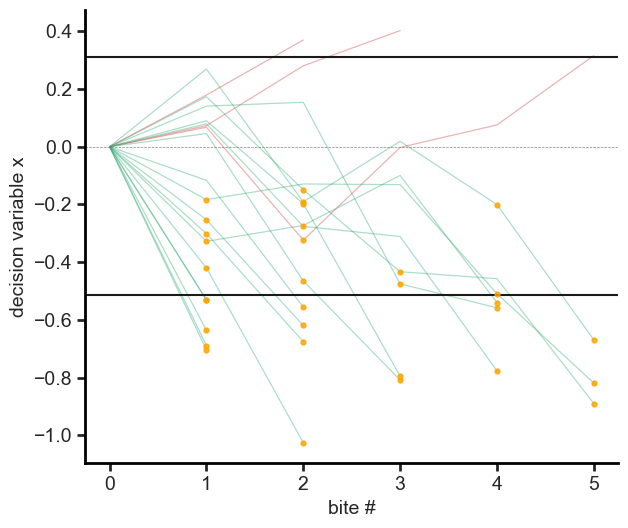

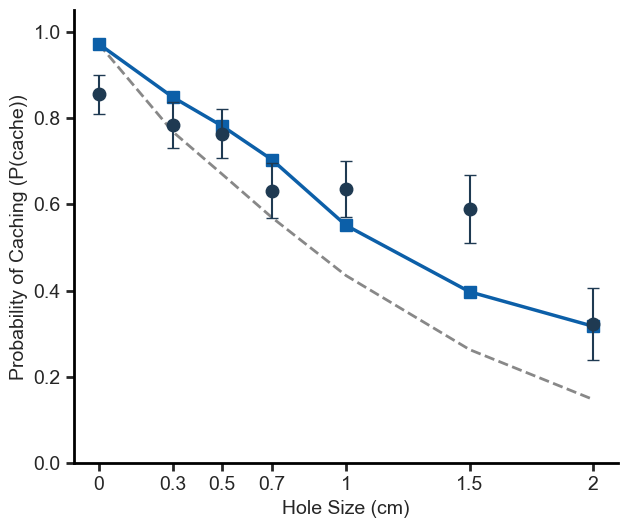

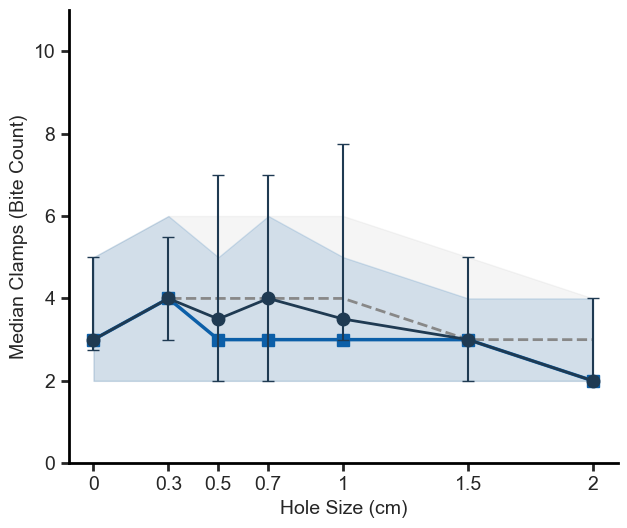

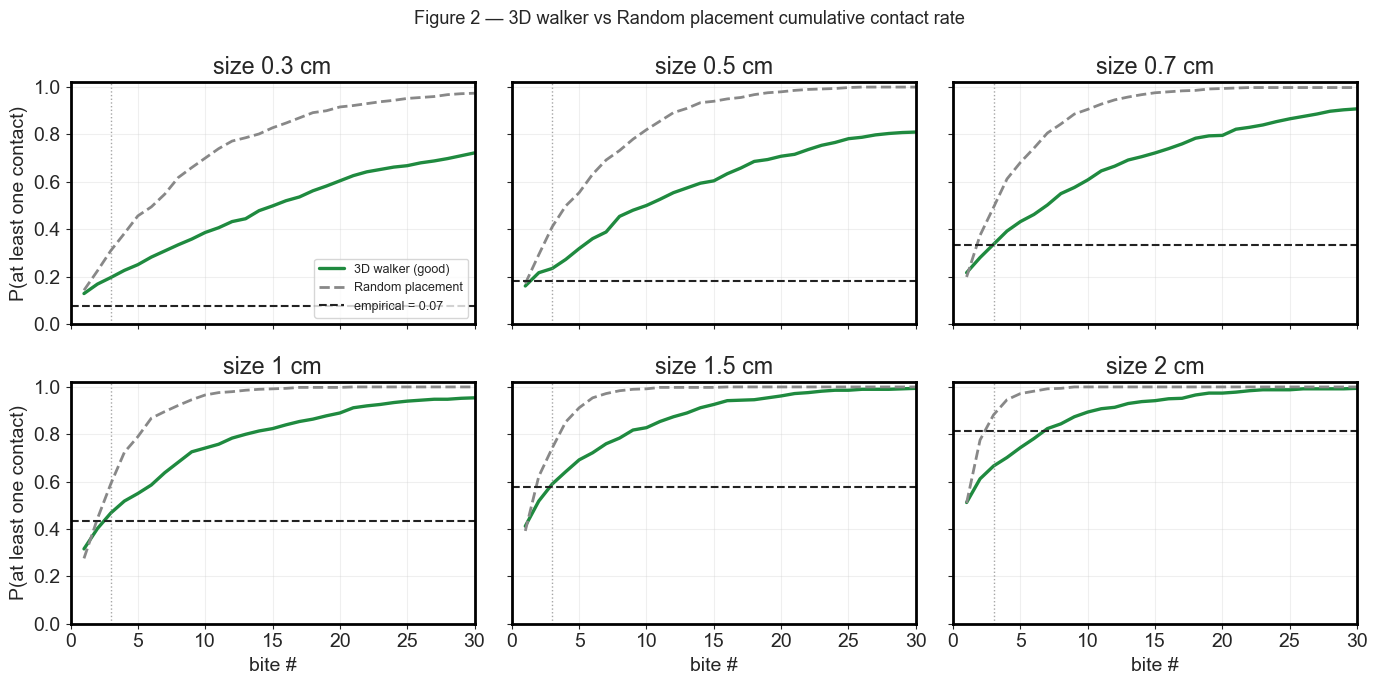

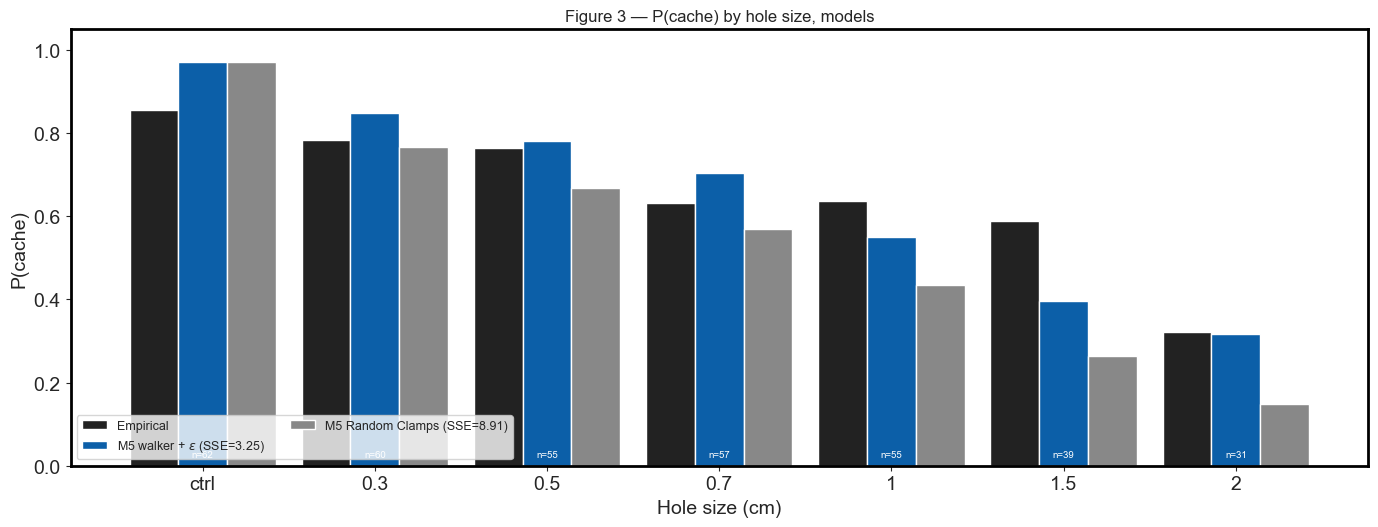

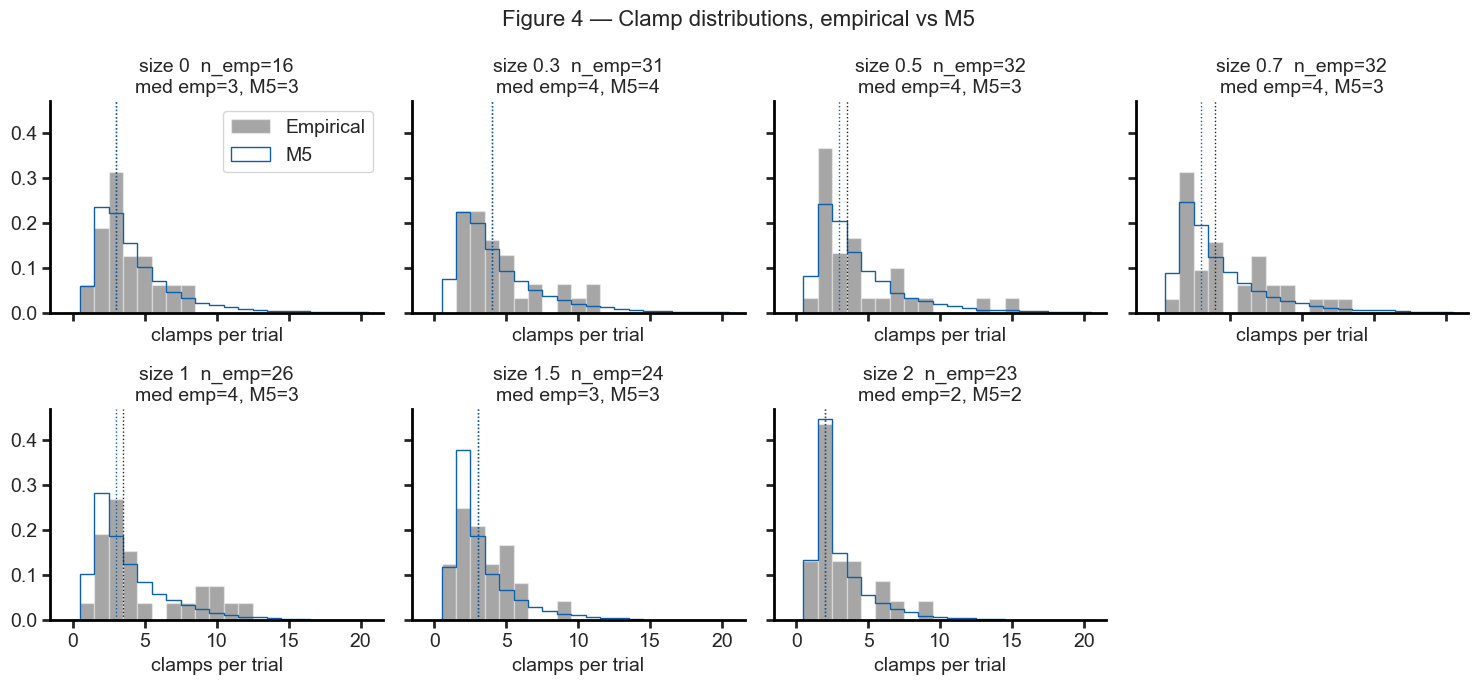

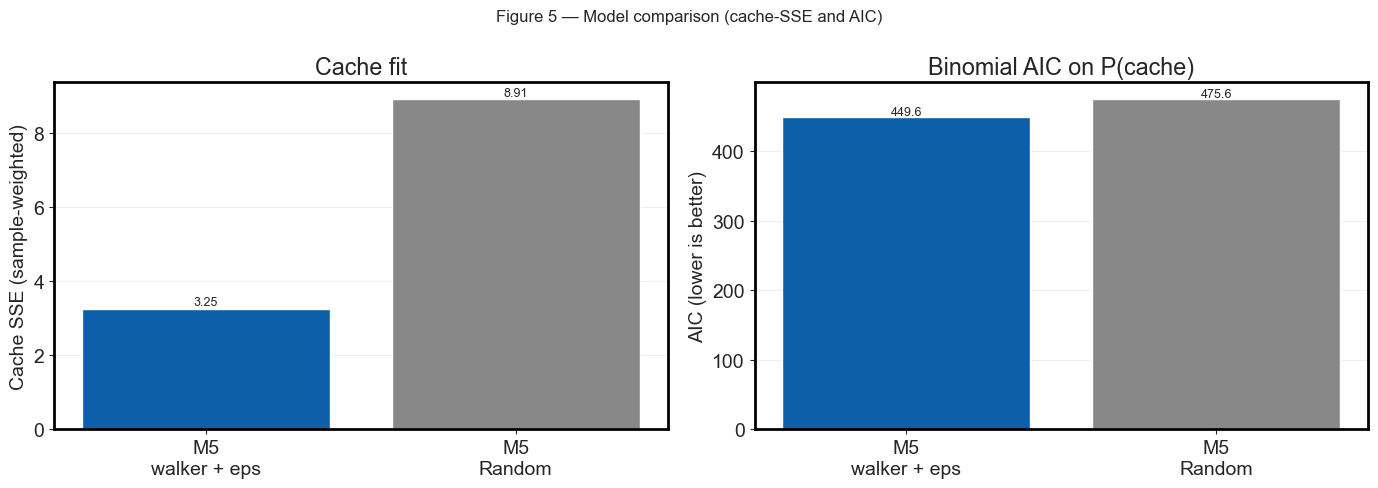

0.0
0.3
0.5
0.7
1.0
1.5
2.0
Generating and saving trajectories for Random Clamps...
0.0
0.3
0.5
0.7
1.0
1.5
2.0


In [364]:
reload(ddm_m5)

#ddm_m5.plot_schematic(fit_m5["params"], include_fp=True)
ddm_m5.plot_walker_calibration(traces, data)
ddm_m5.plot_pcache_comparison({"M5":pred_m5}, metrics, data)
ddm_m5.plot_clamp_distributions(pred_m5["ns"], data, "M5", save_path = None)
ddm_m5.plot_loss_comparison(metrics)
ddm_m5.plot_trajectories(fit_m5["params"], traces, data["sizes"], save_path = None, include_fp=True)
ddm_m5.plot_psychometric_chronometric(data, pred_m5, model_label="DDM v7 (Walker)", control_pred=pred_random, control_label="DDM v7 (Random Clamps)")

# Supplementary figure 2

## Panel G

--- Stat Test: Proportions Z-test (Eat vs Scatter-hoard) ---
Counts: [ 9. 94.], Totals: [ 22 191]
Z-stat: -0.738, p-val: 0.4604
Plot saved to: C:\Users\nacholab-adm\Desktop\figures/rotation_prob_once_in_SH.svg


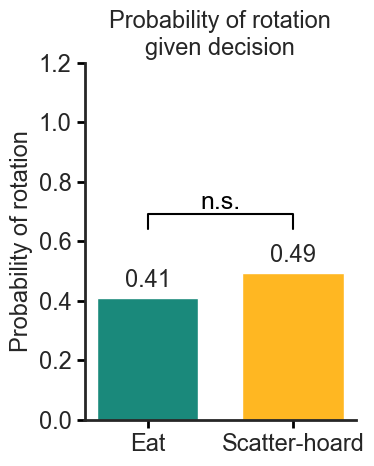

In [236]:
reload(Peanuts)

Peanuts.plot_mean_rotations_by_decision(SH_data, after_first_sh = True, fruit = 'once_in_SH')

# Supplementary figure 3

## Panel C

           comparison  n_control  n_group  power
0     hole vs control          3        3  0.017
1  crushed vs control          3        3  0.020
control 0.8571428571428571
crushed 0.125
hole 0.6666666666666666

Omnibus Chi2 for Scatter hoard: p=8.1576405e-06

Pairwise comparisons for Scatter hoard (Holm-corrected Fisher):
  control vs hole: p=0.04004082761 *
  control vs crushed: p=6.916345786e-06 *
  hole vs crushed: p=0.01599056937 *


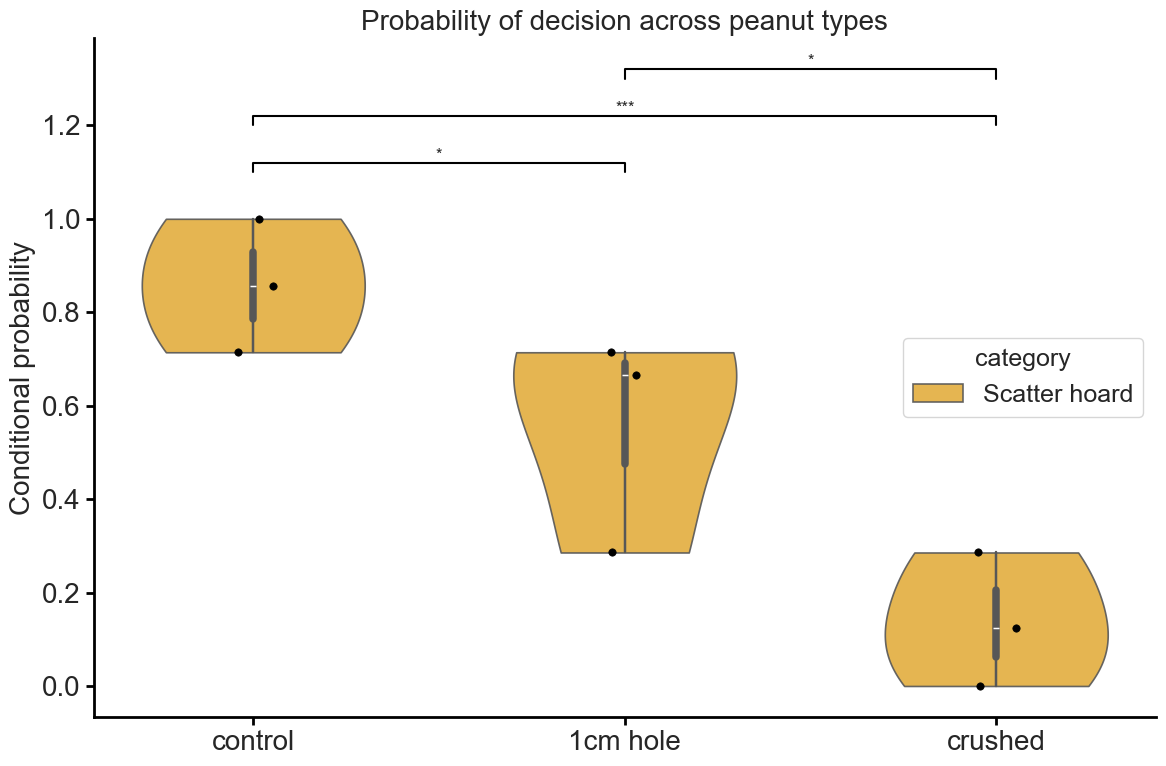

In [239]:
reload(Peanuts)

order = ['control', 'hole', 'crushed']
proba = 'behavior'   # 'behavior', 'given rotate', 'given behavior', 'given teeth-hole'
group_by = 'Session'
connect_scatter = False
min_N_peanuts_per_violin = 2
max_N_missing_violins = 10
show_reg_lines = False
show = True
only_scatter_hoard = True
comparisons = 'all'   # 'all' or 'control'

a = Peanuts.plot_arena(attalea_data, proba, order, group_by, min_N_peanuts_per_violin, max_N_missing_violins = max_N_missing_violins, connect_scatter = connect_scatter, show_reg_lines = show_reg_lines, save_path = None, show = show, only_scatter_hoard = only_scatter_hoard, comparisons = comparisons)

## Panel D

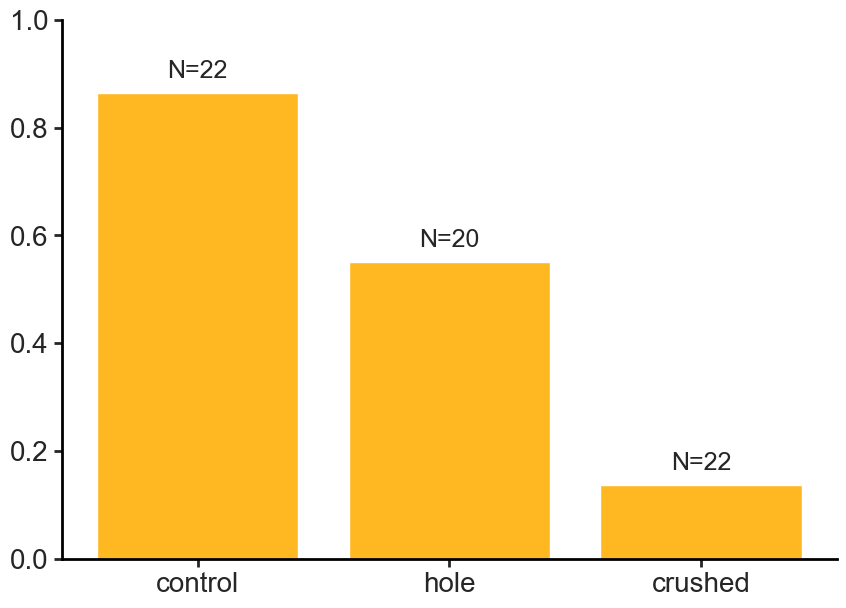


--- Chi-square Omnibus Test (rotation) ---
Groups: ['control', 'hole', 'crushed']
Chi2: 0.537, df: 2, p-value: 0.7644181285
Post-hoc Pairwise Fisher tests (holm corrected):
  control vs hole: p=1 (ns)
  control vs crushed: p=1 (ns)
  hole vs crushed: p=1 (ns)


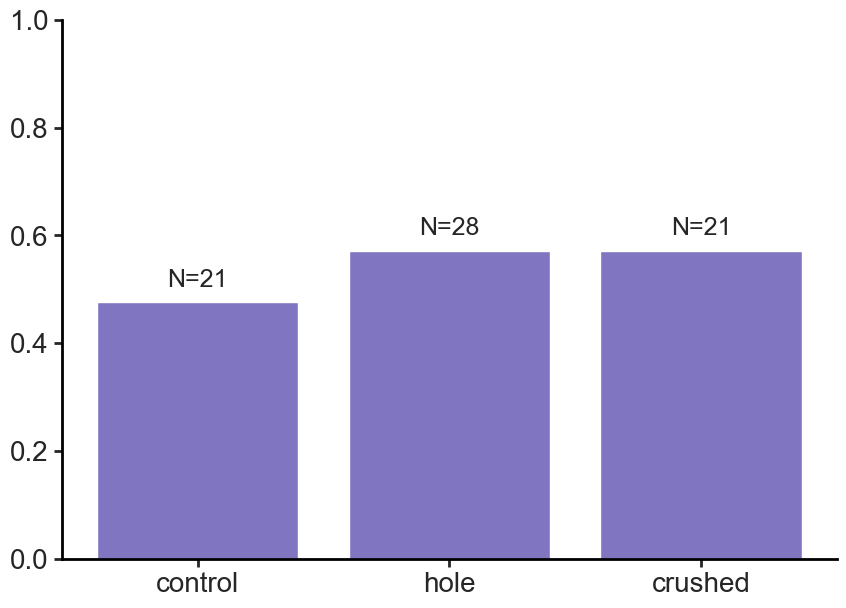

In [242]:
reload(Peanuts)

test = 'chi'

Peanuts.plot_compute_single_prob(attalea_data, 'scatter-hoard', order, '#FFB722')
df = Peanuts.plot_compute_single_prob(attalea_data, 'rotation', order, '#8075C0', save_path = None, test = test)

# Supplementary figure 4

## Panel A

## Panel C

see modeling - target search on ovoid

# Supplementary figure 5

## Panel A

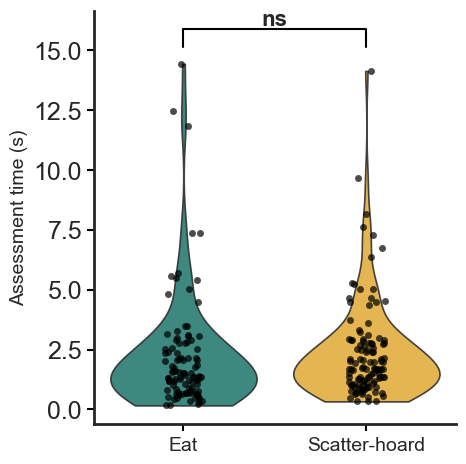

Mann–Whitney U test: U = 5019.500, p = 0.0857 → ns


In [249]:
reload(Peanuts)

assessing_timings_overall = Peanuts.get_assessment_timings_dict(dict_ethograms, correct_chewing = True, overall_or_per_type = 'overall')
Peanuts.plot_overall_assessment_time(assessing_timings_overall, time_or_number = 'time')

## Panel B

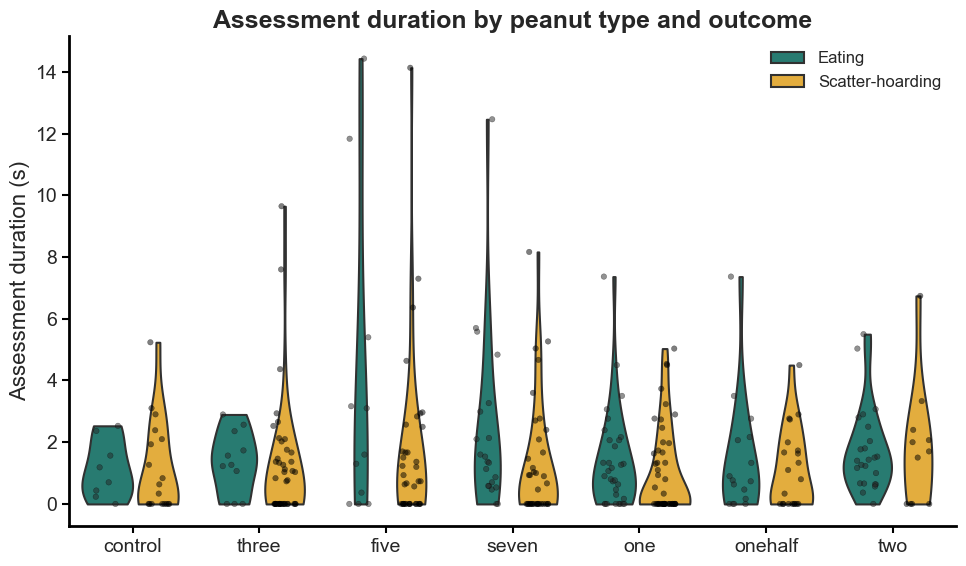

In [251]:
reload(Peanuts)

assessing_timings_dict = Peanuts.get_assessment_timings_dict(dict_ethograms, correct_chewing = True, overall_or_per_type = 'per_type')
Peanuts.plot_assessment_time_per_types(assessing_timings_dict, time_or_number = 'time')

## Panel D


--- Spearman Rank Correlation (Pre-Contact Ramp-Up) ---
Testing steps from min to 0 (N=55 individual movements)
Spearman rho: -0.018
p-value:      0.8952
Result: No significant monotonic trend leading up to the hole.
-------------------------------------------------------



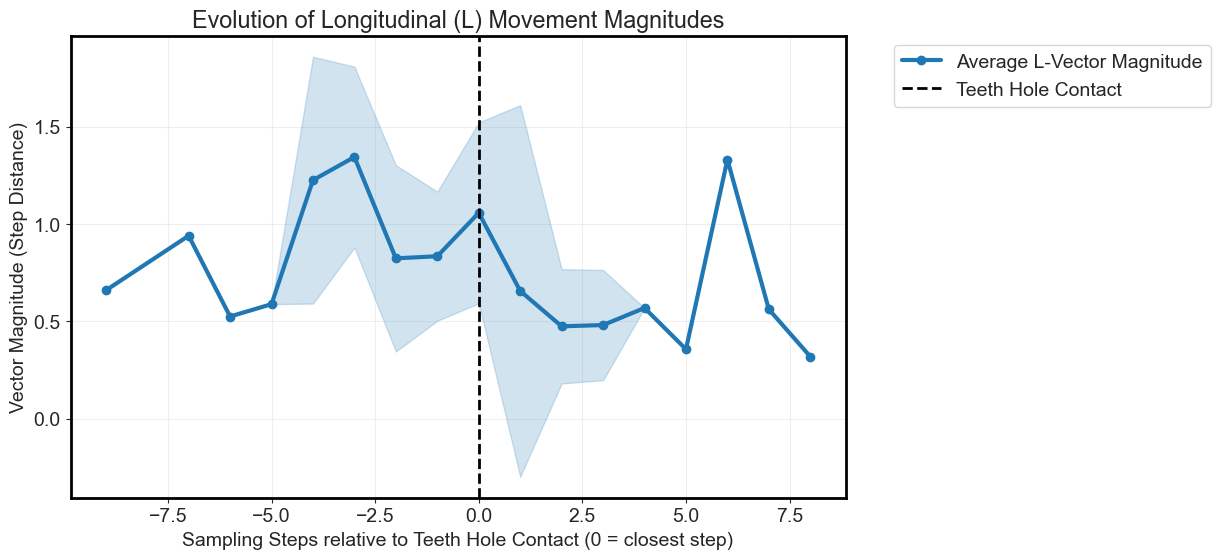

In [254]:
reload(from_antigravity_peanuts)

from_antigravity_peanuts.plot_vector_magnitude_evolution(
    ethogram_path=ethogram_hole_path, 
    sites_directory=sites_holes_path, 
    teeth_mode='bottom', 
    output_file=None,
    time_range=(-15, 15),   # Plots 15 steps before and 15 steps after
    movement_type='L'    # Try 'both', 'L', or 'T'
)

## Panel E

see modeling - DDM